# Integración multi-ómica mRNA–miRNA para priorización de genes candidatos en cáncer de mama

Este notebook implementa una rama de **integración transcriptómica y enriquecimiento funcional**
sobre tres datasets públicos de microarreglos.

El objetivo no es entrenar clasificadores, sino evaluar si existe convergencia estadísticamente
robusta entre:

- genes diferencialmente expresados en GSE42568;
- evidencia génica independiente en E-MTAB-6703;
- genes objetivo de miRNAs diferencialmente expresados en GSE73002-F.

La progresión metodológica comprende cinco experimentos:

1. IoU directo;
2. IoU refinado, cobertura y Fisher;
3. búsqueda sistemática de escenarios;
4. corrección por múltiples pruebas y genes candidatos robustos;
5. enriquecimiento funcional.

> **Alcance de autoría:** este repositorio contiene exclusivamente la rama de integración
> multi-ómica y enriquecimiento desarrollada por el autor del repositorio. La rama predictiva
> de Machine Learning del trabajo colaborativo asociado no se incluye aquí.


## 0. Imports y configuración

In [1]:
import os
import re
import gzip
import html
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import urllib3
from scipy import stats

warnings.filterwarnings("ignore")
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

ID_COL = "Sample"
TARGET_COL = "ENFERMEDAD"

CANCER_LABEL = "CANCER"
NORMAL_LABEL = "NORMAL"

ALPHA_FDR = 0.05
LOG2FC_THRESHOLD = 1.0

# Top-N exploratorio para evitar que un dataset muy estricto deje solo pocos genes.
TOP_N_EXPLORATORIO = 500

print("OUTPUT_DIR:", OUTPUT_DIR)

OUTPUT_DIR: outputs


## 1. Lectura de datasets

Estas tres celdas quedan exactamente como las pediste.

In [2]:
df_egeod42568 = pd.read_csv("data/E-GEOD-42568.csv")
df_egeod42568.head()

,Sample,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Ec-bioB-3_at,AFFX-r2-Ec-bioB-5_at,AFFX-r2-Ec-bioB-M_at,AFFX-r2-Ec-bioC-3_at,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,ENFERMEDAD
0,GSM1045202,5.512046,6.103055,4.667919,3.574706,2.312812,5.866207,6.827303,2.498022,6.156717,...,8.133158,8.485083,8.304021,9.320500,9.054178,13.089629,12.591951,14.189915,14.023695,NORMAL
1,GSM1045203,5.531630,5.620141,3.443221,3.574706,2.312812,4.236720,8.848864,2.954779,5.497599,...,10.388397,10.565904,10.510066,11.261402,11.157106,14.488162,14.156565,15.195245,15.086519,NORMAL
2,GSM1045204,3.709986,5.771661,4.482680,4.045358,2.312812,5.445087,7.511050,2.312812,6.432394,...,8.995057,9.235106,9.301880,10.118996,10.125294,13.899817,13.398621,14.843922,14.767371,NORMAL
3,GSM1045205,4.746807,5.500090,4.066891,3.574706,2.312812,5.769330,7.174464,2.316532,5.780630,...,8.524724,8.719152,8.620499,9.545886,9.491624,13.314455,12.800696,14.570628,14.372705,NORMAL
4,GSM1045206,4.821271,5.349274,4.529324,4.110881,2.312812,5.836472,7.338345,2.488940,7.317542,...,9.274289,8.950310,9.089848,10.109808,10.093021,13.692573,13.246399,14.759816,14.575429,NORMAL


In [3]:
df_egeod73002f = pd.read_csv("data/E-GEOD-73002_FILTRADO.csv")
df_egeod73002f.head()

,Sample,ENFERMEDAD,MIMAT0010195,MIMAT0004481,MIMAT0000062,MIMAT0004482,MIMAT0000063,MIMAT0026472,MIMAT0000064,MIMAT0004484,...,MIMAT0005826,MIMAT0027526,MIMAT0030998,MIMAT0027686,MIMAT0020924,MIMAT0031119,MIMAT0015036,MIMAT0027511,MIMAT0018994,MIMAT0023701
0,GSM1876422,CANCER,3.582417,3.582417,3.582417,3.582417,3.582417,3.582417,3.582417,3.582417,...,5.205512,6.412738,7.171902,7.653780,7.886278,5.235212,7.334312,7.414791,10.164120,7.007426
1,GSM1876423,CANCER,3.383106,2.218250,2.218250,2.639585,2.218250,2.218250,2.218250,2.653611,...,5.839998,6.192700,6.723210,7.571825,7.216226,5.677817,6.925621,7.129495,10.055476,6.601410
2,GSM1876424,CANCER,3.844989,5.621542,3.844989,3.844989,4.320819,3.844989,3.844989,3.844989,...,5.169137,5.900538,6.919944,8.116002,7.385145,NaN,7.074880,7.112213,10.183256,6.629590
3,GSM1876425,CANCER,4.625125,4.625125,4.625125,4.625125,4.625125,4.625125,4.625125,4.625125,...,5.422760,6.298034,7.891967,7.839416,7.754062,4.625125,7.808272,7.443163,10.130435,7.204370
4,GSM1876426,CANCER,5.176016,5.176016,5.176016,5.176016,5.176016,5.176016,5.176016,5.176016,...,5.176016,6.200592,7.339180,7.630673,7.648816,5.176016,7.504732,7.665833,10.333349,6.902733


In [4]:
df_emtab6703 = pd.read_csv("data/E-MTAB-6703.csv")
df_emtab6703.head()

,RFC2,HSPA6,PAX8,GUCA1A,THRA,PTPN21,CCL5,CYP2E1,EPHB3,ESRRA,...,CCDC63,C16orf52,LOC101929475,LOC389641,LOC400499,GALR3,NUS1P3,TMEM231,LOC100505915,ENFERMEDAD
0,7.085461,6.584267,7.584432,5.633560,6.547187,5.202941,7.803543,5.181751,8.836065,6.487106,...,4.162911,3.591147,4.408088,4.898019,5.592057,6.125303,5.449547,6.459786,6.601699,CANCER
1,7.784006,7.171879,7.634071,5.452583,6.596162,6.185807,9.094221,5.059557,8.765331,8.008657,...,4.682255,3.470366,4.833699,4.824913,6.102944,6.160665,4.007753,5.042529,5.204877,CANCER
2,8.698863,9.252172,7.310996,5.782954,6.751361,6.341080,11.059747,4.502676,7.856687,7.585227,...,4.680753,3.094477,4.751743,4.839526,5.964506,5.768440,4.559815,5.172922,5.807361,CANCER
3,7.269989,7.651452,7.279668,5.600526,7.168780,7.827897,6.789616,4.390577,9.446325,7.232152,...,4.221530,4.075928,4.309714,4.736452,5.841523,5.589038,4.056150,8.230735,5.139570,CANCER
4,7.231191,8.790222,7.548172,5.543719,5.949357,5.715767,8.763134,4.821284,7.639209,8.612176,...,4.744455,3.514206,4.918077,5.122439,5.461033,6.330264,5.694180,5.471055,5.555824,CANCER


## 2. Funciones generales

In [5]:
def normalizar_etiquetas(df, target_col=TARGET_COL):
    out = df.copy()
    if target_col not in out.columns:
        raise ValueError(f"No existe la columna objetivo: {target_col}")

    out[target_col] = (
        out[target_col]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace({
            "SANO": "NORMAL",
            "SANA": "NORMAL",
            "CONTROL": "NORMAL",
            "CONTROLES": "NORMAL",
            "NORMALS": "NORMAL",
            "BREAST CANCER": "CANCER",
            "TUMOR": "CANCER",
            "TUMOUR": "CANCER",
            "CÁNCER": "CANCER",
        })
    )
    return out


def obtener_columnas_features(df, id_col=ID_COL, target_col=TARGET_COL):
    excluir = {id_col, target_col}
    return [c for c in df.columns if c not in excluir]


def asegurar_numerico(df, cols):
    return df[cols].apply(pd.to_numeric, errors="coerce")


def normalizar_simbolo_gen(x):
    if pd.isna(x):
        return None

    x = str(x).strip()

    if x == "" or x.lower() in ["nan", "none", "null", "---", "na", "n/a"]:
        return None

    # Algunos archivos traen varios genes separados.
    # Esta función conserva una unidad si se llama fuera de parseo múltiple.
    for sep in ["///", ";", ",", "|"]:
        if sep in x:
            x = x.split(sep)[0].strip()

    x = x.replace('"', "").replace("'", "").strip()

    if x == "" or x.lower() in ["nan", "none", "null", "---", "na", "n/a"]:
        return None

    return x.upper()


def detectar_columna(df, candidatos):
    cols_norm = {
        str(c).lower().strip().replace(" ", "_").replace("-", "_"): c
        for c in df.columns
    }

    for cand in candidatos:
        cand_norm = cand.lower().strip().replace(" ", "_").replace("-", "_")
        if cand_norm in cols_norm:
            return cols_norm[cand_norm]

    for c in df.columns:
        cn = str(c).lower().replace("_", " ").replace("-", " ")
        for cand in candidatos:
            cand_norm = cand.lower().replace("_", " ").replace("-", " ")
            if cand_norm in cn:
                return c

    return None


def ajustar_fdr_bh(p_values):
    p = np.asarray(p_values, dtype=float)
    p = np.where(np.isnan(p), 1.0, p)

    n = len(p)
    order = np.argsort(p)
    ranked_p = p[order]

    adjusted = ranked_p * n / (np.arange(1, n + 1))
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    out = np.empty(n, dtype=float)
    out[order] = adjusted
    return out


def resumen_clases(df, nombre):
    print(f"\n{nombre}")
    print("Forma:", df.shape)
    if TARGET_COL in df.columns:
        print(df[TARGET_COL].value_counts(dropna=False))
    else:
        print(f"No existe columna {TARGET_COL}")

## 3. Normalización de etiquetas y diagnóstico inicial

In [6]:
df_egeod42568 = normalizar_etiquetas(df_egeod42568)
df_egeod73002f = normalizar_etiquetas(df_egeod73002f)
df_emtab6703 = normalizar_etiquetas(df_emtab6703)

resumen_clases(df_egeod42568, "E-GEOD-42568")
resumen_clases(df_egeod73002f, "E-GEOD-73002_FILTRADO")
resumen_clases(df_emtab6703, "E-MTAB-6703")


E-GEOD-42568
Forma: (121, 54677)
ENFERMEDAD
CANCER    104
NORMAL     17
Name: count, dtype: int64

E-GEOD-73002_FILTRADO
Forma: (3966, 2542)
ENFERMEDAD
NORMAL    2686
CANCER    1280
Name: count, dtype: int64

E-MTAB-6703
Forma: (2302, 20546)
ENFERMEDAD
CANCER    2088
NORMAL     214
Name: count, dtype: int64


## 4. Función de análisis diferencial

Calcula `log2FC = media(CANCER) - media(NORMAL)`, prueba t de Welch y FDR.

In [7]:
def analisis_diferencial(
    df,
    feature_cols,
    nombre_dataset,
    feature_name_col="feature_id",
    alpha_fdr=ALPHA_FDR,
    log2fc_threshold=LOG2FC_THRESHOLD,
):
    if TARGET_COL not in df.columns:
        raise ValueError(f"{nombre_dataset}: no existe columna {TARGET_COL}")

    df = normalizar_etiquetas(df)

    mask_cancer = df[TARGET_COL] == CANCER_LABEL
    mask_normal = df[TARGET_COL] == NORMAL_LABEL

    n_cancer = int(mask_cancer.sum())
    n_normal = int(mask_normal.sum())

    if n_cancer == 0 or n_normal == 0:
        raise ValueError(
            f"{nombre_dataset}: se requieren muestras CANCER y NORMAL. "
            f"CANCER={n_cancer}, NORMAL={n_normal}"
        )

    print(f"\nAnalizando {nombre_dataset}")
    print("Muestras CANCER:", n_cancer)
    print("Muestras NORMAL:", n_normal)
    print("Features:", len(feature_cols))

    X = asegurar_numerico(df, feature_cols).astype(np.float32)

    X_cancer = X.loc[mask_cancer].to_numpy(dtype=np.float32)
    X_normal = X.loc[mask_normal].to_numpy(dtype=np.float32)

    mean_cancer = np.nanmean(X_cancer, axis=0)
    mean_normal = np.nanmean(X_normal, axis=0)

    median_cancer = np.nanmedian(X_cancer, axis=0)
    median_normal = np.nanmedian(X_normal, axis=0)

    log2fc = mean_cancer - mean_normal

    test = stats.ttest_ind(
        X_cancer,
        X_normal,
        axis=0,
        equal_var=False,
        nan_policy="omit"
    )

    p_values = np.asarray(test.pvalue, dtype=float)
    p_values = np.where(np.isnan(p_values), 1.0, p_values)
    p_adj = ajustar_fdr_bh(p_values)

    res = pd.DataFrame({
        feature_name_col: feature_cols,
        "n_cancer": n_cancer,
        "n_normal": n_normal,
        "mean_cancer": mean_cancer,
        "mean_normal": mean_normal,
        "median_cancer": median_cancer,
        "median_normal": median_normal,
        "log2FC_cancer_vs_normal": log2fc,
        "p_value": p_values,
        "p_adjusted_fdr": p_adj,
    })

    res["significativo"] = (
        (res["p_adjusted_fdr"] < alpha_fdr) &
        (res["log2FC_cancer_vs_normal"].abs() >= log2fc_threshold)
    )

    res["direccion"] = np.where(
        res["log2FC_cancer_vs_normal"] > 0,
        "UP_EN_CANCER",
        np.where(res["log2FC_cancer_vs_normal"] < 0, "DOWN_EN_CANCER", "SIN_CAMBIO")
    )

    res = res.sort_values(
        ["p_adjusted_fdr", "log2FC_cancer_vs_normal"],
        ascending=[True, False]
    ).reset_index(drop=True)

    print("Features significativas:", int(res["significativo"].sum()))

    return res

## 5. Convertir E-GEOD-42568 de probes Affymetrix a genes

Esta versión evita `GPL570_family.soft.gz` y lee `GPL570.annot.gz` línea por línea para no matar la RAM.

In [8]:
# ============================================================
# MAPEO AFFYMETRIX PROBE → GENE SYMBOL PARA E-GEOD-42568
# Versión robusta para GPL570.annot.gz con metadatos GEO
# ============================================================

def descargar_archivo_stream(url, ruta_salida, timeout=180, verify=True):
    with requests.get(
        url,
        stream=True,
        timeout=timeout,
        headers={"User-Agent": "Mozilla/5.0"},
        verify=verify
    ) as r:
        r.raise_for_status()
        with open(ruta_salida, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

    return ruta_salida


def buscar_columnas_en_header(header_cols, candidatos):
    norm = {
        str(c).lower().strip().replace(" ", "_").replace("-", "_"): i
        for i, c in enumerate(header_cols)
    }

    for cand in candidatos:
        cand_norm = cand.lower().strip().replace(" ", "_").replace("-", "_")
        if cand_norm in norm:
            return norm[cand_norm]

    for i, c in enumerate(header_cols):
        cn = str(c).lower().replace("_", " ").replace("-", " ")
        for cand in candidatos:
            cand_norm = cand.lower().replace("_", " ").replace("-", " ")
            if cand_norm in cn:
                return i

    return None


def parsear_gpl570_annot_gz(annot_local, probes_dataset):
    """
    Lee GPL570.annot.gz línea por línea.

    Busca una tabla que contenga una columna de probe:
        ID / Probe Set ID / probe_id
    y una columna de gen:
        Gene Symbol / Gene symbol / gene_symbol / Symbol

    Extrae solo los probes que existen en df_egeod42568.
    """

    probes_dataset = set([str(p).strip() for p in probes_dataset])

    filas = []
    idx_probe = None
    idx_gene = None
    tabla_iniciada = False
    lineas_vistas = []

    with gzip.open(annot_local, "rt", encoding="utf-8", errors="ignore") as f:
        for line_num, line in enumerate(f, start=1):
            line = line.rstrip("\n")

            if line_num <= 20:
                lineas_vistas.append(line)

            if not line.strip():
                continue

            # Quitar prefijos raros, pero conservar posible encabezado
            line_clean = line.strip()

            # Algunos archivos usan #ID como encabezado
            if line_clean.startswith("#"):
                line_clean = line_clean[1:].strip()

            # Saltar metadatos claros, pero NO si parecen tabla
            if line_clean.startswith("^"):
                continue

            if line_clean.startswith("!") and "\t" not in line_clean:
                continue

            partes = line_clean.split("\t")
            partes_lc = [p.lower().strip() for p in partes]

            # ====================================================
            # Buscar encabezado real de tabla
            # ====================================================
            if not tabla_iniciada:
                tiene_id = any(p in ["id", "probe_id", "probe set id", "probe"] for p in partes_lc)

                tiene_gene = any(
                    ("gene symbol" in p) or
                    (p in ["gene_symbol", "symbol", "gene"])
                    for p in partes_lc
                )

                if tiene_id and tiene_gene:
                    header_cols = partes

                    idx_probe = buscar_columnas_en_header(
                        header_cols,
                        ["ID", "probe_id", "Probe Set ID", "Probe"]
                    )

                    idx_gene = buscar_columnas_en_header(
                        header_cols,
                        ["Gene Symbol", "Gene symbol", "gene_symbol", "Symbol", "Gene"]
                    )

                    if idx_probe is None or idx_gene is None:
                        raise ValueError(
                            "Encontré encabezado candidato, pero no pude detectar columnas. "
                            f"Columnas: {header_cols[:40]}"
                        )

                    tabla_iniciada = True
                    print("Encabezado real encontrado en línea:", line_num)
                    print("Columna probe:", header_cols[idx_probe])
                    print("Columna gene:", header_cols[idx_gene])
                    continue

                # Si todavía no se encuentra encabezado, continuar
                continue

            # ====================================================
            # Procesar filas de la tabla
            # ====================================================
            if len(partes) <= max(idx_probe, idx_gene):
                continue

            probe = partes[idx_probe].strip()

            if probe not in probes_dataset:
                continue

            gene_raw = partes[idx_gene].strip()

            if gene_raw == "" or gene_raw.lower() in ["nan", "null", "---", "na", "n/a"]:
                continue

            # Gene symbol puede venir como "GEN1 /// GEN2"
            genes = [g.strip() for g in gene_raw.split("///") if g.strip()]

            for g in genes:
                g_norm = normalizar_simbolo_gen(g)

                if g_norm is not None and len(str(g_norm)) > 0:
                    filas.append({
                        "probe_id": probe,
                        "gene_symbol": g_norm
                    })

    if not tabla_iniciada:
        print("No se encontró encabezado de tabla.")
        print("Primeras líneas del archivo para diagnóstico:")
        for l in lineas_vistas:
            print(l[:300])

        raise ValueError(
            "No se encontró la tabla real dentro de GPL570.annot.gz. "
            "Puede que el archivo descargado no sea el annot tabular esperado, "
            "o que tenga otro formato de encabezado."
        )

    out = pd.DataFrame(filas).dropna().drop_duplicates()

    if len(out) == 0:
        raise ValueError(
            "Se encontró la tabla, pero ningún probe del dataset tuvo Gene Symbol válido. "
            "Revisa si los probes de E-GEOD-42568 corresponden realmente a GPL570."
        )

    return out


def cargar_mapeo_affymetrix_probe_gene(
    mapping_csv="mapeo_affymetrix_probe_gene.csv",
    annot_local="GPL570.annot.gz",
    output_csv=os.path.join(OUTPUT_DIR, "mapeo_affymetrix_probe_gene_generado.csv"),
):
    # 1. Mapeo local
    if os.path.exists(mapping_csv):
        print(f"Usando mapeo local: {mapping_csv}")
        m = pd.read_csv(mapping_csv)
        m.columns = [str(c).strip() for c in m.columns]

        col_probe = detectar_columna(
            m,
            ["probe_id", "ID", "Probe", "probe", "Probe Set ID"]
        )

        col_gene = detectar_columna(
            m,
            ["gene_symbol", "Gene Symbol", "Gene symbol", "GENE_SYMBOL", "symbol", "Gene"]
        )

        if col_probe is None or col_gene is None:
            raise ValueError(
                f"El mapeo local debe tener columnas probe_id,gene_symbol. "
                f"Columnas disponibles: {m.columns.tolist()}"
            )

        out = m[[col_probe, col_gene]].rename(
            columns={col_probe: "probe_id", col_gene: "gene_symbol"}
        )

        out["probe_id"] = out["probe_id"].astype(str).str.strip()
        out["gene_symbol"] = out["gene_symbol"].map(normalizar_simbolo_gen)

        out = out.dropna().drop_duplicates()
        out = out[out["gene_symbol"].astype(str).str.len() > 0]

        if len(out) == 0:
            print("El mapeo local existe, pero no tiene genes válidos. Se ignorará y se usará GPL570.annot.gz.")
        else:
            out.to_csv(output_csv, index=False)
            print(f"Mapeo probe → gene guardado en: {output_csv}")
            print("Probes mapeados:", out["probe_id"].nunique())
            print("Genes únicos:", out["gene_symbol"].nunique())
            return out

    # 2. Usar/descargar GPL570.annot.gz
    if not os.path.exists(annot_local):
        urls = [
            "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPLnnn/GPL570/annot/GPL570.annot.gz",
            "http://ftp.ncbi.nlm.nih.gov/geo/platforms/GPLnnn/GPL570/annot/GPL570.annot.gz",
        ]

        ultimo_error = None
        descargado = False

        for url in urls:
            try:
                print("Intentando descargar anotación GPL570 desde:", url)

                try:
                    descargar_archivo_stream(url, annot_local, verify=True)
                except Exception:
                    print("Falló con verificación SSL, intentando verify=False...")
                    descargar_archivo_stream(url, annot_local, verify=False)

                descargado = True
                print(f"Archivo descargado como: {annot_local}")
                break

            except Exception as e:
                ultimo_error = e
                print("Falló:", repr(e))

        if not descargado:
            probe_cols = obtener_columnas_features(df_egeod42568)
            plantilla = pd.DataFrame({
                "probe_id": probe_cols,
                "gene_symbol": ""
            })
            plantilla.to_csv(mapping_csv, index=False)

            raise RuntimeError(
                "No se pudo descargar GPL570.annot.gz automáticamente. "
                f"Se creó una plantilla: {mapping_csv}. "
                "Puedes completarla manualmente o descargar GPL570.annot.gz y ponerlo junto al notebook. "
                f"Último error: {ultimo_error}"
            )

    print(f"Leyendo anotación local línea por línea: {annot_local}")

    probe_cols = obtener_columnas_features(df_egeod42568)

    try:
        out = parsear_gpl570_annot_gz(
            annot_local=annot_local,
            probes_dataset=probe_cols
        )
    except Exception as e:
        raise RuntimeError(
            "No se pudo parsear GPL570.annot.gz. "
            "Si interrumpiste una descarga anterior, borra GPL570.annot.gz y vuelve a ejecutar. "
            f"Error: {repr(e)}"
        )

    out["probe_id"] = out["probe_id"].astype(str).str.strip()
    out["gene_symbol"] = out["gene_symbol"].map(normalizar_simbolo_gen)
    out = out.dropna().drop_duplicates()
    out = out[out["gene_symbol"].astype(str).str.len() > 0]

    out.to_csv(output_csv, index=False)

    print(f"Mapeo probe → gene guardado en: {output_csv}")
    print("Probes mapeados:", out["probe_id"].nunique())
    print("Genes únicos:", out["gene_symbol"].nunique())

    return out


def colapsar_probes_a_genes(df, mapeo, nombre_dataset="E-GEOD-42568"):
    feature_cols = obtener_columnas_features(df)

    m = mapeo[mapeo["probe_id"].isin(feature_cols)].copy()

    if len(m) == 0:
        raise ValueError(f"{nombre_dataset}: ningún probe del dataset aparece en el mapeo.")

    probes_validos = m["probe_id"].unique().tolist()

    print(f"{nombre_dataset}: preparando matriz de expresión...")
    print("Probes originales:", len(feature_cols))
    print("Probes mapeados en dataset:", len(probes_validos))

    X_original = df[probes_validos].apply(pd.to_numeric, errors="coerce").astype("float32")

    bloques = []

    for gene, sub in m.groupby("gene_symbol"):
        probes_gene = [p for p in sub["probe_id"].unique() if p in X_original.columns]

        if len(probes_gene) == 0:
            continue

        bloques.append(pd.Series(
            X_original[probes_gene].mean(axis=1),
            name=gene
        ))

    X_gene = pd.concat(bloques, axis=1)
    X_gene = X_gene.astype("float32")

    out = pd.DataFrame(index=df.index)

    if ID_COL in df.columns:
        out[ID_COL] = df[ID_COL].values

    out[TARGET_COL] = df[TARGET_COL].values

    out = pd.concat([out, X_gene], axis=1)

    print(f"{nombre_dataset} convertido de probes a genes.")
    print("Genes resultantes:", X_gene.shape[1])

    return out


mapeo_affy = cargar_mapeo_affymetrix_probe_gene()

df_egeod42568_genes = colapsar_probes_a_genes(
    df_egeod42568,
    mapeo_affy,
    nombre_dataset="E-GEOD-42568"
)

df_egeod42568_genes.to_csv(
    os.path.join(OUTPUT_DIR, "E-GEOD-42568_genes_colapsado.csv"),
    index=False
)

df_egeod42568_genes.head()

Leyendo anotación local línea por línea: GPL570.annot.gz
Encabezado real encontrado en línea: 28
Columna probe: ID
Columna gene: Gene symbol
Mapeo probe → gene guardado en: outputs\mapeo_affymetrix_probe_gene_generado.csv
Probes mapeados: 45118
Genes únicos: 22834
E-GEOD-42568: preparando matriz de expresión...
Probes originales: 54675
Probes mapeados en dataset: 45118
E-GEOD-42568 convertido de probes a genes.
Genes resultantes: 22834


,Sample,ENFERMEDAD,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A4GALT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,GSM1045202,NORMAL,3.890310,4.170918,2.320107,6.262234,4.363829,2.322338,2.322535,2.357740,...,5.056367,6.097713,3.508466,3.056949,4.309235,2.321520,7.013400,6.119998,3.871866,6.539139
1,GSM1045203,NORMAL,4.037233,4.219688,2.623246,6.136545,4.029783,2.322338,2.320375,2.499366,...,3.966756,3.634218,3.534065,2.726898,4.367912,2.527626,7.052153,3.947222,4.001139,5.423755
2,GSM1045204,NORMAL,3.937074,4.161794,2.320107,6.436507,4.393917,2.322338,2.322477,2.357740,...,4.476497,5.442119,3.473008,2.839364,4.257569,2.312812,7.238954,5.234638,4.118503,6.015151
3,GSM1045205,NORMAL,3.987475,4.055844,2.329883,6.141951,4.177580,2.322338,2.312812,2.357740,...,3.919597,5.008089,3.592627,3.187022,4.407126,2.690099,7.534361,4.762992,4.088483,5.262919
4,GSM1045206,NORMAL,3.611297,4.045971,2.320107,6.414890,3.754758,2.322338,2.356748,2.386345,...,3.936821,5.240382,3.402002,2.774846,3.541454,2.312812,6.686151,6.028156,4.005062,5.818684


## 6. Análisis diferencial de E-GEOD-42568 ya convertido a genes

In [9]:
genes_egeod42568 = obtener_columnas_features(df_egeod42568_genes)

res_42568 = analisis_diferencial(
    df=df_egeod42568_genes,
    feature_cols=genes_egeod42568,
    nombre_dataset="E-GEOD-42568 genes",
    feature_name_col="gene_symbol"
)

res_42568.to_csv(os.path.join(OUTPUT_DIR, "dge_E-GEOD-42568_genes.csv"), index=False)

sig_42568 = res_42568[res_42568["significativo"]].copy()
sig_42568.to_csv(os.path.join(OUTPUT_DIR, "genes_significativos_E-GEOD-42568.csv"), index=False)

sig_42568.head()


Analizando E-GEOD-42568 genes
Muestras CANCER: 104
Muestras NORMAL: 17
Features: 22834
Features significativas: 2501


,gene_symbol,n_cancer,n_normal,mean_cancer,mean_normal,median_cancer,median_normal,log2FC_cancer_vs_normal,p_value,p_adjusted_fdr,significativo,direccion
0,COL10A1,104,17,7.067001,3.489504,7.087907,3.375924,3.577497,2.984762e-35,6.815406e-31,True,UP_EN_CANCER
1,NECTIN4,104,17,5.311889,3.446957,5.310137,3.515076,1.864932,3.469586e-30,3.961226e-26,True,UP_EN_CANCER
2,FBXL16,104,17,4.699279,3.168153,4.665476,3.046978,1.531126,6.987895e-26,5.318720e-22,True,UP_EN_CANCER
3,RSPH1,104,17,4.743672,2.881537,4.784575,2.929470,1.862135,6.887001e-24,3.784220e-20,True,UP_EN_CANCER
4,FGFR3,104,17,4.577049,3.176775,4.601620,3.138110,1.400274,8.286372e-24,3.784220e-20,True,UP_EN_CANCER


## 7. Usar E-MTAB-6703 como genes directamente

Se normalizan nombres de columnas y se colapsan duplicados si existieran.

In [10]:
def preparar_emtab_genes_directos(df, nombre_dataset="E-MTAB-6703"):
    feature_cols = obtener_columnas_features(df)

    X = df[feature_cols].apply(pd.to_numeric, errors="coerce").astype("float32")

    genes_norm = [normalizar_simbolo_gen(c) for c in feature_cols]

    keep = [g is not None and len(str(g)) > 0 for g in genes_norm]
    X = X.loc[:, keep]
    genes_norm = [g for g in genes_norm if g is not None and len(str(g)) > 0]

    X.columns = genes_norm

    X_gene = X.T.groupby(level=0).mean().T
    X_gene = X_gene.astype("float32")

    out = pd.DataFrame(index=df.index)

    if ID_COL in df.columns:
        out[ID_COL] = df[ID_COL].values

    out[TARGET_COL] = df[TARGET_COL].values
    out = pd.concat([out, X_gene], axis=1)

    print(f"{nombre_dataset} preparado como genes directos.")
    print("Genes resultantes:", X_gene.shape[1])

    return out


df_emtab6703_genes = preparar_emtab_genes_directos(df_emtab6703)

df_emtab6703_genes.to_csv(
    os.path.join(OUTPUT_DIR, "E-MTAB-6703_genes_preparado.csv"),
    index=False
)

df_emtab6703_genes.head()

E-MTAB-6703 preparado como genes directos.
Genes resultantes: 20545


,ENFERMEDAD,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A4GALT,A4GNT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,CANCER,5.402935,4.875490,4.713777,4.567645,5.190206,4.712579,4.319430,5.438546,4.060443,...,8.348498,9.076437,5.803504,6.495828,7.568211,6.104373,8.802613,7.757662,6.912352,7.834272
1,CANCER,7.014526,5.033004,4.712893,4.384123,5.115982,4.462300,4.440476,5.682232,4.414146,...,8.543466,9.564399,5.717076,6.088880,7.721607,6.164204,9.279235,7.840055,6.845588,8.658313
2,CANCER,5.725154,5.274541,4.405781,4.183829,4.602940,4.052758,4.461535,6.475104,4.356188,...,8.168561,9.588351,5.802858,6.320940,7.288339,5.948324,9.486465,7.819482,6.820251,8.721849
3,CANCER,6.468476,5.074392,4.511763,4.477560,6.293594,5.691168,4.050725,6.354238,4.084108,...,8.442945,8.181938,6.096431,7.296721,7.377312,4.977227,8.824168,8.407890,7.967115,8.592635
4,CANCER,6.095003,4.822867,5.254384,4.743853,4.962022,4.521090,4.940572,6.013334,4.119816,...,7.731014,8.909960,5.959843,7.293142,6.862437,6.256863,8.732921,7.848605,7.529676,8.578694


## 8. Análisis diferencial de E-MTAB-6703

In [11]:
genes_emtab = obtener_columnas_features(df_emtab6703_genes)

res_emtab = analisis_diferencial(
    df=df_emtab6703_genes,
    feature_cols=genes_emtab,
    nombre_dataset="E-MTAB-6703 genes",
    feature_name_col="gene_symbol"
)

res_emtab.to_csv(os.path.join(OUTPUT_DIR, "dge_E-MTAB-6703_genes.csv"), index=False)

sig_emtab = res_emtab[res_emtab["significativo"]].copy()
sig_emtab.to_csv(os.path.join(OUTPUT_DIR, "genes_significativos_E-MTAB-6703.csv"), index=False)

sig_emtab.head()


Analizando E-MTAB-6703 genes
Muestras CANCER: 2088
Muestras NORMAL: 214
Features: 20545
Features significativas: 19


,gene_symbol,n_cancer,n_normal,mean_cancer,mean_normal,median_cancer,median_normal,log2FC_cancer_vs_normal,p_value,p_adjusted_fdr,significativo,direccion
0,COL11A1,2088,214,9.184640,7.665786,9.533392,7.835968,1.518854,0.000000e+00,0.000000e+00,True,UP_EN_CANCER
1,COL10A1,2088,214,9.057873,7.884734,9.202108,8.074833,1.173139,0.000000e+00,0.000000e+00,True,UP_EN_CANCER
12,TOP2A,2088,214,8.018930,7.010448,8.031811,7.033109,1.008482,1.467159e-42,2.318676e-39,True,UP_EN_CANCER
25,SFRP1,2088,214,8.045525,9.353654,7.948305,9.439721,-1.308129,9.803739e-39,7.746839e-36,True,DOWN_EN_CANCER
35,C2ORF40,2088,214,6.209852,7.459897,5.789559,7.454744,-1.250045,1.269731e-37,7.246285e-35,True,DOWN_EN_CANCER


## 9. Análisis diferencial de miRNAs en E-GEOD-73002_FILTRADO

In [12]:
mirna_cols = obtener_columnas_features(df_egeod73002f)

res_mirna = analisis_diferencial(
    df=df_egeod73002f,
    feature_cols=mirna_cols,
    nombre_dataset="E-GEOD-73002_FILTRADO miRNAs",
    feature_name_col="mimat_id"
)

res_mirna.to_csv(os.path.join(OUTPUT_DIR, "dge_E-GEOD-73002_miRNAs.csv"), index=False)

sig_mirna = res_mirna[res_mirna["significativo"]].copy()
sig_mirna.to_csv(os.path.join(OUTPUT_DIR, "miRNAs_significativos_E-GEOD-73002.csv"), index=False)

sig_mirna.head()


Analizando E-GEOD-73002_FILTRADO miRNAs
Muestras CANCER: 1280
Muestras NORMAL: 2686
Features: 2540
Features significativas: 2039


,mimat_id,n_cancer,n_normal,mean_cancer,mean_normal,median_cancer,median_normal,log2FC_cancer_vs_normal,p_value,p_adjusted_fdr,significativo,direccion
0,MIMAT0005898,1280,2686,8.125372,3.084141,8.400352,2.900729,5.041231,0.0,0.0,True,UP_EN_CANCER
1,MIMAT0024615,1280,2686,11.347822,6.505715,11.631935,6.044658,4.842107,0.0,0.0,True,UP_EN_CANCER
2,MIMAT0001631,1280,2686,6.854990,2.929113,6.783654,2.509157,3.925877,0.0,0.0,True,UP_EN_CANCER
3,MIMAT0000440,1280,2686,6.196244,2.367625,6.304320,2.314768,3.828619,0.0,0.0,True,UP_EN_CANCER
4,MIMAT0005951,1280,2686,8.910324,5.129470,9.149699,5.135343,3.780854,0.0,0.0,True,UP_EN_CANCER


## 10. Mapeo MIMAT → nombre de miRNA

Esta versión corrige el caso donde miRBase devuelve HTML con `&gt;` y `<br>`.

In [13]:
# ============================================================
# MAPEO MIMAT → miRNA NAME
# ============================================================

def limpiar_html_mirbase_a_fasta(texto):
    texto = html.unescape(texto)
    texto = re.sub(r"<br\s*/?>", "\n", texto, flags=re.IGNORECASE)
    texto = re.sub(r"<[^>]+>", "", texto)
    return texto.strip()


def parsear_mirbase_mature_fa(texto):
    filas = []

    for linea in texto.splitlines():
        linea = linea.strip()

        if not linea.startswith(">"):
            continue

        partes = linea[1:].split()

        if len(partes) < 2:
            continue

        mirna_name = partes[0].strip()
        mimat_id = partes[1].strip()

        if mirna_name.startswith("hsa-") and mimat_id.startswith("MIMAT"):
            filas.append({
                "mimat_id": mimat_id,
                "mirna_name": mirna_name
            })

    return pd.DataFrame(filas).drop_duplicates()


def leer_texto_fasta_desde_archivo(ruta):
    if ruta.endswith(".gz"):
        with gzip.open(ruta, "rt", encoding="utf-8", errors="ignore") as f:
            return f.read()
    else:
        with open(ruta, "r", encoding="utf-8", errors="ignore") as f:
            return f.read()


def descargar_texto_fasta(url):
    r = requests.get(
        url,
        timeout=90,
        headers={
            "User-Agent": "Mozilla/5.0",
            "Accept": "text/plain,text/html,*/*"
        }
    )
    r.raise_for_status()

    contenido = r.content

    if url.endswith(".gz"):
        texto = gzip.decompress(contenido).decode("utf-8", errors="ignore")
    else:
        texto = contenido.decode("utf-8", errors="ignore")

    if "<br" in texto.lower() or "&gt;" in texto.lower() or "<p" in texto.lower():
        texto = limpiar_html_mirbase_a_fasta(texto)

    if not texto.lstrip().startswith(">"):
        print("La descarga no parece FASTA después de limpiar. Primeras líneas:")
        print("\n".join(texto.splitlines()[:5]))
        raise ValueError("La respuesta descargada no parece FASTA válido.")

    return texto


def descargar_mirbase_mature_mapping(
    mapping_csv="mapeo_mimat_mirna.csv",
    mature_local="mature.fa",
    mature_gz_local="mature.fa.gz",
    output_csv=os.path.join(OUTPUT_DIR, "mapeo_mimat_mirna_generado.csv"),
):
    if os.path.exists(mapping_csv):
        print(f"Usando mapeo local: {mapping_csv}")
        m = pd.read_csv(mapping_csv)
        m.columns = [str(c).strip() for c in m.columns]

        if not {"mimat_id", "mirna_name"}.issubset(set(m.columns)):
            raise ValueError("El archivo debe tener columnas: mimat_id, mirna_name")

        m = m[["mimat_id", "mirna_name"]].dropna().drop_duplicates()
        print("Mapeo cargado:", len(m))
        return m

    if os.path.exists(mature_local):
        print(f"Usando archivo local: {mature_local}")
        texto = leer_texto_fasta_desde_archivo(mature_local)
        if "<br" in texto.lower() or "&gt;" in texto.lower() or "<p" in texto.lower():
            texto = limpiar_html_mirbase_a_fasta(texto)
        m = parsear_mirbase_mature_fa(texto)

        if len(m) == 0:
            raise ValueError("El archivo mature.fa local no pudo parsearse.")

        m.to_csv(output_csv, index=False)
        print("miRNAs humanos mapeados:", len(m))
        return m

    if os.path.exists(mature_gz_local):
        print(f"Usando archivo local: {mature_gz_local}")
        texto = leer_texto_fasta_desde_archivo(mature_gz_local)
        if "<br" in texto.lower() or "&gt;" in texto.lower() or "<p" in texto.lower():
            texto = limpiar_html_mirbase_a_fasta(texto)
        m = parsear_mirbase_mature_fa(texto)

        if len(m) == 0:
            raise ValueError("El archivo mature.fa.gz local no pudo parsearse.")

        m.to_csv(output_csv, index=False)
        print("miRNAs humanos mapeados:", len(m))
        return m

    urls = [
        "https://mirbase.org/download/CURRENT/mature.fa",
        "https://www.mirbase.org/download/CURRENT/mature.fa",
        "https://mirbase.org/download/CURRENT/mature_high_conf.fa",
        "https://www.mirbase.org/download/CURRENT/mature_high_conf.fa",
    ]

    ultimo_error = None

    for url in urls:
        try:
            print("Intentando descargar miRBase desde:", url)
            texto = descargar_texto_fasta(url)
            m = parsear_mirbase_mature_fa(texto)

            if len(m) == 0:
                raise ValueError("No se pudieron parsear miRNAs humanos desde mature.fa")

            m.to_csv(output_csv, index=False)

            print(f"Mapeo MIMAT → miRNA guardado en: {output_csv}")
            print("miRNAs humanos mapeados:", len(m))

            return m

        except Exception as e:
            ultimo_error = e
            print("Falló:", repr(e))

    raise RuntimeError(
        "No se pudo descargar/parsear miRBase automáticamente. "
        "Descarga mature.fa manualmente o crea mapeo_mimat_mirna.csv. "
        f"Último error: {ultimo_error}"
    )


def crear_mirna_key(x):
    if pd.isna(x):
        return None
    x = str(x).strip().lower()
    x = x.replace(" ", "")
    return x


mapeo_mimat = descargar_mirbase_mature_mapping()

res_mirna_named = res_mirna.merge(mapeo_mimat, on="mimat_id", how="left")
sig_mirna_named = sig_mirna.merge(mapeo_mimat, on="mimat_id", how="left")

res_mirna_named["mirna_key"] = res_mirna_named["mirna_name"].map(crear_mirna_key)
sig_mirna_named["mirna_key"] = sig_mirna_named["mirna_name"].map(crear_mirna_key)

res_mirna_named.to_csv(
    os.path.join(OUTPUT_DIR, "dge_E-GEOD-73002_miRNAs_con_nombre.csv"),
    index=False
)

sig_mirna_named.to_csv(
    os.path.join(OUTPUT_DIR, "miRNAs_significativos_con_nombre.csv"),
    index=False
)

print(
    "miRNAs significativos con nombre asignado:",
    sig_mirna_named["mirna_name"].notna().sum(),
    "de",
    len(sig_mirna_named)
)

sig_mirna_named.head(10)

Intentando descargar miRBase desde: https://mirbase.org/download/CURRENT/mature.fa
Mapeo MIMAT → miRNA guardado en: outputs\mapeo_mimat_mirna_generado.csv
miRNAs humanos mapeados: 2789
miRNAs significativos con nombre asignado: 1976 de 2039


,mimat_id,n_cancer,n_normal,mean_cancer,mean_normal,median_cancer,median_normal,log2FC_cancer_vs_normal,p_value,p_adjusted_fdr,significativo,direccion,mirna_name,mirna_key
0,MIMAT0005898,1280,2686,8.125372,3.084141,8.400352,2.900729,5.041231,0.0,0.0,True,UP_EN_CANCER,hsa-miR-1246-5p,hsa-mir-1246-5p
1,MIMAT0024615,1280,2686,11.347822,6.505715,11.631935,6.044658,4.842107,0.0,0.0,True,UP_EN_CANCER,hsa-miR-6131-3p,hsa-mir-6131-3p
2,MIMAT0001631,1280,2686,6.854990,2.929113,6.783654,2.509157,3.925877,0.0,0.0,True,UP_EN_CANCER,hsa-miR-451a-5p,hsa-mir-451a-5p
3,MIMAT0000440,1280,2686,6.196244,2.367625,6.304320,2.314768,3.828619,0.0,0.0,True,UP_EN_CANCER,hsa-miR-191-5p,hsa-mir-191-5p
4,MIMAT0005951,1280,2686,8.910324,5.129470,9.149699,5.135343,3.780854,0.0,0.0,True,UP_EN_CANCER,hsa-miR-1307-3p,hsa-mir-1307-3p
5,MIMAT0000418,1280,2686,6.600714,2.952687,6.481870,2.903168,3.648028,0.0,0.0,True,UP_EN_CANCER,hsa-miR-23b-3p,hsa-mir-23b-3p
6,MIMAT0019218,1280,2686,7.595863,3.971799,7.756823,3.948458,3.624064,0.0,0.0,True,UP_EN_CANCER,hsa-miR-3194-3p,hsa-mir-3194-3p
7,MIMAT0000078,1280,2686,6.475576,2.921556,6.364618,2.835418,3.554020,0.0,0.0,True,UP_EN_CANCER,hsa-miR-23a-3p,hsa-mir-23a-3p
8,MIMAT0019947,1280,2686,8.566344,5.136585,8.824131,5.116148,3.429759,0.0,0.0,True,UP_EN_CANCER,hsa-miR-4783-3p,hsa-mir-4783-3p
9,MIMAT0019925,1280,2686,5.877044,2.457011,5.959802,2.392451,3.420034,0.0,0.0,True,UP_EN_CANCER,hsa-miR-4771-3p,hsa-mir-4771-3p


## 11. Mapeo miRNA → genes objetivo

Prioridad: CSV local `mapeo_mirna_target_genes.csv`; si no existe, fallback de Harmonizome/miRTarBase.

In [14]:
# ============================================================
# MAPEO miRNA → GENES OBJETIVO
# Versión robusta v6:
# - Arregla Harmonizome: usa source=GENE y target=miRNA
# - Evita confundir IDs MIRTxxxxx como si fueran miRNAs
# - Acepta hsa-miR-1246, miR-1246, MIR1246, MIR-1246
# - NO elimina todo por no empezar con hsa-
# ============================================================

def normalizar_mirna_name(x):
    if pd.isna(x):
        return None

    x = str(x).strip()

    if x == "" or x.lower() in ["nan", "none", "null", "na", "n/a"]:
        return None

    return x


def normalizar_mirna_core_key(x):
    """
    Convierte nombres distintos del mismo miRNA a una llave comparable.

    Ejemplos:
        hsa-miR-1246      -> mir1246
        hsa-mir-1246      -> mir1246
        miR-1246          -> mir1246
        MIR1246           -> mir1246
        MIR-1246          -> mir1246
        hsa-miR-1307-3p   -> mir1307-3p
        MIR1307-3P        -> mir1307-3p
        hsa-let-7a-5p     -> let7a-5p

    Importante:
        MIRT004758        -> None
    porque eso es un ID de miRTarBase, no un miRNA.
    """

    if pd.isna(x):
        return None

    x = str(x).strip().lower()

    if x == "" or x in ["nan", "none", "null", "na", "n/a"]:
        return None

    # Evitar IDs de miRTarBase tipo MIRT004758
    if re.match(r"^mirt\d+$", x):
        return None

    # Normalizar nombres comunes
    x = x.replace("microrna", "mir")
    x = x.replace("mirna", "mir")

    # Quitar especie si existe
    if x.startswith("hsa-"):
        x = x[4:]

    # Limpiar espacios y separadores
    x = x.replace(" ", "")
    x = x.replace("_", "-")

    # Evitar de nuevo IDs tipo mirt-004758 / mirt004758
    x_tmp = x.replace("-", "")
    if re.match(r"^mirt\d+$", x_tmp):
        return None

    # Casos tipo mir-1246 → mir1246
    if x.startswith("mir-"):
        x = "mir" + x[4:]

    # Casos tipo let-7a-5p → let7a-5p
    if x.startswith("let-"):
        x = "let" + x[4:]

    # Quitar caracteres no útiles, conservando guiones internos
    x = re.sub(r"[^a-z0-9\-]", "", x)

    if x == "":
        return None

    # Debe parecer miRNA real
    if not (x.startswith("mir") or x.startswith("let")):
        return None

    # Excluir otra vez mirt ya normalizado
    if re.match(r"^mirt\d+$", x.replace("-", "")):
        return None

    return x


def score_columna_mirna(s):
    vals = s.dropna().astype(str).head(5000).str.lower()

    if len(vals) == 0:
        return 0

    keys = vals.map(normalizar_mirna_core_key)
    return keys.notna().mean()


def score_columna_gen(s):
    vals = s.dropna().astype(str).head(5000)

    if len(vals) == 0:
        return 0

    norm = vals.map(normalizar_simbolo_gen)

    ok = (
        norm.notna()
        & norm.astype(str).str.match(r"^[A-Z0-9\.\-]+$", na=False)
        & (norm.astype(str).str.len() <= 30)
    )

    # Evitar que miRNAs sean tomados como genes
    no_mirna = vals.map(normalizar_mirna_core_key).isna()

    return (ok & no_mirna).mean()


def cargar_mirna_target_genes(
    target_csv="mapeo_mirna_target_genes.csv",
    output_csv=os.path.join(OUTPUT_DIR, "mapeo_mirna_target_genes_generado.csv"),
):
    """
    Carga pares miRNA → gen objetivo.

    Prioridad:
    1. Si existe mapeo_mirna_target_genes.csv local, lo usa.
    2. Si no existe, usa Harmonizome / MiRTarBase microRNA Targets.

    Salida:
        mirna_name
        mirna_core_key
        target_gene
    """

    # ============================================================
    # 1. Archivo local
    # ============================================================
    if os.path.exists(target_csv):
        print(f"Usando mapeo local: {target_csv}")

        df = pd.read_csv(target_csv)
        df.columns = [str(c).strip() for c in df.columns]

        print("Forma del archivo local:", df.shape)
        print("Columnas del archivo local:", df.columns.tolist())

        col_mirna = detectar_columna(
            df,
            [
                "mirna_name", "miRNA", "miRNA Name", "miRNA_name",
                "microRNA", "microRNA Name", "attribute", "Attribute"
            ]
        )

        col_target = detectar_columna(
            df,
            [
                "target_gene", "Target Gene", "Target Gene Symbol",
                "target", "gene", "Gene", "symbol", "Symbol"
            ]
        )

        if col_mirna is None or col_target is None:
            raise ValueError(
                "El CSV local debe tener columnas equivalentes a mirna_name y target_gene. "
                f"Columnas disponibles: {df.columns.tolist()}"
            )

        out = df[[col_mirna, col_target]].rename(
            columns={
                col_mirna: "mirna_name",
                col_target: "target_gene"
            }
        )

    # ============================================================
    # 2. Fallback online: Harmonizome / MiRTarBase
    # ============================================================
    else:
        url = "https://maayanlab.cloud/static/hdfs/harmonizome/data/mirtarbase/gene_attribute_edges.txt.gz"

        print("No se encontró mapeo local.")
        print("Intentando usar Harmonizome / MiRTarBase microRNA Targets:")
        print(url)

        try:
            df = pd.read_csv(url, sep="\t", compression="gzip")
        except Exception as e:
            raise RuntimeError(
                "No se pudo descargar el fallback desde Harmonizome. "
                "Crea manualmente mapeo_mirna_target_genes.csv con columnas mirna_name,target_gene. "
                f"Error original: {repr(e)}"
            )

        print("Forma descargada:", df.shape)
        print("Columnas descargadas:", df.columns.tolist())
        print(df.head().to_string())

        # Harmonizome gene_attribute_edges tiene esta estructura:
        # source = gene symbol
        # target = miRNA
        if {"source", "target"}.issubset(set(df.columns)):
            print("Formato Harmonizome detectado: usando source=target_gene y target=mirna_name")
            out = df[["target", "source"]].rename(
                columns={
                    "target": "mirna_name",
                    "source": "target_gene"
                }
            )

            # Eliminar la primera fila descriptiva si existe:
            # source=GeneSym, target=miRNA
            out = out[
                ~(
                    out["target_gene"].astype(str).str.lower().eq("genesym")
                    | out["mirna_name"].astype(str).str.lower().eq("mirna")
                )
            ].copy()

        else:
            # Fallback genérico por si cambia el formato
            print("No se detectó formato source/target. Infiriendo por contenido...")

            scores_mirna = {c: score_columna_mirna(df[c]) for c in df.columns}
            scores_gene = {c: score_columna_gen(df[c]) for c in df.columns}

            print("Score miRNA por columna:")
            print(scores_mirna)

            print("Score gen por columna:")
            print(scores_gene)

            col_attr = max(scores_mirna, key=scores_mirna.get)
            col_gene = max(scores_gene, key=scores_gene.get)

            print("Columna inferida como miRNA:", col_attr)
            print("Columna inferida como gen:", col_gene)

            temp = df[[col_gene, col_attr]].copy()
            temp.columns = ["target_gene", "mirna_name"]
            out = temp

    # ============================================================
    # 3. Limpieza final
    # ============================================================
    out["mirna_name"] = out["mirna_name"].map(normalizar_mirna_name)
    out["mirna_core_key"] = out["mirna_name"].map(normalizar_mirna_core_key)
    out["target_gene"] = out["target_gene"].map(normalizar_simbolo_gen)

    out = out.dropna(subset=["mirna_core_key", "target_gene"]).drop_duplicates()
    out = out[out["target_gene"].astype(str).str.len() > 0].copy()

    out.to_csv(output_csv, index=False)

    print("\nMapeo miRNA → target gene generado correctamente.")
    print(f"Archivo guardado en: {output_csv}")
    print("Interacciones miRNA-target:", len(out))
    print("miRNAs únicos:", out["mirna_core_key"].nunique())
    print("Genes objetivo únicos:", out["target_gene"].nunique())

    if len(out) == 0:
        raise RuntimeError(
            "El mapeo miRNA→target quedó vacío. "
            "La fuente descargada no parece contener miRNAs reconocibles. "
            "Usa un mapeo_mirna_target_genes.csv local."
        )

    return out


targets_mirna = cargar_mirna_target_genes()

targets_mirna.head()

No se encontró mapeo local.
Intentando usar Harmonizome / MiRTarBase microRNA Targets:
https://maayanlab.cloud/static/hdfs/harmonizome/data/mirtarbase/gene_attribute_edges.txt.gz
Forma descargada: (37416, 7)
Columnas descargadas: ['source', 'source_desc', 'source_id', 'target', 'target_desc', 'target_id', 'weight']
    source source_desc source_id            target   target_desc  target_id    weight
0  GeneSym         NaN    GeneID             miRNA  miRTarBaseID        NaN    weight
1   DICER1          na     23405  ebv-miR-BART6-5p    MIRT004758     -666.0  1.000000
2   DICER1          na     23405    hsa-miR-154-5p    MIRT005679     -666.0  1.000000
3  FAM126A          na     84668   hsa-miR-374a-5p    MIRT004566     -666.0  1.000000
4     USP8          na      9101   hsa-miR-374a-5p    MIRT004566     -666.0  1.000000
Formato Harmonizome detectado: usando source=target_gene y target=mirna_name

Mapeo miRNA → target gene generado correctamente.
Archivo guardado en: outputs\mapeo_mirn

,mirna_name,target_gene,mirna_core_key
2,hsa-miR-154-5p,DICER1,mir154-5p
3,hsa-miR-374a-5p,FAM126A,mir374a-5p
4,hsa-miR-374a-5p,USP8,mir374a-5p
5,hsa-miR-374a-5p,GADD45A,mir374a-5p
6,hsa-miR-374a-5p,EP300,mir374a-5p


## 12. Convertir miRNAs diferenciales a genes objetivo

In [15]:
# ============================================================
# CONVERTIR miRNAs DIFERENCIALES A GENES OBJETIVO
# Usando llave flexible mirna_core_key
# ============================================================

sig_mirna_named["mirna_core_key"] = sig_mirna_named["mirna_name"].map(normalizar_mirna_core_key)

mirnas_sig_keys = set(sig_mirna_named["mirna_core_key"].dropna())
target_keys = set(targets_mirna["mirna_core_key"].dropna())

overlap_keys = mirnas_sig_keys & target_keys

print("miRNAs significativos con llave:", len(mirnas_sig_keys))
print("miRNAs en base target con llave:", len(target_keys))
print("Solapamiento miRNAs significativos ∩ base target:", len(overlap_keys))

if len(overlap_keys) == 0:
    print("\nEjemplos de miRNAs significativos:")
    print(
        sig_mirna_named[["mimat_id", "mirna_name", "mirna_core_key"]]
        .dropna()
        .head(20)
    )

    print("\nEjemplos de miRNAs en base target:")
    print(
        targets_mirna[["mirna_name", "mirna_core_key", "target_gene"]]
        .dropna()
        .head(20)
    )

    raise RuntimeError(
        "No hay solapamiento entre miRNAs significativos y la base miRNA→target. "
        "Revisa nombres de miRNA o usa un mapeo_mirna_target_genes.csv local."
    )

genes_objetivo_mirnas = sig_mirna_named.merge(
    targets_mirna,
    on="mirna_core_key",
    how="inner",
    suffixes=("_sig", "_target")
)

genes_objetivo_mirnas["mirna_name"] = genes_objetivo_mirnas["mirna_name_sig"].fillna(
    genes_objetivo_mirnas["mirna_name_target"]
)

genes_objetivo_mirnas = genes_objetivo_mirnas.dropna(subset=["target_gene"]).drop_duplicates()

genes_objetivo_mirnas.to_csv(
    os.path.join(OUTPUT_DIR, "miRNAs_significativos_genes_objetivo.csv"),
    index=False
)

print("Pares miRNA significativo → gen objetivo:", len(genes_objetivo_mirnas))
print("miRNAs significativos con al menos un gen objetivo:", genes_objetivo_mirnas["mirna_name"].nunique())
print("Genes objetivo únicos:", genes_objetivo_mirnas["target_gene"].nunique())

if genes_objetivo_mirnas["target_gene"].nunique() == 0:
    raise RuntimeError(
        "El conjunto C quedó vacío. Esto indica una falla en el mapeo miRNA→genes objetivo, "
        "no una conclusión biológica."
    )

genes_objetivo_mirnas.head()

miRNAs significativos con llave: 1976
miRNAs en base target con llave: 576
Solapamiento miRNAs significativos ∩ base target: 397
Pares miRNA significativo → gen objetivo: 32033
miRNAs significativos con al menos un gen objetivo: 397
Genes objetivo únicos: 11533


,mimat_id,n_cancer,n_normal,mean_cancer,mean_normal,median_cancer,median_normal,log2FC_cancer_vs_normal,p_value,p_adjusted_fdr,significativo,direccion,mirna_name_sig,mirna_key,mirna_core_key,mirna_name_target,target_gene,mirna_name
0,MIMAT0000440,1280,2686,6.196244,2.367625,6.30432,2.314768,3.828619,0.0,0.0,True,UP_EN_CANCER,hsa-miR-191-5p,hsa-mir-191-5p,mir191-5p,hsa-miR-191-5p,RAD21,hsa-miR-191-5p
1,MIMAT0000440,1280,2686,6.196244,2.367625,6.30432,2.314768,3.828619,0.0,0.0,True,UP_EN_CANCER,hsa-miR-191-5p,hsa-mir-191-5p,mir191-5p,hsa-miR-191-5p,AGL,hsa-miR-191-5p
2,MIMAT0000440,1280,2686,6.196244,2.367625,6.30432,2.314768,3.828619,0.0,0.0,True,UP_EN_CANCER,hsa-miR-191-5p,hsa-mir-191-5p,mir191-5p,hsa-miR-191-5p,BCOR,hsa-miR-191-5p
3,MIMAT0000440,1280,2686,6.196244,2.367625,6.30432,2.314768,3.828619,0.0,0.0,True,UP_EN_CANCER,hsa-miR-191-5p,hsa-mir-191-5p,mir191-5p,hsa-miR-191-5p,GBA,hsa-miR-191-5p
4,MIMAT0000440,1280,2686,6.196244,2.367625,6.30432,2.314768,3.828619,0.0,0.0,True,UP_EN_CANCER,hsa-miR-191-5p,hsa-mir-191-5p,mir191-5p,hsa-miR-191-5p,IL1A,hsa-miR-191-5p


## 13. Formar conjuntos A, B y C

In [16]:
A = set(sig_42568["gene_symbol"].dropna().map(normalizar_simbolo_gen).dropna().unique())
B = set(sig_emtab["gene_symbol"].dropna().map(normalizar_simbolo_gen).dropna().unique())
C = set(genes_objetivo_mirnas["target_gene"].dropna().map(normalizar_simbolo_gen).dropna().unique())

print("Tamaño A - genes diferenciales E-GEOD-42568:", len(A))
print("Tamaño B - genes diferenciales E-MTAB-6703:", len(B))
print("Tamaño C - genes objetivo de miRNAs diferenciales:", len(C))

if len(C) == 0:
    raise RuntimeError("C quedó vacío. No se debe calcular IoU con C=0.")

pd.DataFrame({"gene_symbol": sorted(A)}).to_csv(
    os.path.join(OUTPUT_DIR, "conjunto_A_genes_E-GEOD-42568.csv"),
    index=False
)

pd.DataFrame({"gene_symbol": sorted(B)}).to_csv(
    os.path.join(OUTPUT_DIR, "conjunto_B_genes_E-MTAB-6703.csv"),
    index=False
)

pd.DataFrame({"gene_symbol": sorted(C)}).to_csv(
    os.path.join(OUTPUT_DIR, "conjunto_C_genes_objetivo_miRNAs.csv"),
    index=False
)

Tamaño A - genes diferenciales E-GEOD-42568: 2501
Tamaño B - genes diferenciales E-MTAB-6703: 19
Tamaño C - genes objetivo de miRNAs diferenciales: 11533


## 14. Calcular intersección, unión e IoU estrictos

In [17]:
def calcular_iou_tres_conjuntos(A, B, C):
    inter = A & B & C
    union = A | B | C
    iou = len(inter) / len(union) if len(union) > 0 else np.nan
    return inter, union, iou


inter_ABC, union_ABC, iou_ABC = calcular_iou_tres_conjuntos(A, B, C)

print("Intersección A∩B∩C:", len(inter_ABC))
print("Unión A∪B∪C:", len(union_ABC))
print("IoU A-B-C:", iou_ABC)

pd.DataFrame({"gene_symbol": sorted(inter_ABC)}).to_csv(
    os.path.join(OUTPUT_DIR, "interseccion_A_B_C.csv"),
    index=False
)

pd.DataFrame({"gene_symbol": sorted(union_ABC)}).to_csv(
    os.path.join(OUTPUT_DIR, "union_A_B_C.csv"),
    index=False
)

resumen_iou = pd.DataFrame([{
    "tipo": "estricto",
    "n_A": len(A),
    "n_B": len(B),
    "n_C": len(C),
    "n_interseccion_A_B_C": len(inter_ABC),
    "n_union_A_B_C": len(union_ABC),
    "iou_A_B_C": iou_ABC,
}])

resumen_iou.to_csv(os.path.join(OUTPUT_DIR, "resumen_iou.csv"), index=False)

resumen_iou

Intersección A∩B∩C: 11
Unión A∪B∪C: 12505
IoU A-B-C: 0.0008796481407437025


,tipo,n_A,n_B,n_C,n_interseccion_A_B_C,n_union_A_B_C,iou_A_B_C
0,estricto,2501,19,11533,11,12505,0.00088


## 15. Evidencia de los genes en la intersección

In [18]:
genes_inter = sorted(inter_ABC)

evidencias = []

for g in genes_inter:
    row = {
        "gene_symbol": g,
        "en_A_E-GEOD-42568": g in A,
        "en_B_E-MTAB-6703": g in B,
        "en_C_targets_miRNA": g in C,
    }

    r1 = res_42568[res_42568["gene_symbol"] == g]
    if len(r1) > 0:
        row["log2FC_E-GEOD-42568"] = float(r1.iloc[0]["log2FC_cancer_vs_normal"])
        row["FDR_E-GEOD-42568"] = float(r1.iloc[0]["p_adjusted_fdr"])
        row["dir_E-GEOD-42568"] = r1.iloc[0]["direccion"]

    r2 = res_emtab[res_emtab["gene_symbol"] == g]
    if len(r2) > 0:
        row["log2FC_E-MTAB-6703"] = float(r2.iloc[0]["log2FC_cancer_vs_normal"])
        row["FDR_E-MTAB-6703"] = float(r2.iloc[0]["p_adjusted_fdr"])
        row["dir_E-MTAB-6703"] = r2.iloc[0]["direccion"]

    mirnas_rel = genes_objetivo_mirnas.loc[
        genes_objetivo_mirnas["target_gene"] == g,
        "mirna_name"
    ].dropna().unique().tolist()

    row["miRNAs_diferenciales_que_lo_apuntan"] = ";".join(sorted(mirnas_rel[:50]))
    row["n_miRNAs_diferenciales_que_lo_apuntan"] = len(mirnas_rel)

    evidencias.append(row)

df_evidencia = pd.DataFrame(evidencias)

df_evidencia.to_csv(
    os.path.join(OUTPUT_DIR, "genes_interseccion_final_con_evidencia.csv"),
    index=False
)

df_evidencia.head()

,gene_symbol,en_A_E-GEOD-42568,en_B_E-MTAB-6703,en_C_targets_miRNA,log2FC_E-GEOD-42568,FDR_E-GEOD-42568,dir_E-GEOD-42568,log2FC_E-MTAB-6703,FDR_E-MTAB-6703,dir_E-MTAB-6703,miRNAs_diferenciales_que_lo_apuntan,n_miRNAs_diferenciales_que_lo_apuntan
0,ABCA8,True,True,True,-1.759647,1.155751e-06,DOWN_EN_CANCER,-1.206768,1.821400e-21,DOWN_EN_CANCER,hsa-miR-192-5p;hsa-miR-335-5p,2
1,CHRDL1,True,True,True,-5.469729,8.844975e-06,DOWN_EN_CANCER,-1.153019,4.905566e-23,DOWN_EN_CANCER,hsa-miR-124-3p,1
2,COL10A1,True,True,True,3.577497,6.815406e-31,UP_EN_CANCER,1.173139,0.000000e+00,UP_EN_CANCER,hsa-miR-335-5p,1
3,COL11A1,True,True,True,3.795111,2.242297e-14,UP_EN_CANCER,1.518854,0.000000e+00,UP_EN_CANCER,hsa-miR-335-5p,1
4,FABP4,True,True,True,-7.002462,3.236847e-08,DOWN_EN_CANCER,-1.269119,3.266000e-18,DOWN_EN_CANCER,hsa-miR-138-5p;hsa-miR-335-5p;hsa-miR-369-5p,3


## 16. IoU exploratorio Top-N

Esto es útil si el conjunto B estricto queda muy pequeño.

In [19]:
A_top = set(
    res_42568.head(TOP_N_EXPLORATORIO)["gene_symbol"]
    .dropna()
    .map(normalizar_simbolo_gen)
    .dropna()
    .unique()
)

B_top = set(
    res_emtab.head(TOP_N_EXPLORATORIO)["gene_symbol"]
    .dropna()
    .map(normalizar_simbolo_gen)
    .dropna()
    .unique()
)

C_top = C

inter_top, union_top, iou_top = calcular_iou_tres_conjuntos(A_top, B_top, C_top)

print("TOP_N_EXPLORATORIO:", TOP_N_EXPLORATORIO)
print("A_top:", len(A_top))
print("B_top:", len(B_top))
print("C_top:", len(C_top))
print("Intersección Top-N:", len(inter_top))
print("Unión Top-N:", len(union_top))
print("IoU Top-N:", iou_top)

pd.DataFrame({"gene_symbol": sorted(inter_top)}).to_csv(
    os.path.join(OUTPUT_DIR, "interseccion_A_B_C_topN.csv"),
    index=False
)

pd.DataFrame({"gene_symbol": sorted(union_top)}).to_csv(
    os.path.join(OUTPUT_DIR, "union_A_B_C_topN.csv"),
    index=False
)

resumen_iou_top = pd.DataFrame([{
    "tipo": f"top_{TOP_N_EXPLORATORIO}",
    "n_A": len(A_top),
    "n_B": len(B_top),
    "n_C": len(C_top),
    "n_interseccion_A_B_C": len(inter_top),
    "n_union_A_B_C": len(union_top),
    "iou_A_B_C": iou_top,
}])

resumen_iou_total = pd.concat([resumen_iou, resumen_iou_top], ignore_index=True)
resumen_iou_total.to_csv(os.path.join(OUTPUT_DIR, "resumen_iou_completo.csv"), index=False)

resumen_iou_total

TOP_N_EXPLORATORIO: 500
A_top: 500
B_top: 500
C_top: 11533
Intersección Top-N: 54
Unión Top-N: 11799
IoU Top-N: 0.004576659038901602


,tipo,n_A,n_B,n_C,n_interseccion_A_B_C,n_union_A_B_C,iou_A_B_C
0,estricto,2501,19,11533,11,12505,0.000880
1,top_500,500,500,11533,54,11799,0.004577


## 17. Resumen metodológico final

In [20]:
resumen_txt = f"""
RESUMEN DEL PIPELINE DE INTEGRACIÓN E IoU
========================================

Conjunto A:
Genes diferencialmente expresados en E-GEOD-42568.
Cantidad: {len(A)}

Conjunto B:
Genes diferencialmente expresados en E-MTAB-6703.
Cantidad: {len(B)}

Conjunto C:
Genes objetivo de miRNAs diferencialmente expresados en E-GEOD-73002_FILTRADO.
Cantidad: {len(C)}

Intersección estricta A∩B∩C:
{len(inter_ABC)} genes.

Unión estricta A∪B∪C:
{len(union_ABC)} genes.

IoU estricto A-B-C:
{iou_ABC}

Versión exploratoria Top-{TOP_N_EXPLORATORIO}:
A_top: {len(A_top)}
B_top: {len(B_top)}
C_top: {len(C_top)}
Intersección Top-N: {len(inter_top)}
Unión Top-N: {len(union_top)}
IoU Top-N: {iou_top}

Archivos principales generados:
- dge_E-GEOD-42568_genes.csv
- dge_E-MTAB-6703_genes.csv
- dge_E-GEOD-73002_miRNAs.csv
- dge_E-GEOD-73002_miRNAs_con_nombre.csv
- miRNAs_significativos_genes_objetivo.csv
- conjunto_A_genes_E-GEOD-42568.csv
- conjunto_B_genes_E-MTAB-6703.csv
- conjunto_C_genes_objetivo_miRNAs.csv
- interseccion_A_B_C.csv
- union_A_B_C.csv
- genes_interseccion_final_con_evidencia.csv
- resumen_iou_completo.csv
"""

print(resumen_txt)

with open(os.path.join(OUTPUT_DIR, "resumen_metodologico_iou.txt"), "w", encoding="utf-8") as f:
    f.write(resumen_txt)

print("Resumen guardado en:", os.path.join(OUTPUT_DIR, "resumen_metodologico_iou.txt"))


RESUMEN DEL PIPELINE DE INTEGRACIÓN E IoU

Conjunto A:
Genes diferencialmente expresados en E-GEOD-42568.
Cantidad: 2501

Conjunto B:
Genes diferencialmente expresados en E-MTAB-6703.
Cantidad: 19

Conjunto C:
Genes objetivo de miRNAs diferencialmente expresados en E-GEOD-73002_FILTRADO.
Cantidad: 11533

Intersección estricta A∩B∩C:
11 genes.

Unión estricta A∪B∪C:
12505 genes.

IoU estricto A-B-C:
0.0008796481407437025

Versión exploratoria Top-500:
A_top: 500
B_top: 500
C_top: 11533
Intersección Top-N: 54
Unión Top-N: 11799
IoU Top-N: 0.004576659038901602

Archivos principales generados:
- dge_E-GEOD-42568_genes.csv
- dge_E-MTAB-6703_genes.csv
- dge_E-GEOD-73002_miRNAs.csv
- dge_E-GEOD-73002_miRNAs_con_nombre.csv
- miRNAs_significativos_genes_objetivo.csv
- conjunto_A_genes_E-GEOD-42568.csv
- conjunto_B_genes_E-MTAB-6703.csv
- conjunto_C_genes_objetivo_miRNAs.csv
- interseccion_A_B_C.csv
- union_A_B_C.csv
- genes_interseccion_final_con_evidencia.csv
- resumen_iou_completo.csv

Resum

# EXPERIMENTO 2: IoU refinado y evaluación robusta

El primer experimento calculaba:

```text
A = genes diferenciales de E-GEOD-42568
B = genes diferenciales de E-MTAB-6703
C = genes objetivo de miRNAs diferenciales
```

y luego:

```text
IoU = |A ∩ B ∩ C| / |A ∪ B ∪ C|
```

El problema detectado fue metodológico:

- `C` era demasiado grande porque incluía miles de genes objetivo posibles.
- `B` era muy pequeño con el criterio estricto.
- El IoU global quedaba artificialmente bajo por un denominador enorme.
- No se estaba considerando la dirección biológica esperada: `miRNA UP → target DOWN` o `miRNA DOWN → target UP`.

Este segundo experimento agrega:

1. `C_filtrado`: solo targets medidos en datasets mRNA.
2. `C_direccional`: solo relaciones miRNA–mRNA con dirección opuesta.
3. Top-N de miRNAs diferenciales: Top 25, 50, 100, 200 y 500.
4. Métricas adicionales: cobertura de A, B y C.
5. Enriquecimiento estadístico con Fisher exact test.
6. Exportación de tablas para interpretar los genes compartidos.

## 18. Preparar directorio del Experimento 2

In [21]:
# ============================================================
# EXPERIMENTO 2: CONFIGURACIÓN
# ============================================================

EXP2_DIR = "outputs_iou_refinado"
os.makedirs(EXP2_DIR, exist_ok=True)

print("Directorio Experimento 2:", EXP2_DIR)

# Verificación de variables necesarias del pipeline base
variables_requeridas = [
    "res_42568", "res_emtab", "sig_42568", "sig_emtab",
    "sig_mirna_named", "targets_mirna", "genes_objetivo_mirnas",
    "A", "B", "C"
]

faltantes = [v for v in variables_requeridas if v not in globals()]
if faltantes:
    raise RuntimeError(
        "Faltan variables del pipeline base. Ejecuta el notebook desde el inicio. "
        f"Variables faltantes: {faltantes}"
    )

print("Variables base OK.")

Directorio Experimento 2: outputs_iou_refinado
Variables base OK.


## 19. Universos medibles y C filtrado

Aquí reducimos `C` a genes que realmente están presentes en los datasets mRNA. Esto evita comparar targets no medidos.

In [22]:
# ============================================================
# UNIVERSOS MEDIBLES
# ============================================================

U_42568 = set(
    res_42568["gene_symbol"]
    .dropna()
    .map(normalizar_simbolo_gen)
    .dropna()
    .unique()
)

U_emtab = set(
    res_emtab["gene_symbol"]
    .dropna()
    .map(normalizar_simbolo_gen)
    .dropna()
    .unique()
)

U_mrna_union = U_42568 | U_emtab
U_mrna_intersection = U_42568 & U_emtab

C_filtrado_union = C & U_mrna_union
C_filtrado_intersection = C & U_mrna_intersection

print("Universo E-GEOD-42568:", len(U_42568))
print("Universo E-MTAB-6703:", len(U_emtab))
print("Universo mRNA unión:", len(U_mrna_union))
print("Universo mRNA intersección:", len(U_mrna_intersection))
print()
print("C original:", len(C))
print("C filtrado por universo mRNA unión:", len(C_filtrado_union))
print("C filtrado por universo mRNA intersección:", len(C_filtrado_intersection))

pd.DataFrame({"gene_symbol": sorted(C_filtrado_union)}).to_csv(
    os.path.join(EXP2_DIR, "C_filtrado_universo_mRNA_union.csv"),
    index=False
)

pd.DataFrame({"gene_symbol": sorted(C_filtrado_intersection)}).to_csv(
    os.path.join(EXP2_DIR, "C_filtrado_universo_mRNA_intersection.csv"),
    index=False
)

Universo E-GEOD-42568: 22834
Universo E-MTAB-6703: 20545
Universo mRNA unión: 23047
Universo mRNA intersección: 20332

C original: 11533
C filtrado por universo mRNA unión: 11303
C filtrado por universo mRNA intersección: 10822


## 20. Métricas refinadas: IoU, coberturas y Fisher exact test

In [23]:
from scipy.stats import fisher_exact

def fisher_overlap_test(X, Y, U):
    """
    Fisher exact test para evaluar si X e Y se solapan más de lo esperado
    dentro de un universo U.

    Tabla:
                    En Y      No en Y
        En X        a         b
        No en X     c         d
    """
    X = set(X) & set(U)
    Y = set(Y) & set(U)
    U = set(U)

    a = len(X & Y)
    b = len(X - Y)
    c = len(Y - X)
    d = len(U - (X | Y))

    if min(a, b, c, d) < 0:
        return np.nan, np.nan, a, b, c, d

    odds_ratio, p_value = fisher_exact([[a, b], [c, d]], alternative="greater")
    return odds_ratio, p_value, a, b, c, d


def metricas_tres_conjuntos(A_set, B_set, C_set, U_set, nombre="escenario"):
    """
    Calcula métricas para A, B y C.
    """
    A_set = set(A_set) & set(U_set)
    B_set = set(B_set) & set(U_set)
    C_set = set(C_set) & set(U_set)
    U_set = set(U_set)

    inter3 = A_set & B_set & C_set
    union3 = A_set | B_set | C_set

    iou3 = len(inter3) / len(union3) if len(union3) > 0 else np.nan

    # Coberturas de la intersección triple respecto a cada conjunto
    cobertura_A = len(inter3) / len(A_set) if len(A_set) > 0 else np.nan
    cobertura_B = len(inter3) / len(B_set) if len(B_set) > 0 else np.nan
    cobertura_C = len(inter3) / len(C_set) if len(C_set) > 0 else np.nan

    # Métricas par a par
    AB = A_set & B_set
    AC = A_set & C_set
    BC = B_set & C_set

    union_AB = A_set | B_set
    union_AC = A_set | C_set
    union_BC = B_set | C_set

    jaccard_AB = len(AB) / len(union_AB) if len(union_AB) > 0 else np.nan
    jaccard_AC = len(AC) / len(union_AC) if len(union_AC) > 0 else np.nan
    jaccard_BC = len(BC) / len(union_BC) if len(union_BC) > 0 else np.nan

    # Fisher: evaluar si A∩B está enriquecido en C
    AB_set = A_set & B_set
    odds_AB_vs_C, p_AB_vs_C, a, b, c, d = fisher_overlap_test(AB_set, C_set, U_set)

    # Fisher pairwise
    odds_A_B, p_A_B, *_ = fisher_overlap_test(A_set, B_set, U_set)
    odds_A_C, p_A_C, *_ = fisher_overlap_test(A_set, C_set, U_set)
    odds_B_C, p_B_C, *_ = fisher_overlap_test(B_set, C_set, U_set)

    return {
        "escenario": nombre,
        "n_universo": len(U_set),
        "n_A": len(A_set),
        "n_B": len(B_set),
        "n_C": len(C_set),
        "n_interseccion_ABC": len(inter3),
        "n_union_ABC": len(union3),
        "iou_ABC": iou3,
        "cobertura_A": cobertura_A,
        "cobertura_B": cobertura_B,
        "cobertura_C": cobertura_C,
        "n_AB": len(AB),
        "n_AC": len(AC),
        "n_BC": len(BC),
        "jaccard_AB": jaccard_AB,
        "jaccard_AC": jaccard_AC,
        "jaccard_BC": jaccard_BC,
        "fisher_AB_en_C_odds_ratio": odds_AB_vs_C,
        "fisher_AB_en_C_p_value": p_AB_vs_C,
        "fisher_A_B_odds_ratio": odds_A_B,
        "fisher_A_B_p_value": p_A_B,
        "fisher_A_C_odds_ratio": odds_A_C,
        "fisher_A_C_p_value": p_A_C,
        "fisher_B_C_odds_ratio": odds_B_C,
        "fisher_B_C_p_value": p_B_C,
        "fisher_AB_en_C_a": a,
        "fisher_AB_en_C_b": b,
        "fisher_AB_en_C_c": c,
        "fisher_AB_en_C_d": d,
    }


def guardar_interseccion(A_set, B_set, C_set, ruta):
    inter = sorted(set(A_set) & set(B_set) & set(C_set))
    pd.DataFrame({"gene_symbol": inter}).to_csv(ruta, index=False)
    return inter

## 21. Escenarios base refinados

Comparamos el resultado original contra versiones filtradas de `C`.

In [24]:
escenarios = []

# Original, usando universo mRNA unión para Fisher/coberturas
escenarios.append(
    metricas_tres_conjuntos(
        A, B, C, U_mrna_union,
        nombre="original_C_sin_filtrar"
    )
)

# C filtrado a genes medidos en al menos un dataset mRNA
escenarios.append(
    metricas_tres_conjuntos(
        A, B, C_filtrado_union, U_mrna_union,
        nombre="C_filtrado_mRNA_union"
    )
)

# C filtrado a genes medidos en ambos datasets mRNA
escenarios.append(
    metricas_tres_conjuntos(
        A, B, C_filtrado_intersection, U_mrna_intersection,
        nombre="C_filtrado_mRNA_intersection"
    )
)

df_metricas_base = pd.DataFrame(escenarios)
df_metricas_base.to_csv(
    os.path.join(EXP2_DIR, "metricas_base_refinadas.csv"),
    index=False
)

df_metricas_base

,escenario,n_universo,n_A,n_B,n_C,n_interseccion_ABC,n_union_ABC,iou_ABC,cobertura_A,cobertura_B,...,fisher_A_B_odds_ratio,fisher_A_B_p_value,fisher_A_C_odds_ratio,fisher_A_C_p_value,fisher_B_C_odds_ratio,fisher_B_C_p_value,fisher_AB_en_C_a,fisher_AB_en_C_b,fisher_AB_en_C_c,fisher_AB_en_C_d
0,original_C_sin_filtrar,23047,2501,19,11303,11,12275,0.000896,0.004398,0.578947,...,70.299517,5.273216e-15,1.736925,3.219888e-38,1.782001,0.158320,11,6,11292,11738
1,C_filtrado_mRNA_union,23047,2501,19,11303,11,12275,0.000896,0.004398,0.578947,...,70.299517,5.273216e-15,1.736925,3.219888e-38,1.782001,0.158320,11,6,11292,11738
2,C_filtrado_mRNA_intersection,20332,2203,19,10822,11,11548,0.000953,0.004993,0.578947,...,70.484675,5.106659e-15,1.916661,1.666296e-44,1.507017,0.263339,11,6,10811,9504


## 22. Dirección biológica miRNA–mRNA

Se conserva una relación si la dirección es opuesta:

```text
miRNA UP en cáncer → target DOWN en cáncer
miRNA DOWN en cáncer → target UP en cáncer
```

In [25]:
def agregar_direccion_target(
    genes_objetivo_df,
    res_mrna,
    nombre_dataset,
):
    """
    Une pares miRNA-target con resultados mRNA para evaluar dirección opuesta.
    """
    mrna = res_mrna[[
        "gene_symbol",
        "log2FC_cancer_vs_normal",
        "p_adjusted_fdr",
        "significativo",
        "direccion"
    ]].copy()

    mrna["gene_symbol"] = mrna["gene_symbol"].map(normalizar_simbolo_gen)

    mrna = mrna.rename(columns={
        "log2FC_cancer_vs_normal": f"log2FC_mRNA_{nombre_dataset}",
        "p_adjusted_fdr": f"FDR_mRNA_{nombre_dataset}",
        "significativo": f"significativo_mRNA_{nombre_dataset}",
        "direccion": f"direccion_mRNA_{nombre_dataset}",
    })

    df = genes_objetivo_df.copy()
    df["target_gene"] = df["target_gene"].map(normalizar_simbolo_gen)

    # log2FC del miRNA viene de sig_mirna_named y está dentro de genes_objetivo_mirnas
    if "log2FC_cancer_vs_normal" not in df.columns:
        raise ValueError("genes_objetivo_mirnas debe contener log2FC_cancer_vs_normal del miRNA.")

    df = df.merge(
        mrna,
        left_on="target_gene",
        right_on="gene_symbol",
        how="inner"
    )

    mirna_sign = np.sign(df["log2FC_cancer_vs_normal"].astype(float))
    mrna_sign = np.sign(df[f"log2FC_mRNA_{nombre_dataset}"].astype(float))

    df[f"direccion_opuesta_{nombre_dataset}"] = (mirna_sign * mrna_sign) < 0

    df[f"relacion_direccional_{nombre_dataset}"] = np.where(
        df[f"direccion_opuesta_{nombre_dataset}"],
        "OPUESTA_ESPERADA",
        "NO_OPUESTA"
    )

    return df


pares_dir_42568 = agregar_direccion_target(
    genes_objetivo_mirnas,
    res_42568,
    nombre_dataset="EGEOD42568"
)

pares_dir_emtab = agregar_direccion_target(
    genes_objetivo_mirnas,
    res_emtab,
    nombre_dataset="EMTAB6703"
)

pares_dir_42568.to_csv(
    os.path.join(EXP2_DIR, "pares_miRNA_target_con_direccion_E-GEOD-42568.csv"),
    index=False
)

pares_dir_emtab.to_csv(
    os.path.join(EXP2_DIR, "pares_miRNA_target_con_direccion_E-MTAB-6703.csv"),
    index=False
)

print("Pares medibles en E-GEOD-42568:", len(pares_dir_42568))
print("Pares con dirección opuesta en E-GEOD-42568:", pares_dir_42568["direccion_opuesta_EGEOD42568"].sum())
print()
print("Pares medibles en E-MTAB-6703:", len(pares_dir_emtab))
print("Pares con dirección opuesta en E-MTAB-6703:", pares_dir_emtab["direccion_opuesta_EMTAB6703"].sum())

Pares medibles en E-GEOD-42568: 31420
Pares con dirección opuesta en E-GEOD-42568: 13000

Pares medibles en E-MTAB-6703: 30578
Pares con dirección opuesta en E-MTAB-6703: 13460


## 23. Construir conjuntos C direccionales

In [26]:
C_dir_42568 = set(
    pares_dir_42568.loc[
        pares_dir_42568["direccion_opuesta_EGEOD42568"],
        "target_gene"
    ].dropna().map(normalizar_simbolo_gen).dropna().unique()
)

C_dir_emtab = set(
    pares_dir_emtab.loc[
        pares_dir_emtab["direccion_opuesta_EMTAB6703"],
        "target_gene"
    ].dropna().map(normalizar_simbolo_gen).dropna().unique()
)

# Unión: gen respaldado direccionalmente en al menos un dataset mRNA
C_dir_union = (C_dir_42568 | C_dir_emtab) & U_mrna_union

# Intersección: gen respaldado direccionalmente en ambos datasets mRNA
C_dir_intersection = (C_dir_42568 & C_dir_emtab) & U_mrna_intersection

print("C direccional E-GEOD-42568:", len(C_dir_42568))
print("C direccional E-MTAB-6703:", len(C_dir_emtab))
print("C direccional unión:", len(C_dir_union))
print("C direccional intersección:", len(C_dir_intersection))

pd.DataFrame({"gene_symbol": sorted(C_dir_42568)}).to_csv(
    os.path.join(EXP2_DIR, "C_direccional_E-GEOD-42568.csv"),
    index=False
)

pd.DataFrame({"gene_symbol": sorted(C_dir_emtab)}).to_csv(
    os.path.join(EXP2_DIR, "C_direccional_E-MTAB-6703.csv"),
    index=False
)

pd.DataFrame({"gene_symbol": sorted(C_dir_union)}).to_csv(
    os.path.join(EXP2_DIR, "C_direccional_union.csv"),
    index=False
)

pd.DataFrame({"gene_symbol": sorted(C_dir_intersection)}).to_csv(
    os.path.join(EXP2_DIR, "C_direccional_intersection.csv"),
    index=False
)

C direccional E-GEOD-42568: 4954
C direccional E-MTAB-6703: 4773
C direccional unión: 6599
C direccional intersección: 3128


## 24. Métricas con C direccional

In [27]:
escenarios_dir = []

escenarios_dir.append(
    metricas_tres_conjuntos(
        A, B, C_dir_union, U_mrna_union,
        nombre="C_direccional_union"
    )
)

escenarios_dir.append(
    metricas_tres_conjuntos(
        A, B, C_dir_intersection, U_mrna_intersection,
        nombre="C_direccional_intersection"
    )
)

df_metricas_dir = pd.DataFrame(escenarios_dir)
df_metricas_dir.to_csv(
    os.path.join(EXP2_DIR, "metricas_C_direccional.csv"),
    index=False
)

df_metricas_dir

,escenario,n_universo,n_A,n_B,n_C,n_interseccion_ABC,n_union_ABC,iou_ABC,cobertura_A,cobertura_B,...,fisher_A_B_odds_ratio,fisher_A_B_p_value,fisher_A_C_odds_ratio,fisher_A_C_p_value,fisher_B_C_odds_ratio,fisher_B_C_p_value,fisher_AB_en_C_a,fisher_AB_en_C_b,fisher_AB_en_C_c,fisher_AB_en_C_d
0,C_direccional_union,23047,2501,19,6599,5,8232,0.000607,0.001999,0.263158,...,70.299517,5.273216e-15,1.376816,1.076240e-12,1.150521,0.473198,5,12,6594,16436
1,C_direccional_intersection,20332,2203,19,3128,5,4612,0.001084,0.002270,0.263158,...,70.484675,5.106659e-15,3.177743,5.782032e-105,1.965830,0.156206,5,12,3123,17192


## 25. Top-N de miRNAs diferenciales

Se reduce C usando solo los miRNAs más fuertes. Esto evita que casi todos los genes terminen como target de algún miRNA significativo.

In [28]:
def obtener_top_mirnas(sig_mirna_df, n):
    df = sig_mirna_df.copy()
    df["abs_log2FC"] = df["log2FC_cancer_vs_normal"].abs()
    df = df.sort_values(
        ["p_adjusted_fdr", "abs_log2FC"],
        ascending=[True, False]
    )
    return df.head(n).copy()


def construir_C_desde_top_mirnas(top_mirnas, targets_mirna):
    top = top_mirnas.copy()
    top["mirna_core_key"] = top["mirna_name"].map(normalizar_mirna_core_key)

    merged = top.merge(
        targets_mirna,
        on="mirna_core_key",
        how="inner",
        suffixes=("_sig", "_target")
    )

    if "mirna_name_sig" in merged.columns:
        merged["mirna_name"] = merged["mirna_name_sig"].fillna(merged.get("mirna_name_target"))
    elif "mirna_name" not in merged.columns and "mirna_name_target" in merged.columns:
        merged["mirna_name"] = merged["mirna_name_target"]

    C_top = set(
        merged["target_gene"]
        .dropna()
        .map(normalizar_simbolo_gen)
        .dropna()
        .unique()
    )

    return C_top, merged


topN_values = [25, 50, 100, 200, 500]

metricas_topN = []
archivos_topN = {}

for n in topN_values:
    top_mirnas = obtener_top_mirnas(sig_mirna_named, n)
    C_top, merged_top = construir_C_desde_top_mirnas(top_mirnas, targets_mirna)

    C_top_filtrado = C_top & U_mrna_union

    escenario_nombre = f"Top_{n}_miRNAs_C_filtrado_mRNA_union"

    metricas_topN.append(
        metricas_tres_conjuntos(
            A, B, C_top_filtrado, U_mrna_union,
            nombre=escenario_nombre
        )
    )

    merged_top.to_csv(
        os.path.join(EXP2_DIR, f"targets_Top_{n}_miRNAs.csv"),
        index=False
    )

    pd.DataFrame({"gene_symbol": sorted(C_top_filtrado)}).to_csv(
        os.path.join(EXP2_DIR, f"C_Top_{n}_miRNAs_filtrado_mRNA_union.csv"),
        index=False
    )

df_metricas_topN = pd.DataFrame(metricas_topN)
df_metricas_topN.to_csv(
    os.path.join(EXP2_DIR, "metricas_topN_miRNAs.csv"),
    index=False
)

df_metricas_topN

,escenario,n_universo,n_A,n_B,n_C,n_interseccion_ABC,n_union_ABC,iou_ABC,cobertura_A,cobertura_B,...,fisher_A_B_odds_ratio,fisher_A_B_p_value,fisher_A_C_odds_ratio,fisher_A_C_p_value,fisher_B_C_odds_ratio,fisher_B_C_p_value,fisher_AB_en_C_a,fisher_AB_en_C_b,fisher_AB_en_C_c,fisher_AB_en_C_d
0,Top_25_miRNAs_C_filtrado_mRNA_union,23047,2501,19,653,0,3057,0.000000,0.000000,0.000000,...,70.299517,5.273216e-15,1.487335,3.700571e-04,0.000000,1.000000,0,17,653,22377
1,Top_50_miRNAs_C_filtrado_mRNA_union,23047,2501,19,2753,2,4867,0.000411,0.000800,0.105263,...,70.299517,5.273216e-15,1.416609,7.127263e-09,0.867150,0.681047,2,15,2751,20279
2,Top_100_miRNAs_C_filtrado_mRNA_union,23047,2501,19,6259,4,7854,0.000509,0.001599,0.210526,...,70.299517,5.273216e-15,1.618586,1.606844e-26,0.715076,0.800821,4,13,6255,16775
3,Top_200_miRNAs_C_filtrado_mRNA_union,23047,2501,19,7878,5,9240,0.000541,0.001999,0.263158,...,70.299517,5.273216e-15,1.716511,4.956674e-36,0.888602,0.676878,5,12,7873,15157
4,Top_500_miRNAs_C_filtrado_mRNA_union,23047,2501,19,10184,11,11289,0.000974,0.004398,0.578947,...,70.299517,5.273216e-15,1.693390,1.743212e-35,2.166620,0.076125,11,6,10173,12857


## 26. Top-N + dirección biológica

Se combina reducción por Top-N con dirección opuesta miRNA–mRNA.

In [29]:
def construir_C_topN_direccional(top_mirnas, pares_dir_42568, pares_dir_emtab):
    top_keys = set(
        top_mirnas["mirna_name"]
        .map(normalizar_mirna_core_key)
        .dropna()
        .unique()
    )

    p1 = pares_dir_42568[
        pares_dir_42568["mirna_core_key"].isin(top_keys)
        & pares_dir_42568["direccion_opuesta_EGEOD42568"]
    ].copy()

    p2 = pares_dir_emtab[
        pares_dir_emtab["mirna_core_key"].isin(top_keys)
        & pares_dir_emtab["direccion_opuesta_EMTAB6703"]
    ].copy()

    C_top_dir = set(
        pd.concat([p1["target_gene"], p2["target_gene"]], ignore_index=True)
        .dropna()
        .map(normalizar_simbolo_gen)
        .dropna()
        .unique()
    )

    pares = pd.concat([
        p1.assign(dataset_direccion="E-GEOD-42568"),
        p2.assign(dataset_direccion="E-MTAB-6703")
    ], ignore_index=True)

    return C_top_dir, pares


metricas_topN_dir = []

for n in topN_values:
    top_mirnas = obtener_top_mirnas(sig_mirna_named, n)
    C_top_dir, pares_top_dir = construir_C_topN_direccional(
        top_mirnas,
        pares_dir_42568,
        pares_dir_emtab
    )

    C_top_dir = C_top_dir & U_mrna_union

    escenario_nombre = f"Top_{n}_miRNAs_C_direccional_union"

    metricas_topN_dir.append(
        metricas_tres_conjuntos(
            A, B, C_top_dir, U_mrna_union,
            nombre=escenario_nombre
        )
    )

    pares_top_dir.to_csv(
        os.path.join(EXP2_DIR, f"pares_direccionales_Top_{n}_miRNAs.csv"),
        index=False
    )

    pd.DataFrame({"gene_symbol": sorted(C_top_dir)}).to_csv(
        os.path.join(EXP2_DIR, f"C_Top_{n}_miRNAs_direccional_union.csv"),
        index=False
    )

df_metricas_topN_dir = pd.DataFrame(metricas_topN_dir)
df_metricas_topN_dir.to_csv(
    os.path.join(EXP2_DIR, "metricas_topN_miRNAs_direccional.csv"),
    index=False
)

df_metricas_topN_dir

,escenario,n_universo,n_A,n_B,n_C,n_interseccion_ABC,n_union_ABC,iou_ABC,cobertura_A,cobertura_B,...,fisher_A_B_odds_ratio,fisher_A_B_p_value,fisher_A_C_odds_ratio,fisher_A_C_p_value,fisher_B_C_odds_ratio,fisher_B_C_p_value,fisher_AB_en_C_a,fisher_AB_en_C_b,fisher_AB_en_C_c,fisher_AB_en_C_d
0,Top_25_miRNAs_C_direccional_union,23047,2501,19,374,0,2819,0.000000,0.000000,0.000000,...,70.299517,5.273216e-15,1.519894,3.365905e-03,0.000000,1.000000,0,17,374,22656
1,Top_50_miRNAs_C_direccional_union,23047,2501,19,1594,0,3878,0.000000,0.000000,0.000000,...,70.299517,5.273216e-15,1.338044,1.135133e-04,0.000000,1.000000,0,17,1594,21436
2,Top_100_miRNAs_C_direccional_union,23047,2501,19,3609,0,5590,0.000000,0.000000,0.000000,...,70.299517,5.273216e-15,1.491789,1.307111e-13,0.000000,1.000000,0,17,3609,19421
3,Top_200_miRNAs_C_direccional_union,23047,2501,19,4545,1,6391,0.000156,0.000400,0.052632,...,70.299517,5.273216e-15,1.522882,2.846657e-17,0.478694,0.912820,1,16,4544,18486
4,Top_500_miRNAs_C_direccional_union,23047,2501,19,5986,5,7678,0.000651,0.001999,0.263158,...,70.299517,5.273216e-15,1.422398,1.898946e-14,1.315771,0.369387,5,12,5981,17049


## 27. Tabla comparativa de todos los escenarios

In [30]:
df_metricas_exp2 = pd.concat(
    [
        df_metricas_base,
        df_metricas_dir,
        df_metricas_topN,
        df_metricas_topN_dir
    ],
    ignore_index=True
)

# Ordenar por criterios útiles:
# 1. cobertura_B alta
# 2. p-value Fisher bajo
# 3. IoU alto
df_metricas_exp2 = df_metricas_exp2.sort_values(
    ["cobertura_B", "fisher_AB_en_C_p_value", "iou_ABC"],
    ascending=[False, True, False]
).reset_index(drop=True)

df_metricas_exp2.to_csv(
    os.path.join(EXP2_DIR, "metricas_todos_los_escenarios_exp2.csv"),
    index=False
)

df_metricas_exp2

,escenario,n_universo,n_A,n_B,n_C,n_interseccion_ABC,n_union_ABC,iou_ABC,cobertura_A,cobertura_B,...,fisher_A_B_odds_ratio,fisher_A_B_p_value,fisher_A_C_odds_ratio,fisher_A_C_p_value,fisher_B_C_odds_ratio,fisher_B_C_p_value,fisher_AB_en_C_a,fisher_AB_en_C_b,fisher_AB_en_C_c,fisher_AB_en_C_d
0,Top_500_miRNAs_C_filtrado_mRNA_union,23047,2501,19,10184,11,11289,0.000974,0.004398,0.578947,...,70.299517,5.273216e-15,1.693390,1.743212e-35,2.166620,0.076125,11,6,10173,12857
1,original_C_sin_filtrar,23047,2501,19,11303,11,12275,0.000896,0.004398,0.578947,...,70.299517,5.273216e-15,1.736925,3.219888e-38,1.782001,0.158320,11,6,11292,11738
2,C_filtrado_mRNA_union,23047,2501,19,11303,11,12275,0.000896,0.004398,0.578947,...,70.299517,5.273216e-15,1.736925,3.219888e-38,1.782001,0.158320,11,6,11292,11738
3,C_filtrado_mRNA_intersection,20332,2203,19,10822,11,11548,0.000953,0.004993,0.578947,...,70.484675,5.106659e-15,1.916661,1.666296e-44,1.507017,0.263339,11,6,10811,9504
4,C_direccional_intersection,20332,2203,19,3128,5,4612,0.001084,0.002270,0.263158,...,70.484675,5.106659e-15,3.177743,5.782032e-105,1.965830,0.156206,5,12,3123,17192
5,Top_500_miRNAs_C_direccional_union,23047,2501,19,5986,5,7678,0.000651,0.001999,0.263158,...,70.299517,5.273216e-15,1.422398,1.898946e-14,1.315771,0.369387,5,12,5981,17049
6,C_direccional_union,23047,2501,19,6599,5,8232,0.000607,0.001999,0.263158,...,70.299517,5.273216e-15,1.376816,1.076240e-12,1.150521,0.473198,5,12,6594,16436
7,Top_200_miRNAs_C_filtrado_mRNA_union,23047,2501,19,7878,5,9240,0.000541,0.001999,0.263158,...,70.299517,5.273216e-15,1.716511,4.956674e-36,0.888602,0.676878,5,12,7873,15157
8,Top_100_miRNAs_C_filtrado_mRNA_union,23047,2501,19,6259,4,7854,0.000509,0.001599,0.210526,...,70.299517,5.273216e-15,1.618586,1.606844e-26,0.715076,0.800821,4,13,6255,16775
9,Top_50_miRNAs_C_filtrado_mRNA_union,23047,2501,19,2753,2,4867,0.000411,0.000800,0.105263,...,70.299517,5.273216e-15,1.416609,7.127263e-09,0.867150,0.681047,2,15,2751,20279


## 28. Exportar intersecciones por escenario

In [31]:
# Exportar genes en intersección triple para cada escenario importante

escenarios_C = {
    "original_C_sin_filtrar": C,
    "C_filtrado_mRNA_union": C_filtrado_union,
    "C_filtrado_mRNA_intersection": C_filtrado_intersection,
    "C_direccional_union": C_dir_union,
    "C_direccional_intersection": C_dir_intersection,
}

for n in topN_values:
    top_mirnas = obtener_top_mirnas(sig_mirna_named, n)
    C_top, _ = construir_C_desde_top_mirnas(top_mirnas, targets_mirna)
    escenarios_C[f"Top_{n}_miRNAs_C_filtrado_mRNA_union"] = C_top & U_mrna_union

    C_top_dir, _ = construir_C_topN_direccional(
        top_mirnas,
        pares_dir_42568,
        pares_dir_emtab
    )
    escenarios_C[f"Top_{n}_miRNAs_C_direccional_union"] = C_top_dir & U_mrna_union


for nombre, C_scenario in escenarios_C.items():
    inter = sorted(A & B & C_scenario)

    pd.DataFrame({"gene_symbol": inter}).to_csv(
        os.path.join(EXP2_DIR, f"interseccion_{nombre}.csv"),
        index=False
    )

print("Intersecciones exportadas:", len(escenarios_C))

Intersecciones exportadas: 15


## 29. Evidencia para el mejor escenario

In [32]:
# Elegimos el mejor escenario según cobertura_B y p-value de Fisher.
mejor = df_metricas_exp2.iloc[0]
mejor_nombre = mejor["escenario"]

print("Mejor escenario sugerido:")
print(mejor)

C_mejor = escenarios_C.get(mejor_nombre)

if C_mejor is None:
    # Si es un escenario Top-N no creado en diccionario por alguna variación, buscar por nombre.
    raise RuntimeError(f"No encontré C para el escenario: {mejor_nombre}")

genes_mejor = sorted(A & B & C_mejor)

evidencias_mejor = []

for g in genes_mejor:
    row = {
        "gene_symbol": g,
        "escenario": mejor_nombre,
        "en_A_E-GEOD-42568": g in A,
        "en_B_E-MTAB-6703": g in B,
        "en_C_escenario": g in C_mejor,
    }

    r1 = res_42568[res_42568["gene_symbol"] == g]
    if len(r1) > 0:
        row["log2FC_E-GEOD-42568"] = float(r1.iloc[0]["log2FC_cancer_vs_normal"])
        row["FDR_E-GEOD-42568"] = float(r1.iloc[0]["p_adjusted_fdr"])
        row["dir_E-GEOD-42568"] = r1.iloc[0]["direccion"]

    r2 = res_emtab[res_emtab["gene_symbol"] == g]
    if len(r2) > 0:
        row["log2FC_E-MTAB-6703"] = float(r2.iloc[0]["log2FC_cancer_vs_normal"])
        row["FDR_E-MTAB-6703"] = float(r2.iloc[0]["p_adjusted_fdr"])
        row["dir_E-MTAB-6703"] = r2.iloc[0]["direccion"]

    mirnas_rel = genes_objetivo_mirnas.loc[
        genes_objetivo_mirnas["target_gene"].map(normalizar_simbolo_gen) == g,
        "mirna_name"
    ].dropna().unique().tolist()

    row["miRNAs_diferenciales_que_lo_apuntan"] = ";".join(sorted(mirnas_rel[:100]))
    row["n_miRNAs_diferenciales_que_lo_apuntan"] = len(mirnas_rel)

    evidencias_mejor.append(row)

df_evidencia_mejor = pd.DataFrame(evidencias_mejor)

df_evidencia_mejor.to_csv(
    os.path.join(EXP2_DIR, "evidencia_genes_mejor_escenario.csv"),
    index=False
)

df_evidencia_mejor

Mejor escenario sugerido:
escenario                    Top_500_miRNAs_C_filtrado_mRNA_union
n_universo                                                  23047
n_A                                                          2501
n_B                                                            19
n_C                                                         10184
n_interseccion_ABC                                             11
n_union_ABC                                                 11289
iou_ABC                                                  0.000974
cobertura_A                                              0.004398
cobertura_B                                              0.578947
cobertura_C                                               0.00108
n_AB                                                           17
n_AC                                                         1397
n_BC                                                           12
jaccard_AB                                        

,gene_symbol,escenario,en_A_E-GEOD-42568,en_B_E-MTAB-6703,en_C_escenario,log2FC_E-GEOD-42568,FDR_E-GEOD-42568,dir_E-GEOD-42568,log2FC_E-MTAB-6703,FDR_E-MTAB-6703,dir_E-MTAB-6703,miRNAs_diferenciales_que_lo_apuntan,n_miRNAs_diferenciales_que_lo_apuntan
0,ABCA8,Top_500_miRNAs_C_filtrado_mRNA_union,True,True,True,-1.759647,1.155751e-06,DOWN_EN_CANCER,-1.206768,1.821400e-21,DOWN_EN_CANCER,hsa-miR-192-5p;hsa-miR-335-5p,2
1,CHRDL1,Top_500_miRNAs_C_filtrado_mRNA_union,True,True,True,-5.469729,8.844975e-06,DOWN_EN_CANCER,-1.153019,4.905566e-23,DOWN_EN_CANCER,hsa-miR-124-3p,1
2,COL10A1,Top_500_miRNAs_C_filtrado_mRNA_union,True,True,True,3.577497,6.815406e-31,UP_EN_CANCER,1.173139,0.000000e+00,UP_EN_CANCER,hsa-miR-335-5p,1
3,COL11A1,Top_500_miRNAs_C_filtrado_mRNA_union,True,True,True,3.795111,2.242297e-14,UP_EN_CANCER,1.518854,0.000000e+00,UP_EN_CANCER,hsa-miR-335-5p,1
4,FABP4,Top_500_miRNAs_C_filtrado_mRNA_union,True,True,True,-7.002462,3.236847e-08,DOWN_EN_CANCER,-1.269119,3.266000e-18,DOWN_EN_CANCER,hsa-miR-138-5p;hsa-miR-335-5p;hsa-miR-369-5p,3
5,MMP1,Top_500_miRNAs_C_filtrado_mRNA_union,True,True,True,3.226986,3.607449e-10,UP_EN_CANCER,1.087780,2.751609e-26,UP_EN_CANCER,hsa-miR-145-5p;hsa-miR-222-3p,2
6,NTRK2,Top_500_miRNAs_C_filtrado_mRNA_union,True,True,True,-1.264550,4.376819e-06,DOWN_EN_CANCER,-1.166433,9.648811e-34,DOWN_EN_CANCER,hsa-miR-200c-3p;hsa-miR-335-5p,2
7,RRM2,Top_500_miRNAs_C_filtrado_mRNA_union,True,True,True,4.169176,6.808412e-06,UP_EN_CANCER,1.041020,5.052838e-32,UP_EN_CANCER,hsa-let-7a-5p;hsa-let-7b-5p;hsa-let-7g-5p;hsa-...,14
8,S100P,Top_500_miRNAs_C_filtrado_mRNA_union,True,True,True,4.353547,9.103768e-17,UP_EN_CANCER,1.323462,5.695879e-31,UP_EN_CANCER,hsa-miR-24-3p;hsa-miR-26b-5p,2
9,SFRP1,Top_500_miRNAs_C_filtrado_mRNA_union,True,True,True,-1.671846,5.149665e-03,DOWN_EN_CANCER,-1.308129,7.746839e-36,DOWN_EN_CANCER,hsa-miR-335-5p,1


## 30. Visualización simple de escenarios

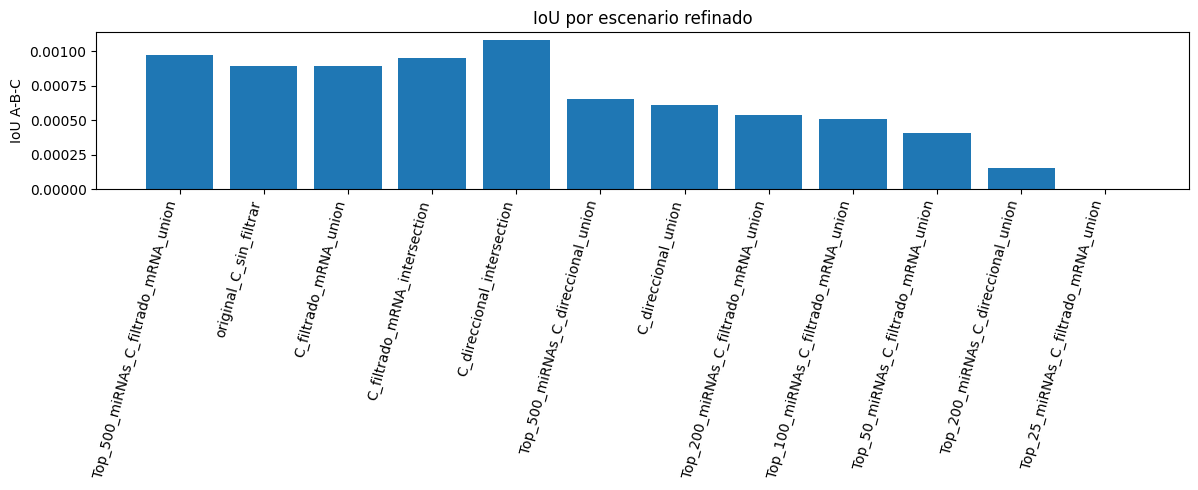

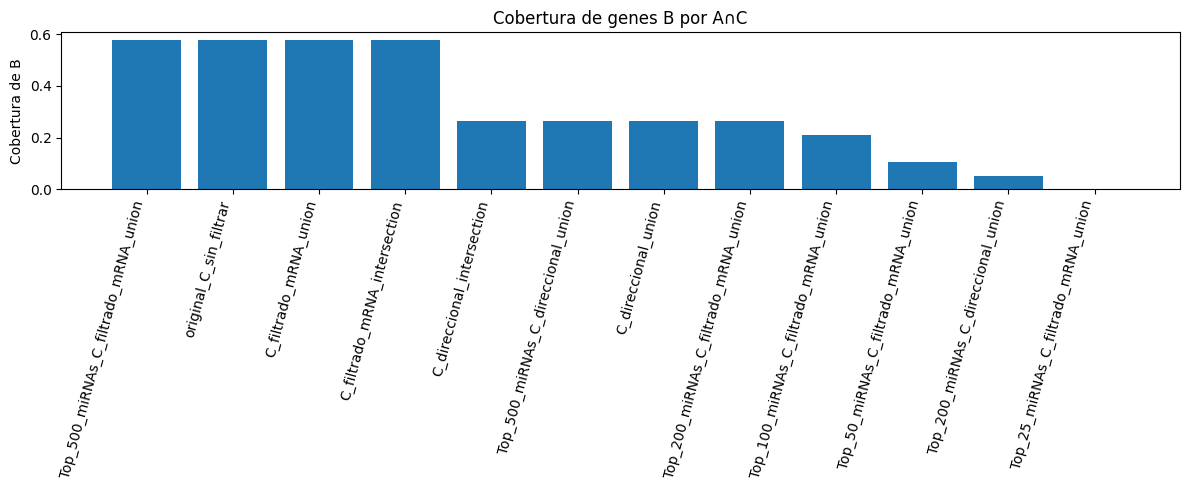

In [33]:
import matplotlib.pyplot as plt

plot_df = df_metricas_exp2.copy()
plot_df = plot_df.head(12)

plt.figure(figsize=(12, 5))
plt.bar(plot_df["escenario"], plot_df["iou_ABC"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU A-B-C")
plt.title("IoU por escenario refinado")
plt.tight_layout()
plt.savefig(os.path.join(EXP2_DIR, "plot_iou_por_escenario.png"), dpi=200)
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(plot_df["escenario"], plot_df["cobertura_B"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Cobertura de B")
plt.title("Cobertura de genes B por A∩C")
plt.tight_layout()
plt.savefig(os.path.join(EXP2_DIR, "plot_cobertura_B_por_escenario.png"), dpi=200)
plt.show()

## 31. Resumen final del Experimento 2

In [34]:
resumen_exp2 = f"""
RESUMEN EXPERIMENTO 2: IoU REFINADO
===================================

Objetivo:
Refinar el IoU original evitando que el conjunto C sea demasiado amplio
y agregando consistencia direccional miRNA–mRNA.

Conjunto A:
Genes diferenciales de E-GEOD-42568: {len(A)}

Conjunto B:
Genes diferenciales de E-MTAB-6703: {len(B)}

Conjunto C original:
Genes objetivo de miRNAs diferenciales: {len(C)}

C filtrado por universo mRNA unión:
{len(C_filtrado_union)}

C filtrado por universo mRNA intersección:
{len(C_filtrado_intersection)}

C direccional unión:
{len(C_dir_union)}

C direccional intersección:
{len(C_dir_intersection)}

Mejor escenario sugerido:
{mejor_nombre}

Métricas del mejor escenario:
- n_A: {int(mejor['n_A'])}
- n_B: {int(mejor['n_B'])}
- n_C: {int(mejor['n_C'])}
- n_interseccion_ABC: {int(mejor['n_interseccion_ABC'])}
- n_union_ABC: {int(mejor['n_union_ABC'])}
- IoU: {mejor['iou_ABC']}
- Cobertura A: {mejor['cobertura_A']}
- Cobertura B: {mejor['cobertura_B']}
- Cobertura C: {mejor['cobertura_C']}
- Fisher AB en C odds ratio: {mejor['fisher_AB_en_C_odds_ratio']}
- Fisher AB en C p-value: {mejor['fisher_AB_en_C_p_value']}

Archivos principales:
- metricas_todos_los_escenarios_exp2.csv
- C_filtrado_universo_mRNA_union.csv
- C_direccional_union.csv
- pares_miRNA_target_con_direccion_E-GEOD-42568.csv
- pares_miRNA_target_con_direccion_E-MTAB-6703.csv
- metricas_topN_miRNAs.csv
- metricas_topN_miRNAs_direccional.csv
- evidencia_genes_mejor_escenario.csv
- plot_iou_por_escenario.png
- plot_cobertura_B_por_escenario.png

Interpretación:
El IoU global puede seguir siendo bajo si C es grande; por eso se reportan también
cobertura de B y pruebas de enriquecimiento. La métrica más útil no es solo IoU,
sino si los genes estrictos de B están cubiertos por A y por targets de miRNAs
con dirección biológica consistente.
"""

print(resumen_exp2)

with open(os.path.join(EXP2_DIR, "resumen_experimento2_iou_refinado.txt"), "w", encoding="utf-8") as f:
    f.write(resumen_exp2)

print("Resumen guardado en:", os.path.join(EXP2_DIR, "resumen_experimento2_iou_refinado.txt"))


RESUMEN EXPERIMENTO 2: IoU REFINADO

Objetivo:
Refinar el IoU original evitando que el conjunto C sea demasiado amplio
y agregando consistencia direccional miRNA–mRNA.

Conjunto A:
Genes diferenciales de E-GEOD-42568: 2501

Conjunto B:
Genes diferenciales de E-MTAB-6703: 19

Conjunto C original:
Genes objetivo de miRNAs diferenciales: 11533

C filtrado por universo mRNA unión:
11303

C filtrado por universo mRNA intersección:
10822

C direccional unión:
6599

C direccional intersección:
3128

Mejor escenario sugerido:
Top_500_miRNAs_C_filtrado_mRNA_union

Métricas del mejor escenario:
- n_A: 2501
- n_B: 19
- n_C: 10184
- n_interseccion_ABC: 11
- n_union_ABC: 11289
- IoU: 0.0009743998582691115
- Cobertura A: 0.004398240703718513
- Cobertura B: 0.5789473684210527
- Cobertura C: 0.00108012568735271
- Fisher AB en C odds ratio: 2.3170320128444577
- Fisher AB en C p-value: 0.07256752269343146

Archivos principales:
- metricas_todos_los_escenarios_exp2.csv
- C_filtrado_universo_mRNA_union.c

# EXPERIMENTO 3: búsqueda de escenarios robustos y conjunto C más confiable

El Experimento 2 mostró que:

- `C` seguía siendo muy grande.
- El IoU global seguía bajo.
- La cobertura de `B` era interesante, pero Fisher no llegó a significancia.
- El mejor escenario automático favorecía cobertura, pero no necesariamente la mejor evidencia biológica.

Este Experimento 3 cambia el objetivo:

> No buscar un IoU artificialmente alto, sino encontrar un escenario más defendible biológicamente.

Se probarán combinaciones de:

1. `A` y `B` estrictos o relajados por Top-N genes.
2. `C` generado solo desde Top-N miRNAs.
3. `C` con mínimo número de miRNAs que apuntan al mismo gen.
4. `C` con dirección opuesta miRNA–mRNA.
5. Fisher exact test y métricas de cobertura.

El resultado final será una tabla de escenarios ordenados por:

```text
p-value de Fisher, odds ratio, tamaño de C, cobertura de B e IoU.
```

## 32. Configuración del Experimento 3

In [35]:
# ============================================================
# EXPERIMENTO 3: CONFIGURACIÓN
# ============================================================

EXP3_DIR = "outputs_busqueda_escenarios"
os.makedirs(EXP3_DIR, exist_ok=True)

print("Directorio Experimento 3:", EXP3_DIR)

# Variables que deben existir tras correr el pipeline base + experimento 2
variables_requeridas_exp3 = [
    "res_42568", "res_emtab", "sig_42568", "sig_emtab",
    "sig_mirna_named", "targets_mirna", "genes_objetivo_mirnas",
    "pares_dir_42568", "pares_dir_emtab",
    "A", "B", "C",
    "U_mrna_union", "U_mrna_intersection",
    "metricas_tres_conjuntos",
    "normalizar_simbolo_gen",
    "normalizar_mirna_core_key",
]

faltantes = [v for v in variables_requeridas_exp3 if v not in globals()]
if faltantes:
    raise RuntimeError(
        "Faltan variables necesarias. Ejecuta el notebook desde el inicio. "
        f"Variables faltantes: {faltantes}"
    )

print("Variables necesarias OK.")

Directorio Experimento 3: outputs_busqueda_escenarios
Variables necesarias OK.


## 33. Construir modos alternativos para A y B

`B` estricto tiene solo 19 genes. Por eso probaremos también `B_top100`, `B_top250` y `B_top500`.

In [36]:
def top_genes_desde_dge(res_df, n, gene_col="gene_symbol"):
    df = res_df.copy()
    df["abs_log2FC"] = df["log2FC_cancer_vs_normal"].abs()

    df = df.sort_values(
        ["p_adjusted_fdr", "abs_log2FC"],
        ascending=[True, False]
    )

    return set(
        df.head(n)[gene_col]
        .dropna()
        .map(normalizar_simbolo_gen)
        .dropna()
        .unique()
    )


A_modes = {
    "A_strict": A,
    "A_top250": top_genes_desde_dge(res_42568, 250),
    "A_top500": top_genes_desde_dge(res_42568, 500),
    "A_top1000": top_genes_desde_dge(res_42568, 1000),
}

B_modes = {
    "B_strict": B,
    "B_top50": top_genes_desde_dge(res_emtab, 50),
    "B_top100": top_genes_desde_dge(res_emtab, 100),
    "B_top250": top_genes_desde_dge(res_emtab, 250),
    "B_top500": top_genes_desde_dge(res_emtab, 500),
}

print("Modos A:")
for k, v in A_modes.items():
    print(k, len(v))

print("\nModos B:")
for k, v in B_modes.items():
    print(k, len(v))

Modos A:
A_strict 2501
A_top250 250
A_top500 500
A_top1000 1000

Modos B:
B_strict 19
B_top50 50
B_top100 100
B_top250 250
B_top500 500


## 34. Funciones para construir C más restrictivo

Se crearán variantes de `C` con Top-N miRNAs y mínimo número de miRNAs por gen.

In [37]:
def obtener_top_mirnas_exp3(sig_mirna_df, n):
    df = sig_mirna_df.copy()
    df["abs_log2FC"] = df["log2FC_cancer_vs_normal"].abs()

    df = df.sort_values(
        ["p_adjusted_fdr", "abs_log2FC"],
        ascending=[True, False]
    )

    df["mirna_core_key"] = df["mirna_name"].map(normalizar_mirna_core_key)

    return df.head(n).copy()


def construir_targets_top_mirnas(top_mirnas, targets_mirna):
    top = top_mirnas.copy()
    top["mirna_core_key"] = top["mirna_name"].map(normalizar_mirna_core_key)

    merged = top.merge(
        targets_mirna,
        on="mirna_core_key",
        how="inner",
        suffixes=("_sig", "_target")
    )

    if "mirna_name_sig" in merged.columns:
        merged["mirna_name"] = merged["mirna_name_sig"].fillna(merged.get("mirna_name_target"))
    elif "mirna_name" not in merged.columns and "mirna_name_target" in merged.columns:
        merged["mirna_name"] = merged["mirna_name_target"]

    merged["target_gene"] = merged["target_gene"].map(normalizar_simbolo_gen)
    merged = merged.dropna(subset=["target_gene", "mirna_core_key"]).drop_duplicates()

    return merged


def C_por_minimo_mirnas(merged_targets, min_mirnas=1, universo=None):
    """
    Construye C conservando genes apuntados por al menos min_mirnas miRNAs únicos.
    """
    conteo = (
        merged_targets
        .groupby("target_gene")["mirna_core_key"]
        .nunique()
        .reset_index(name="n_mirnas_que_apuntan")
    )

    genes = set(
        conteo.loc[
            conteo["n_mirnas_que_apuntan"] >= min_mirnas,
            "target_gene"
        ].dropna().map(normalizar_simbolo_gen).dropna().unique()
    )

    if universo is not None:
        genes = genes & set(universo)

    return genes, conteo


def construir_C_direccional_top_mirnas(top_mirnas, pares_dir_42568, pares_dir_emtab, min_mirnas=1, universo=None, modo="any"):
    """
    Construye C direccional usando solo Top-N miRNAs.

    modo:
        any  = dirección opuesta en al menos un dataset mRNA
        both = dirección opuesta en ambos datasets mRNA
    """
    top_keys = set(
        top_mirnas["mirna_name"]
        .map(normalizar_mirna_core_key)
        .dropna()
        .unique()
    )

    p1 = pares_dir_42568[
        pares_dir_42568["mirna_core_key"].isin(top_keys)
        & pares_dir_42568["direccion_opuesta_EGEOD42568"]
    ].copy()

    p2 = pares_dir_emtab[
        pares_dir_emtab["mirna_core_key"].isin(top_keys)
        & pares_dir_emtab["direccion_opuesta_EMTAB6703"]
    ].copy()

    p1["target_gene"] = p1["target_gene"].map(normalizar_simbolo_gen)
    p2["target_gene"] = p2["target_gene"].map(normalizar_simbolo_gen)

    if modo == "any":
        pares = pd.concat([p1, p2], ignore_index=True)
    elif modo == "both":
        genes_p1 = set(p1["target_gene"].dropna())
        genes_p2 = set(p2["target_gene"].dropna())
        genes_both = genes_p1 & genes_p2
        pares = pd.concat([
            p1[p1["target_gene"].isin(genes_both)],
            p2[p2["target_gene"].isin(genes_both)]
        ], ignore_index=True)
    else:
        raise ValueError("modo debe ser 'any' o 'both'")

    pares = pares.dropna(subset=["target_gene", "mirna_core_key"]).drop_duplicates()

    C_dir, conteo = C_por_minimo_mirnas(
        pares,
        min_mirnas=min_mirnas,
        universo=universo
    )

    return C_dir, pares, conteo

## 35. Búsqueda en grilla de escenarios

Se prueban múltiples combinaciones y se calcula Fisher para cada una.

In [38]:
top_mirna_values = [10, 25, 50, 100, 200, 500]
min_mirnas_values = [1, 2, 3, 5, 10]

resultados_grid = []
intersecciones_grid = {}
C_grid_store = {}

for top_n in top_mirna_values:
    top_mirnas = obtener_top_mirnas_exp3(sig_mirna_named, top_n)
    merged_targets = construir_targets_top_mirnas(top_mirnas, targets_mirna)

    for min_k in min_mirnas_values:
        # C no direccional, solo mínimo de miRNAs
        C_minK, conteo_minK = C_por_minimo_mirnas(
            merged_targets,
            min_mirnas=min_k,
            universo=U_mrna_union
        )

        C_variants = {
            f"C_top{top_n}_min{min_k}_allTargets": C_minK
        }

        # C direccional any
        C_dir_any, pares_any, conteo_any = construir_C_direccional_top_mirnas(
            top_mirnas,
            pares_dir_42568,
            pares_dir_emtab,
            min_mirnas=min_k,
            universo=U_mrna_union,
            modo="any"
        )

        C_variants[f"C_top{top_n}_min{min_k}_dirAny"] = C_dir_any

        # C direccional both
        C_dir_both, pares_both, conteo_both = construir_C_direccional_top_mirnas(
            top_mirnas,
            pares_dir_42568,
            pares_dir_emtab,
            min_mirnas=min_k,
            universo=U_mrna_intersection,
            modo="both"
        )

        C_variants[f"C_top{top_n}_min{min_k}_dirBoth"] = C_dir_both

        for C_name, C_set in C_variants.items():
            if len(C_set) == 0:
                continue

            for A_name, A_set in A_modes.items():
                for B_name, B_set in B_modes.items():
                    escenario = f"{A_name}__{B_name}__{C_name}"

                    # Universo usado: genes medidos en al menos un dataset mRNA
                    U_use = U_mrna_union

                    met = metricas_tres_conjuntos(
                        A_set,
                        B_set,
                        C_set,
                        U_use,
                        nombre=escenario
                    )

                    met["A_mode"] = A_name
                    met["B_mode"] = B_name
                    met["C_mode"] = C_name
                    met["top_mirnas"] = top_n
                    met["min_mirnas_por_gen"] = min_k
                    met["C_direccional"] = "dir" in C_name.lower()
                    met["C_both"] = "dirBoth" in C_name
                    met["n_C_original_escenario"] = len(C_set)

                    inter = set(A_set) & set(B_set) & set(C_set)
                    intersecciones_grid[escenario] = sorted(inter)
                    C_grid_store[escenario] = set(C_set)

                    resultados_grid.append(met)

df_grid_exp3 = pd.DataFrame(resultados_grid)

# Evitar escenarios sin intersección si solo queremos candidatos útiles
df_grid_exp3["neg_log10_fisher"] = -np.log10(df_grid_exp3["fisher_AB_en_C_p_value"].replace(0, np.nextafter(0, 1)))

# Ranking recomendado:
# 1. Fisher menor
# 2. Odds ratio mayor
# 3. C más pequeño
# 4. cobertura_B mayor
# 5. intersección mayor
df_grid_exp3 = df_grid_exp3.sort_values(
    [
        "fisher_AB_en_C_p_value",
        "fisher_AB_en_C_odds_ratio",
        "n_C",
        "cobertura_B",
        "n_interseccion_ABC"
    ],
    ascending=[True, False, True, False, False]
).reset_index(drop=True)

df_grid_exp3.to_csv(
    os.path.join(EXP3_DIR, "grid_escenarios_experimento3.csv"),
    index=False
)

print("Escenarios evaluados:", len(df_grid_exp3))
df_grid_exp3.head(20)

Escenarios evaluados: 1460


,escenario,n_universo,n_A,n_B,n_C,n_interseccion_ABC,n_union_ABC,iou_ABC,cobertura_A,cobertura_B,...,fisher_AB_en_C_d,A_mode,B_mode,C_mode,top_mirnas,min_mirnas_por_gen,C_direccional,C_both,n_C_original_escenario,neg_log10_fisher
0,A_strict__B_top500__C_top500_min1_allTargets,23047,2501,500,10184,215,11357,0.018931,0.085966,0.430,...,12806,A_strict,B_top500,C_top500_min1_allTargets,500,1,False,False,10184,31.524673
1,A_strict__B_top500__C_top200_min1_allTargets,23047,2501,500,7878,185,9331,0.019826,0.073970,0.370,...,15082,A_strict,B_top500,C_top200_min1_allTargets,200,1,False,False,7878,29.536820
2,A_strict__B_top250__C_top200_min1_allTargets,23047,2501,250,7878,121,9274,0.013047,0.048381,0.484,...,15131,A_strict,B_top250,C_top200_min1_allTargets,200,1,False,False,7878,26.580520
3,A_strict__B_top500__C_top100_min1_allTargets,23047,2501,500,6259,156,7964,0.019588,0.062375,0.312,...,16672,A_strict,B_top500,C_top100_min1_allTargets,100,1,False,False,6259,25.174853
4,A_strict__B_top250__C_top500_min2_allTargets,23047,2501,250,5161,96,6935,0.013843,0.038385,0.384,...,17823,A_strict,B_top250,C_top500_min2_allTargets,500,2,False,False,5161,24.257483
5,A_strict__B_top250__C_top100_min1_allTargets,23047,2501,250,6259,105,7894,0.013301,0.041983,0.420,...,16734,A_strict,B_top250,C_top100_min1_allTargets,100,1,False,False,6259,23.892032
6,A_strict__B_top250__C_top500_min1_allTargets,23047,2501,250,10184,132,11315,0.011666,0.052779,0.528,...,12836,A_strict,B_top250,C_top500_min1_allTargets,500,1,False,False,10184,23.344814
7,A_strict__B_top250__C_top200_min2_allTargets,23047,2501,250,3672,77,5663,0.013597,0.030788,0.308,...,19293,A_strict,B_top250,C_top200_min2_allTargets,200,2,False,False,3672,21.065716
8,A_strict__B_top500__C_top500_min2_allTargets,23047,2501,500,5161,132,7019,0.018806,0.052779,0.264,...,17746,A_strict,B_top500,C_top500_min2_allTargets,500,2,False,False,5161,20.805622
9,A_strict__B_top500__C_top200_min2_allTargets,23047,2501,500,3672,105,5759,0.018232,0.041983,0.210,...,19208,A_strict,B_top500,C_top200_min2_allTargets,200,2,False,False,3672,18.984081


## 36. Filtrar escenarios defendibles

Separamos escenarios significativos, con intersección no trivial y C razonable.

In [39]:
# Criterios sugeridos para escenarios defendibles
df_defendibles = df_grid_exp3[
    (df_grid_exp3["n_interseccion_ABC"] >= 3)
    & (df_grid_exp3["n_C"] <= 5000)
    & (df_grid_exp3["fisher_AB_en_C_p_value"] < 0.05)
].copy()

df_tendencias = df_grid_exp3[
    (df_grid_exp3["n_interseccion_ABC"] >= 3)
    & (df_grid_exp3["n_C"] <= 5000)
    & (df_grid_exp3["fisher_AB_en_C_p_value"] >= 0.05)
    & (df_grid_exp3["fisher_AB_en_C_p_value"] < 0.10)
].copy()

df_defendibles.to_csv(
    os.path.join(EXP3_DIR, "escenarios_defendibles_p005.csv"),
    index=False
)

df_tendencias.to_csv(
    os.path.join(EXP3_DIR, "escenarios_tendencia_p010.csv"),
    index=False
)

print("Escenarios defendibles p<0.05:", len(df_defendibles))
print("Escenarios tendencia 0.05<=p<0.10:", len(df_tendencias))

display(df_defendibles.head(20))
display(df_tendencias.head(20))

Escenarios defendibles p<0.05: 129
Escenarios tendencia 0.05<=p<0.10: 21


,escenario,n_universo,n_A,n_B,n_C,n_interseccion_ABC,n_union_ABC,iou_ABC,cobertura_A,cobertura_B,...,fisher_AB_en_C_d,A_mode,B_mode,C_mode,top_mirnas,min_mirnas_por_gen,C_direccional,C_both,n_C_original_escenario,neg_log10_fisher
7,A_strict__B_top250__C_top200_min2_allTargets,23047,2501,250,3672,77,5663,0.013597,0.030788,0.308,...,19293,A_strict,B_top250,C_top200_min2_allTargets,200,2,False,False,3672,21.065716
9,A_strict__B_top500__C_top200_min2_allTargets,23047,2501,500,3672,105,5759,0.018232,0.041983,0.210,...,19208,A_strict,B_top500,C_top200_min2_allTargets,200,2,False,False,3672,18.984081
10,A_strict__B_top500__C_top500_min1_dirBoth,23047,2501,500,2871,88,4879,0.018036,0.035186,0.176,...,19992,A_strict,B_top500,C_top500_min1_dirBoth,500,1,True,True,2871,17.264748
11,A_strict__B_top250__C_top100_min2_allTargets,23047,2501,250,2304,56,4520,0.012389,0.022391,0.224,...,20640,A_strict,B_top250,C_top100_min2_allTargets,100,2,False,False,2304,17.168275
12,A_strict__B_top250__C_top500_min3_allTargets,23047,2501,250,2786,60,4926,0.012180,0.023990,0.240,...,20162,A_strict,B_top250,C_top500_min3_allTargets,500,3,False,False,2786,16.056349
13,A_strict__B_top250__C_top200_min3_allTargets,23047,2501,250,1749,46,4051,0.011355,0.018393,0.184,...,21185,A_strict,B_top250,C_top200_min3_allTargets,200,3,False,False,1749,15.063586
14,A_strict__B_top500__C_top500_min3_allTargets,23047,2501,500,2786,82,5032,0.016296,0.032787,0.164,...,20071,A_strict,B_top500,C_top500_min3_allTargets,500,3,False,False,2786,14.901828
15,A_strict__B_top500__C_top100_min2_allTargets,23047,2501,500,2304,72,4631,0.015547,0.028788,0.144,...,20543,A_strict,B_top500,C_top100_min2_allTargets,100,2,False,False,2304,14.206369
17,A_strict__B_top500__C_top200_min3_allTargets,23047,2501,500,1749,60,4167,0.014399,0.023990,0.120,...,21086,A_strict,B_top500,C_top200_min3_allTargets,200,3,False,False,1749,13.424691
19,A_strict__B_top500__C_top200_min1_dirBoth,23047,2501,500,2189,68,4333,0.015694,0.027189,0.136,...,20654,A_strict,B_top500,C_top200_min1_dirBoth,200,1,True,True,2189,13.225031


,escenario,n_universo,n_A,n_B,n_C,n_interseccion_ABC,n_union_ABC,iou_ABC,cobertura_A,cobertura_B,...,fisher_AB_en_C_d,A_mode,B_mode,C_mode,top_mirnas,min_mirnas_por_gen,C_direccional,C_both,n_C_original_escenario,neg_log10_fisher
187,A_top500__B_top250__C_top200_min5_allTargets,23047,500,250,416,3,1086,0.002762,0.006000,0.012000,...,22588,A_top500,B_top250,C_top200_min5_allTargets,200,5,False,False,416,1.300215
188,A_top1000__B_top500__C_top25_min1_allTargets,23047,1000,500,653,7,1958,0.003575,0.007000,0.014000,...,22283,A_top1000,B_top500,C_top25_min1_allTargets,25,1,False,False,653,1.293985
189,A_strict__B_top250__C_top10_min1_allTargets,23047,2501,250,290,5,2841,0.001760,0.001999,0.020000,...,22603,A_strict,B_top250,C_top10_min1_allTargets,10,1,False,False,290,1.292837
190,A_strict__B_strict__C_top500_min1_dirBoth,23047,2501,19,2871,5,4703,0.001063,0.001999,0.263158,...,20164,A_strict,B_strict,C_top500_min1_dirBoth,500,1,True,True,2871,1.291291
191,A_strict__B_top250__C_top100_min3_dirAny,23047,2501,250,485,7,3004,0.002330,0.002799,0.028000,...,22410,A_strict,B_top250,C_top100_min3_dirAny,100,3,True,False,485,1.288109
192,A_strict__B_top500__C_top200_min2_dirAny,23047,2501,500,2094,33,4490,0.007350,0.013195,0.066000,...,20714,A_strict,B_top500,C_top200_min2_dirAny,200,2,True,False,2094,1.270939
194,A_top500__B_top100__C_top100_min3_allTargets,23047,500,100,903,3,1434,0.002092,0.006000,0.030000,...,22124,A_top500,B_top100,C_top100_min3_allTargets,100,3,False,False,903,1.227050
195,A_strict__B_top250__C_top50_min2_dirBoth,23047,2501,250,212,4,2749,0.001455,0.001599,0.016000,...,22680,A_strict,B_top250,C_top50_min2_dirBoth,50,2,True,True,212,1.225248
196,A_top1000__B_top500__C_top10_min1_allTargets,23047,1000,500,290,4,1631,0.002452,0.004000,0.008000,...,22643,A_top1000,B_top500,C_top10_min1_allTargets,10,1,False,False,290,1.207049
197,A_top500__B_top50__C_top500_min3_allTargets,23047,500,50,2786,4,3213,0.001245,0.008000,0.080000,...,20252,A_top500,B_top50,C_top500_min3_allTargets,500,3,False,False,2786,1.206296


## 37. Elegir mejor escenario del Experimento 3

In [40]:
if len(df_defendibles) > 0:
    mejor_exp3 = df_defendibles.iloc[0].copy()
    tipo_resultado_exp3 = "SIGNIFICATIVO_P005"
elif len(df_tendencias) > 0:
    mejor_exp3 = df_tendencias.iloc[0].copy()
    tipo_resultado_exp3 = "TENDENCIA_P010"
else:
    # Si no hay escenario defendible, elegir el mejor global pero marcarlo como exploratorio.
    mejor_exp3 = df_grid_exp3.iloc[0].copy()
    tipo_resultado_exp3 = "EXPLORATORIO_NO_SIGNIFICATIVO"

mejor_nombre_exp3 = mejor_exp3["escenario"]

print("Tipo de resultado:", tipo_resultado_exp3)
print("Mejor escenario Experimento 3:")
print(mejor_exp3)

C_mejor_exp3 = C_grid_store[mejor_nombre_exp3]
genes_inter_mejor_exp3 = intersecciones_grid[mejor_nombre_exp3]

pd.DataFrame({"gene_symbol": genes_inter_mejor_exp3}).to_csv(
    os.path.join(EXP3_DIR, "interseccion_mejor_escenario_exp3.csv"),
    index=False
)

pd.DataFrame({"gene_symbol": sorted(C_mejor_exp3)}).to_csv(
    os.path.join(EXP3_DIR, "C_mejor_escenario_exp3.csv"),
    index=False
)

print("Genes en intersección del mejor escenario:", len(genes_inter_mejor_exp3))
genes_inter_mejor_exp3[:30]

Tipo de resultado: SIGNIFICATIVO_P005
Mejor escenario Experimento 3:
escenario                    A_strict__B_top250__C_top200_min2_allTargets
n_universo                                                          23047
n_A                                                                  2501
n_B                                                                   250
n_C                                                                  3672
n_interseccion_ABC                                                     77
n_union_ABC                                                          5663
iou_ABC                                                          0.013597
cobertura_A                                                      0.030788
cobertura_B                                                         0.308
cobertura_C                                                      0.020969
n_AB                                                                  159
n_AC                                       

['ASPM',
 'ATAD2',
 'AURKA',
 'BIRC5',
 'BUB1B',
 'CAV1',
 'CCNB1',
 'CCNE2',
 'CDC20',
 'CDC7',
 'CDCA3',
 'CDCA8',
 'CDKN1C',
 'CDKN3',
 'CENPF',
 'CEP55',
 'CKS2',
 'CORO2A',
 'DCTPP1',
 'DMD',
 'DTL',
 'E2F8',
 'EGR1',
 'EZH2',
 'FAM83D',
 'FANCI',
 'FEN1',
 'FOXO1',
 'GGCT',
 'GINS1']

## 38. Evidencia detallada del mejor escenario

Se construye una tabla con log2FC, FDR y miRNAs asociados.

In [41]:
evidencias_exp3 = []

for g in genes_inter_mejor_exp3:
    row = {
        "gene_symbol": g,
        "escenario": mejor_nombre_exp3,
        "tipo_resultado": tipo_resultado_exp3,
        "en_A_strict": g in A,
        "en_B_strict": g in B,
        "en_C_mejor": g in C_mejor_exp3,
    }

    r1 = res_42568[res_42568["gene_symbol"] == g]
    if len(r1) > 0:
        row["log2FC_E-GEOD-42568"] = float(r1.iloc[0]["log2FC_cancer_vs_normal"])
        row["FDR_E-GEOD-42568"] = float(r1.iloc[0]["p_adjusted_fdr"])
        row["dir_E-GEOD-42568"] = r1.iloc[0]["direccion"]
        row["sig_E-GEOD-42568"] = bool(r1.iloc[0]["significativo"])

    r2 = res_emtab[res_emtab["gene_symbol"] == g]
    if len(r2) > 0:
        row["log2FC_E-MTAB-6703"] = float(r2.iloc[0]["log2FC_cancer_vs_normal"])
        row["FDR_E-MTAB-6703"] = float(r2.iloc[0]["p_adjusted_fdr"])
        row["dir_E-MTAB-6703"] = r2.iloc[0]["direccion"]
        row["sig_E-MTAB-6703"] = bool(r2.iloc[0]["significativo"])

    mirnas_rel = genes_objetivo_mirnas.loc[
        genes_objetivo_mirnas["target_gene"].map(normalizar_simbolo_gen) == g,
        "mirna_name"
    ].dropna().unique().tolist()

    row["n_miRNAs_diferenciales_que_lo_apuntan"] = len(mirnas_rel)
    row["miRNAs_diferenciales_que_lo_apuntan"] = ";".join(sorted(mirnas_rel[:100]))

    # Direccionales por dataset
    mirnas_dir_42568 = pares_dir_42568.loc[
        (pares_dir_42568["target_gene"].map(normalizar_simbolo_gen) == g)
        & (pares_dir_42568["direccion_opuesta_EGEOD42568"]),
        "mirna_name"
    ].dropna().unique().tolist()

    mirnas_dir_emtab = pares_dir_emtab.loc[
        (pares_dir_emtab["target_gene"].map(normalizar_simbolo_gen) == g)
        & (pares_dir_emtab["direccion_opuesta_EMTAB6703"]),
        "mirna_name"
    ].dropna().unique().tolist()

    row["n_miRNAs_direccionales_E-GEOD-42568"] = len(mirnas_dir_42568)
    row["miRNAs_direccionales_E-GEOD-42568"] = ";".join(sorted(mirnas_dir_42568[:100]))

    row["n_miRNAs_direccionales_E-MTAB-6703"] = len(mirnas_dir_emtab)
    row["miRNAs_direccionales_E-MTAB-6703"] = ";".join(sorted(mirnas_dir_emtab[:100]))

    evidencias_exp3.append(row)

df_evidencia_exp3 = pd.DataFrame(evidencias_exp3)

df_evidencia_exp3.to_csv(
    os.path.join(EXP3_DIR, "evidencia_mejor_escenario_exp3.csv"),
    index=False
)

df_evidencia_exp3

,gene_symbol,escenario,tipo_resultado,en_A_strict,en_B_strict,en_C_mejor,log2FC_E-GEOD-42568,FDR_E-GEOD-42568,dir_E-GEOD-42568,sig_E-GEOD-42568,log2FC_E-MTAB-6703,FDR_E-MTAB-6703,dir_E-MTAB-6703,sig_E-MTAB-6703,n_miRNAs_diferenciales_que_lo_apuntan,miRNAs_diferenciales_que_lo_apuntan,n_miRNAs_direccionales_E-GEOD-42568,miRNAs_direccionales_E-GEOD-42568,n_miRNAs_direccionales_E-MTAB-6703,miRNAs_direccionales_E-MTAB-6703
0,ASPM,A_strict__B_top250__C_top200_min2_allTargets,SIGNIFICATIVO_P005,True,False,True,2.112214,5.644689e-06,UP_EN_CANCER,True,0.969643,0.000000e+00,UP_EN_CANCER,False,5,hsa-let-7a-5p;hsa-miR-192-5p;hsa-miR-193b-3p;h...,0,,0,
1,ATAD2,A_strict__B_top250__C_top200_min2_allTargets,SIGNIFICATIVO_P005,True,False,True,1.518916,4.612101e-13,UP_EN_CANCER,True,0.659022,5.955770e-34,UP_EN_CANCER,False,5,hsa-miR-106b-5p;hsa-miR-17-3p;hsa-miR-192-5p;h...,0,,0,
2,AURKA,A_strict__B_top250__C_top200_min2_allTargets,SIGNIFICATIVO_P005,True,False,True,1.953547,1.393038e-07,UP_EN_CANCER,True,0.848301,1.820082e-34,UP_EN_CANCER,False,4,hsa-let-7b-5p;hsa-miR-124-3p;hsa-miR-155-5p;hs...,0,,0,
3,BIRC5,A_strict__B_top250__C_top200_min2_allTargets,SIGNIFICATIVO_P005,True,False,True,1.136224,3.741801e-05,UP_EN_CANCER,True,0.818431,1.054577e-30,UP_EN_CANCER,False,11,hsa-let-7b-5p;hsa-miR-101-3p;hsa-miR-10a-5p;hs...,0,,0,
4,BUB1B,A_strict__B_top250__C_top200_min2_allTargets,SIGNIFICATIVO_P005,True,False,True,2.592662,2.084830e-05,UP_EN_CANCER,True,0.778289,1.071839e-31,UP_EN_CANCER,False,4,hsa-miR-192-5p;hsa-miR-193b-3p;hsa-miR-215-5p;...,0,,0,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,UBE2C,A_strict__B_top250__C_top200_min2_allTargets,SIGNIFICATIVO_P005,True,False,True,2.786914,4.541405e-07,UP_EN_CANCER,True,0.844769,1.041165e-36,UP_EN_CANCER,False,8,hsa-miR-140-3p;hsa-miR-16-5p;hsa-miR-17-5p;hsa...,0,,0,
73,UHRF1,A_strict__B_top250__C_top200_min2_allTargets,SIGNIFICATIVO_P005,True,False,True,3.579936,1.681868e-06,UP_EN_CANCER,True,0.837511,3.722015e-35,UP_EN_CANCER,False,10,hsa-let-7a-5p;hsa-let-7b-5p;hsa-miR-10a-5p;hsa...,0,,0,
74,WLS,A_strict__B_top250__C_top200_min2_allTargets,SIGNIFICATIVO_P005,True,False,True,-1.374813,1.455777e-03,DOWN_EN_CANCER,True,-0.735080,1.512305e-28,DOWN_EN_CANCER,False,3,hsa-let-7b-5p;hsa-miR-186-5p;hsa-miR-26b-5p,3,hsa-let-7b-5p;hsa-miR-186-5p;hsa-miR-26b-5p,3,hsa-let-7b-5p;hsa-miR-186-5p;hsa-miR-26b-5p
75,ZNF367,A_strict__B_top250__C_top200_min2_allTargets,SIGNIFICATIVO_P005,True,False,True,1.144109,4.049665e-07,UP_EN_CANCER,True,0.586880,4.404884e-25,UP_EN_CANCER,False,2,hsa-miR-21-5p;hsa-miR-99a-5p,0,,0,


## 39. Comparar Experimento 1, 2 y 3

In [42]:
comparacion_experimentos = []

# Experimento 1/2 base si existen variables
try:
    comparacion_experimentos.append({
        "experimento": "Exp1_original",
        "escenario": "A_strict_B_strict_C_original",
        "n_A": len(A),
        "n_B": len(B),
        "n_C": len(C),
        "n_interseccion_ABC": len(set(A) & set(B) & set(C)),
        "n_union_ABC": len(set(A) | set(B) | set(C)),
        "iou_ABC": len(set(A) & set(B) & set(C)) / len(set(A) | set(B) | set(C)),
        "cobertura_B": len(set(A) & set(B) & set(C)) / len(B) if len(B) else np.nan,
        "fisher_AB_en_C_p_value": np.nan,
        "tipo_resultado": "BASE"
    })
except Exception:
    pass

try:
    comparacion_experimentos.append({
        "experimento": "Exp2_mejor",
        "escenario": mejor_nombre,
        "n_A": int(mejor["n_A"]),
        "n_B": int(mejor["n_B"]),
        "n_C": int(mejor["n_C"]),
        "n_interseccion_ABC": int(mejor["n_interseccion_ABC"]),
        "n_union_ABC": int(mejor["n_union_ABC"]),
        "iou_ABC": float(mejor["iou_ABC"]),
        "cobertura_B": float(mejor["cobertura_B"]),
        "fisher_AB_en_C_p_value": float(mejor["fisher_AB_en_C_p_value"]),
        "tipo_resultado": "EXP2"
    })
except Exception:
    pass

comparacion_experimentos.append({
    "experimento": "Exp3_mejor",
    "escenario": mejor_nombre_exp3,
    "n_A": int(mejor_exp3["n_A"]),
    "n_B": int(mejor_exp3["n_B"]),
    "n_C": int(mejor_exp3["n_C"]),
    "n_interseccion_ABC": int(mejor_exp3["n_interseccion_ABC"]),
    "n_union_ABC": int(mejor_exp3["n_union_ABC"]),
    "iou_ABC": float(mejor_exp3["iou_ABC"]),
    "cobertura_B": float(mejor_exp3["cobertura_B"]),
    "fisher_AB_en_C_p_value": float(mejor_exp3["fisher_AB_en_C_p_value"]),
    "tipo_resultado": tipo_resultado_exp3
})

df_comparacion_exp = pd.DataFrame(comparacion_experimentos)

df_comparacion_exp.to_csv(
    os.path.join(EXP3_DIR, "comparacion_experimentos_1_2_3.csv"),
    index=False
)

df_comparacion_exp

,experimento,escenario,n_A,n_B,n_C,n_interseccion_ABC,n_union_ABC,iou_ABC,cobertura_B,fisher_AB_en_C_p_value,tipo_resultado
0,Exp1_original,A_strict_B_strict_C_original,2501,19,11533,11,12505,0.000880,0.578947,NaN,BASE
1,Exp2_mejor,Top_500_miRNAs_C_filtrado_mRNA_union,2501,19,10184,11,11289,0.000974,0.578947,7.256752e-02,EXP2
2,Exp3_mejor,A_strict__B_top250__C_top200_min2_allTargets,2501,250,3672,77,5663,0.013597,0.308000,8.595749e-22,SIGNIFICATIVO_P005


## 40. Visualizaciones del Experimento 3

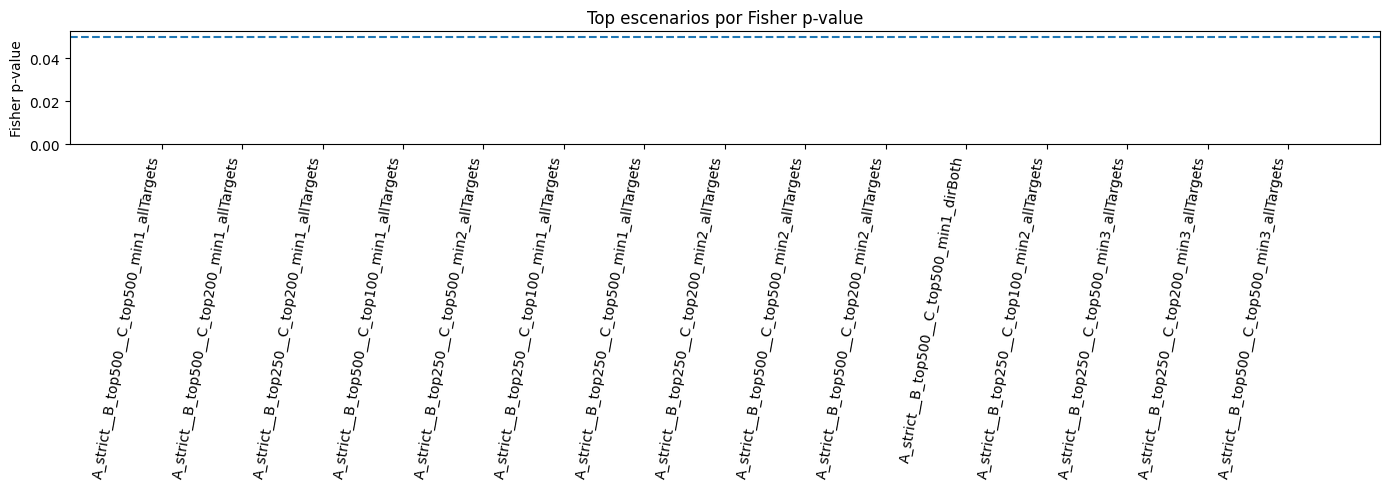

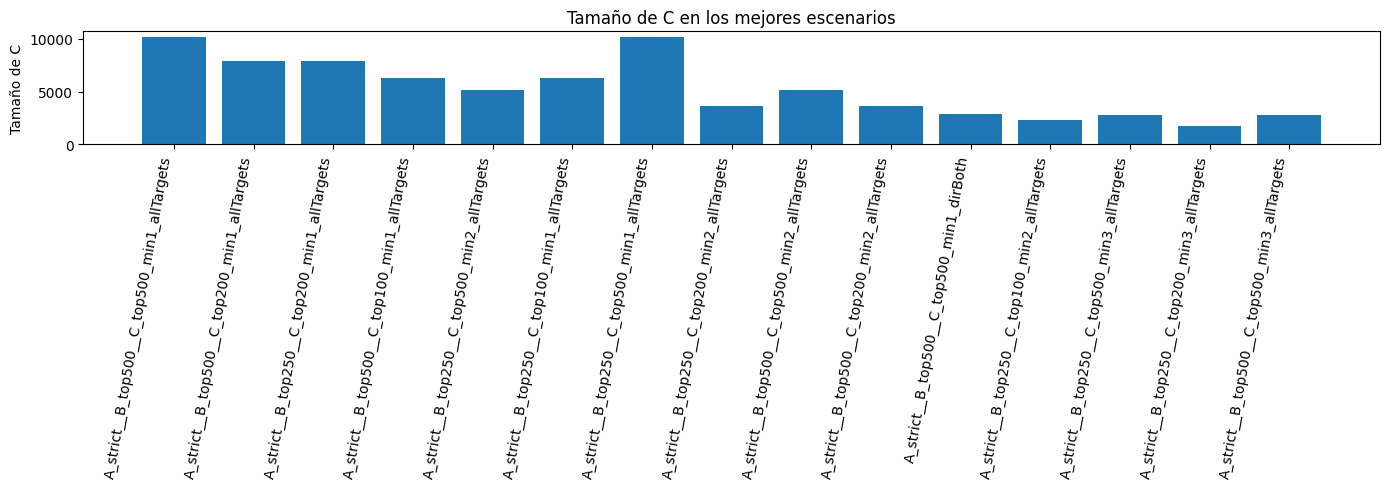

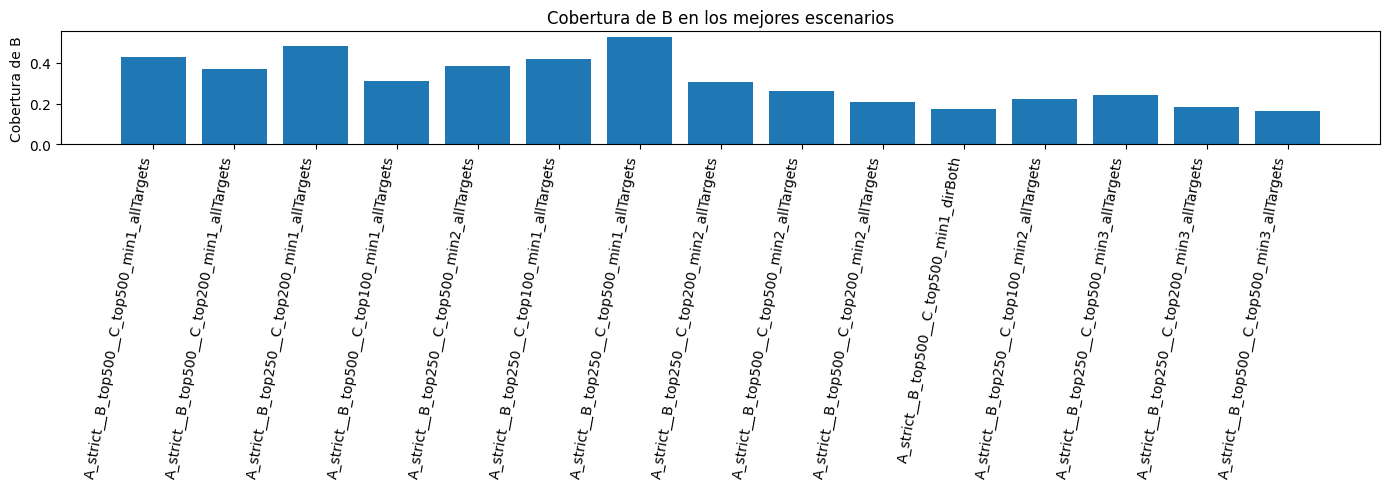

In [43]:
import matplotlib.pyplot as plt

top_plot = df_grid_exp3.head(15).copy()

plt.figure(figsize=(14, 5))
plt.bar(top_plot["escenario"], top_plot["fisher_AB_en_C_p_value"])
plt.axhline(0.05, linestyle="--")
plt.xticks(rotation=80, ha="right")
plt.ylabel("Fisher p-value")
plt.title("Top escenarios por Fisher p-value")
plt.tight_layout()
plt.savefig(os.path.join(EXP3_DIR, "plot_top_escenarios_fisher_pvalue.png"), dpi=200)
plt.show()

plt.figure(figsize=(14, 5))
plt.bar(top_plot["escenario"], top_plot["n_C"])
plt.xticks(rotation=80, ha="right")
plt.ylabel("Tamaño de C")
plt.title("Tamaño de C en los mejores escenarios")
plt.tight_layout()
plt.savefig(os.path.join(EXP3_DIR, "plot_top_escenarios_nC.png"), dpi=200)
plt.show()

plt.figure(figsize=(14, 5))
plt.bar(top_plot["escenario"], top_plot["cobertura_B"])
plt.xticks(rotation=80, ha="right")
plt.ylabel("Cobertura de B")
plt.title("Cobertura de B en los mejores escenarios")
plt.tight_layout()
plt.savefig(os.path.join(EXP3_DIR, "plot_top_escenarios_coberturaB.png"), dpi=200)
plt.show()

## 41. Resumen final del Experimento 3

In [44]:
if tipo_resultado_exp3 == "SIGNIFICATIVO_P005":
    interpretacion_estadistica = (
        "Se encontró al menos un escenario con enriquecimiento significativo "
        "según Fisher exact test (p < 0.05)."
    )
elif tipo_resultado_exp3 == "TENDENCIA_P010":
    interpretacion_estadistica = (
        "No se alcanzó p < 0.05, pero se encontró una tendencia de enriquecimiento "
        "con p < 0.10."
    )
else:
    interpretacion_estadistica = (
        "No se encontró un escenario estadísticamente significativo ni una tendencia fuerte. "
        "El resultado debe considerarse exploratorio."
    )

resumen_exp3 = f"""
RESUMEN EXPERIMENTO 3: BÚSQUEDA DE ESCENARIOS ROBUSTOS
======================================================

Objetivo:
Encontrar un escenario más defendible que el IoU global original,
reduciendo el conjunto C mediante:
- Top-N miRNAs diferenciales.
- Número mínimo de miRNAs que apuntan al mismo gen.
- Dirección opuesta miRNA–mRNA.
- Evaluación con Fisher exact test.

Escenarios evaluados:
{len(df_grid_exp3)}

Escenarios con p < 0.05:
{len(df_defendibles)}

Escenarios con tendencia 0.05 <= p < 0.10:
{len(df_tendencias)}

Tipo de resultado seleccionado:
{tipo_resultado_exp3}

Mejor escenario:
{mejor_nombre_exp3}

Métricas del mejor escenario:
- n_A: {int(mejor_exp3['n_A'])}
- n_B: {int(mejor_exp3['n_B'])}
- n_C: {int(mejor_exp3['n_C'])}
- n_interseccion_ABC: {int(mejor_exp3['n_interseccion_ABC'])}
- n_union_ABC: {int(mejor_exp3['n_union_ABC'])}
- IoU: {float(mejor_exp3['iou_ABC'])}
- Cobertura A: {float(mejor_exp3['cobertura_A'])}
- Cobertura B: {float(mejor_exp3['cobertura_B'])}
- Cobertura C: {float(mejor_exp3['cobertura_C'])}
- Fisher odds ratio: {float(mejor_exp3['fisher_AB_en_C_odds_ratio'])}
- Fisher p-value: {float(mejor_exp3['fisher_AB_en_C_p_value'])}

Interpretación estadística:
{interpretacion_estadistica}

Archivos principales:
- grid_escenarios_experimento3.csv
- escenarios_defendibles_p005.csv
- escenarios_tendencia_p010.csv
- interseccion_mejor_escenario_exp3.csv
- C_mejor_escenario_exp3.csv
- evidencia_mejor_escenario_exp3.csv
- comparacion_experimentos_1_2_3.csv
- plot_top_escenarios_fisher_pvalue.png
- plot_top_escenarios_nC.png
- plot_top_escenarios_coberturaB.png

Conclusión:
Este experimento no intenta forzar un IoU alto. Busca el escenario con mejor
soporte estadístico y biológico. Si el mejor escenario no es significativo,
la conclusión correcta es que la integración multi-ómica muestra evidencia
exploratoria, pero todavía requiere validación o criterios más específicos.
"""

print(resumen_exp3)

with open(os.path.join(EXP3_DIR, "resumen_experimento3_busqueda_escenarios.txt"), "w", encoding="utf-8") as f:
    f.write(resumen_exp3)

print("Resumen guardado en:", os.path.join(EXP3_DIR, "resumen_experimento3_busqueda_escenarios.txt"))


RESUMEN EXPERIMENTO 3: BÚSQUEDA DE ESCENARIOS ROBUSTOS

Objetivo:
Encontrar un escenario más defendible que el IoU global original,
reduciendo el conjunto C mediante:
- Top-N miRNAs diferenciales.
- Número mínimo de miRNAs que apuntan al mismo gen.
- Dirección opuesta miRNA–mRNA.
- Evaluación con Fisher exact test.

Escenarios evaluados:
1460

Escenarios con p < 0.05:
129

Escenarios con tendencia 0.05 <= p < 0.10:
21

Tipo de resultado seleccionado:
SIGNIFICATIVO_P005

Mejor escenario:
A_strict__B_top250__C_top200_min2_allTargets

Métricas del mejor escenario:
- n_A: 2501
- n_B: 250
- n_C: 3672
- n_interseccion_ABC: 77
- n_union_ABC: 5663
- IoU: 0.013597033374536464
- Cobertura A: 0.03078768492602959
- Cobertura B: 0.308
- Cobertura C: 0.020969498910675382
- Fisher odds ratio: 5.039387360493911
- Fisher p-value: 8.59574876182422e-22

Interpretación estadística:
Se encontró al menos un escenario con enriquecimiento significativo según Fisher exact test (p < 0.05).

Archivos principale

# EXPERIMENTO 4: corrección múltiple y validación robusta del Experimento 3

El Experimento 3 encontró un escenario con señal fuerte:

```text
A_strict__B_top250__C_top200_min2_allTargets
```

Pero hay un punto metodológico clave:

> Se probaron 1460 escenarios. Por tanto, los p-values de Fisher deben corregirse por múltiples pruebas.

Este Experimento 4 corrige el Experimento 3 agregando:

1. Corrección Bonferroni.
2. Corrección FDR Benjamini-Hochberg.
3. Selección del mejor escenario después de corrección múltiple.
4. Separación entre:
   - mejor escenario estadístico global;
   - mejor escenario direccional;
   - mejor escenario direccional y compacto.
5. Análisis de estabilidad de genes:
   - genes que aparecen repetidamente en escenarios significativos.
6. Tabla final de candidatos robustos.
7. Resumen interpretativo honesto:
   - significativo corregido;
   - tendencia;
   - exploratorio.

## 42. Configuración del Experimento 4

In [45]:
# ============================================================
# EXPERIMENTO 4: CONFIGURACIÓN
# ============================================================

EXP4_DIR = "outputs_correccion_multiple"
os.makedirs(EXP4_DIR, exist_ok=True)

print("Directorio Experimento 4:", EXP4_DIR)

variables_requeridas_exp4 = [
    "df_grid_exp3",
    "intersecciones_grid",
    "C_grid_store",
    "res_42568",
    "res_emtab",
    "genes_objetivo_mirnas",
    "pares_dir_42568",
    "pares_dir_emtab",
    "normalizar_simbolo_gen",
    "tipo_resultado_exp3",
    "mejor_nombre_exp3",
    "mejor_exp3",
]

faltantes = [v for v in variables_requeridas_exp4 if v not in globals()]
if faltantes:
    raise RuntimeError(
        "Faltan variables del Experimento 3. Ejecuta el notebook desde el inicio. "
        f"Variables faltantes: {faltantes}"
    )

print("Variables necesarias OK.")
print("Escenarios evaluados en Exp3:", len(df_grid_exp3))

Directorio Experimento 4: outputs_correccion_multiple
Variables necesarias OK.
Escenarios evaluados en Exp3: 1460


## 43. Corrección múltiple de p-values

Se agregan dos correcciones:

- **Bonferroni**: muy estricta.
- **FDR Benjamini-Hochberg**: más adecuada para búsqueda exploratoria con muchos escenarios.

In [46]:
# ============================================================
# CORRECCIÓN MÚLTIPLE
# ============================================================

df_exp4 = df_grid_exp3.copy()

pvals = df_exp4["fisher_AB_en_C_p_value"].astype(float).fillna(1.0).values
m_tests = len(pvals)

df_exp4["p_bonferroni"] = np.minimum(pvals * m_tests, 1.0)
df_exp4["p_fdr_bh"] = ajustar_fdr_bh(pvals)

df_exp4["significativo_bonferroni_005"] = df_exp4["p_bonferroni"] < 0.05
df_exp4["significativo_fdr_005"] = df_exp4["p_fdr_bh"] < 0.05
df_exp4["tendencia_fdr_010"] = (df_exp4["p_fdr_bh"] >= 0.05) & (df_exp4["p_fdr_bh"] < 0.10)

# Ranking corregido
df_exp4 = df_exp4.sort_values(
    [
        "p_fdr_bh",
        "p_bonferroni",
        "fisher_AB_en_C_odds_ratio",
        "n_C",
        "cobertura_B",
        "n_interseccion_ABC"
    ],
    ascending=[True, True, False, True, False, False]
).reset_index(drop=True)

df_exp4.to_csv(
    os.path.join(EXP4_DIR, "escenarios_exp3_con_correccion_multiple.csv"),
    index=False
)

print("Número de escenarios:", m_tests)
print("Significativos Bonferroni p<0.05:", int(df_exp4["significativo_bonferroni_005"].sum()))
print("Significativos FDR p<0.05:", int(df_exp4["significativo_fdr_005"].sum()))
print("Tendencia FDR 0.05<=q<0.10:", int(df_exp4["tendencia_fdr_010"].sum()))

df_exp4.head(20)

Número de escenarios: 1460
Significativos Bonferroni p<0.05: 75
Significativos FDR p<0.05: 130
Tendencia FDR 0.05<=q<0.10: 10


,escenario,n_universo,n_A,n_B,n_C,n_interseccion_ABC,n_union_ABC,iou_ABC,cobertura_A,cobertura_B,...,min_mirnas_por_gen,C_direccional,C_both,n_C_original_escenario,neg_log10_fisher,p_bonferroni,p_fdr_bh,significativo_bonferroni_005,significativo_fdr_005,tendencia_fdr_010
0,A_strict__B_top500__C_top500_min1_allTargets,23047,2501,500,10184,215,11357,0.018931,0.085966,0.430,...,1,False,False,10184,31.524673,4.361937e-29,4.361937e-29,True,True,False
1,A_strict__B_top500__C_top200_min1_allTargets,23047,2501,500,7878,185,9331,0.019826,0.073970,0.370,...,1,False,False,7878,29.536820,4.241629e-27,2.120815e-27,True,True,False
2,A_strict__B_top250__C_top200_min1_allTargets,23047,2501,250,7878,121,9274,0.013047,0.048381,0.484,...,1,False,False,7878,26.580520,3.835600e-24,1.278533e-24,True,True,False
3,A_strict__B_top500__C_top100_min1_allTargets,23047,2501,500,6259,156,7964,0.019588,0.062375,0.312,...,1,False,False,6259,25.174853,9.761130e-23,2.440283e-23,True,True,False
4,A_strict__B_top250__C_top500_min2_allTargets,23047,2501,250,5161,96,6935,0.013843,0.038385,0.384,...,2,False,False,5161,24.257483,8.069926e-22,1.613985e-22,True,True,False
5,A_strict__B_top250__C_top100_min1_allTargets,23047,2501,250,6259,105,7894,0.013301,0.041983,0.420,...,1,False,False,6259,23.892032,1.872065e-21,3.120108e-22,True,True,False
6,A_strict__B_top250__C_top500_min1_allTargets,23047,2501,250,10184,132,11315,0.011666,0.052779,0.528,...,1,False,False,10184,23.344814,6.599920e-21,9.428457e-22,True,True,False
7,A_strict__B_top250__C_top200_min2_allTargets,23047,2501,250,3672,77,5663,0.013597,0.030788,0.308,...,2,False,False,3672,21.065716,1.254979e-18,1.568724e-19,True,True,False
8,A_strict__B_top500__C_top500_min2_allTargets,23047,2501,500,5161,132,7019,0.018806,0.052779,0.264,...,2,False,False,5161,20.805622,2.284182e-18,2.537980e-19,True,True,False
9,A_strict__B_top500__C_top200_min2_allTargets,23047,2501,500,3672,105,5759,0.018232,0.041983,0.210,...,2,False,False,3672,18.984081,1.514508e-16,1.514508e-17,True,True,False


## 44. Selección de escenarios corregidos

Se seleccionan tres escenarios:

1. Mejor global corregido.
2. Mejor direccional corregido.
3. Mejor direccional compacto corregido.

In [47]:
# ============================================================
# SELECCIÓN DE ESCENARIOS
# ============================================================

def seleccionar_mejor(df, filtro=None, nombre="global"):
    temp = df.copy()

    if filtro is not None:
        temp = temp[filtro(temp)].copy()

    if len(temp) == 0:
        print(f"No hay escenarios para filtro: {nombre}")
        return None

    temp = temp.sort_values(
        [
            "p_fdr_bh",
            "p_bonferroni",
            "fisher_AB_en_C_odds_ratio",
            "n_C",
            "cobertura_B",
            "n_interseccion_ABC"
        ],
        ascending=[True, True, False, True, False, False]
    )

    return temp.iloc[0].copy()


mejor_global_corr = seleccionar_mejor(
    df_exp4,
    nombre="global_corregido"
)

mejor_direccional_corr = seleccionar_mejor(
    df_exp4,
    filtro=lambda d: d["C_direccional"] == True,
    nombre="direccional_corregido"
)

# Compacto = C no demasiado grande y al menos 3 genes en intersección
mejor_direccional_compacto = seleccionar_mejor(
    df_exp4,
    filtro=lambda d: (
        (d["C_direccional"] == True)
        & (d["n_C"] <= 2000)
        & (d["n_interseccion_ABC"] >= 3)
    ),
    nombre="direccional_compacto"
)

selecciones = []

for etiqueta, row in [
    ("mejor_global_corregido", mejor_global_corr),
    ("mejor_direccional_corregido", mejor_direccional_corr),
    ("mejor_direccional_compacto", mejor_direccional_compacto),
]:
    if row is not None:
        r = row.to_dict()
        r["seleccion"] = etiqueta
        selecciones.append(r)

df_selecciones_exp4 = pd.DataFrame(selecciones)

df_selecciones_exp4.to_csv(
    os.path.join(EXP4_DIR, "selecciones_principales_exp4.csv"),
    index=False
)

df_selecciones_exp4[
    [
        "seleccion", "escenario", "n_A", "n_B", "n_C",
        "n_interseccion_ABC", "iou_ABC", "cobertura_B",
        "fisher_AB_en_C_odds_ratio", "fisher_AB_en_C_p_value",
        "p_bonferroni", "p_fdr_bh",
        "significativo_bonferroni_005", "significativo_fdr_005",
        "C_direccional", "C_both"
    ]
]

,seleccion,escenario,n_A,n_B,n_C,n_interseccion_ABC,iou_ABC,cobertura_B,fisher_AB_en_C_odds_ratio,fisher_AB_en_C_p_value,p_bonferroni,p_fdr_bh,significativo_bonferroni_005,significativo_fdr_005,C_direccional,C_both
0,mejor_global_corregido,A_strict__B_top500__C_top500_min1_allTargets,2501,500,10184,215,0.018931,0.430,4.845354,2.987628e-32,4.361937e-29,4.361937e-29,True,True,False,False
1,mejor_direccional_corregido,A_strict__B_top500__C_top500_min1_dirBoth,2501,500,2871,88,0.018036,0.176,3.435642,5.435651e-18,7.936050e-15,7.214591e-16,True,True,True,True
2,mejor_direccional_compacto,A_strict__B_top500__C_top100_min1_dirBoth,2501,500,1716,54,0.013561,0.108,3.146706,2.616908e-11,3.820686e-08,1.364531e-09,True,True,True,True


## 45. Evaluación del mejor escenario global corregido

In [48]:
# ============================================================
# MEJOR ESCENARIO GLOBAL CORREGIDO
# ============================================================

if mejor_global_corr is None:
    raise RuntimeError("No se pudo seleccionar mejor escenario global.")

mejor_global_nombre = mejor_global_corr["escenario"]
C_mejor_global = C_grid_store[mejor_global_nombre]
genes_inter_global = intersecciones_grid[mejor_global_nombre]

print("Mejor escenario global corregido:")
print(mejor_global_corr)
print()
print("Genes en intersección:", len(genes_inter_global))

pd.DataFrame({"gene_symbol": genes_inter_global}).to_csv(
    os.path.join(EXP4_DIR, "interseccion_mejor_global_corregido.csv"),
    index=False
)

pd.DataFrame({"gene_symbol": sorted(C_mejor_global)}).to_csv(
    os.path.join(EXP4_DIR, "C_mejor_global_corregido.csv"),
    index=False
)

Mejor escenario global corregido:
escenario                       A_strict__B_top500__C_top500_min1_allTargets
n_universo                                                             23047
n_A                                                                     2501
n_B                                                                      500
n_C                                                                    10184
n_interseccion_ABC                                                       215
n_union_ABC                                                            11357
iou_ABC                                                             0.018931
cobertura_A                                                         0.085966
cobertura_B                                                             0.43
cobertura_C                                                         0.021112
n_AB                                                                     272
n_AC                                      

## 46. Evaluación del mejor escenario direccional

Aunque el mejor global puede ser más significativo, el direccional suele ser más defendible biológicamente.

In [49]:
# ============================================================
# MEJOR ESCENARIO DIRECCIONAL
# ============================================================

if mejor_direccional_corr is not None:
    mejor_dir_nombre = mejor_direccional_corr["escenario"]
    C_mejor_dir = C_grid_store[mejor_dir_nombre]
    genes_inter_dir = intersecciones_grid[mejor_dir_nombre]

    print("Mejor escenario direccional corregido:")
    print(mejor_direccional_corr)
    print()
    print("Genes en intersección direccional:", len(genes_inter_dir))

    pd.DataFrame({"gene_symbol": genes_inter_dir}).to_csv(
        os.path.join(EXP4_DIR, "interseccion_mejor_direccional_corregido.csv"),
        index=False
    )

    pd.DataFrame({"gene_symbol": sorted(C_mejor_dir)}).to_csv(
        os.path.join(EXP4_DIR, "C_mejor_direccional_corregido.csv"),
        index=False
    )
else:
    print("No se encontró escenario direccional.")
    genes_inter_dir = []
    C_mejor_dir = set()

Mejor escenario direccional corregido:
escenario                       A_strict__B_top500__C_top500_min1_dirBoth
n_universo                                                          23047
n_A                                                                  2501
n_B                                                                   500
n_C                                                                  2871
n_interseccion_ABC                                                     88
n_union_ABC                                                          4879
iou_ABC                                                          0.018036
cobertura_A                                                      0.035186
cobertura_B                                                         0.176
cobertura_C                                                      0.030651
n_AB                                                                  272
n_AC                                                                  671

## 47. Evaluación del mejor escenario direccional compacto

In [50]:
# ============================================================
# MEJOR ESCENARIO DIRECCIONAL COMPACTO
# ============================================================

if mejor_direccional_compacto is not None:
    mejor_dir_compacto_nombre = mejor_direccional_compacto["escenario"]
    C_mejor_dir_compacto = C_grid_store[mejor_dir_compacto_nombre]
    genes_inter_dir_compacto = intersecciones_grid[mejor_dir_compacto_nombre]

    print("Mejor escenario direccional compacto:")
    print(mejor_direccional_compacto)
    print()
    print("Genes en intersección direccional compacta:", len(genes_inter_dir_compacto))

    pd.DataFrame({"gene_symbol": genes_inter_dir_compacto}).to_csv(
        os.path.join(EXP4_DIR, "interseccion_mejor_direccional_compacto.csv"),
        index=False
    )

    pd.DataFrame({"gene_symbol": sorted(C_mejor_dir_compacto)}).to_csv(
        os.path.join(EXP4_DIR, "C_mejor_direccional_compacto.csv"),
        index=False
    )
else:
    print("No se encontró escenario direccional compacto con n_C <= 2000 e intersección >= 3.")
    genes_inter_dir_compacto = []
    C_mejor_dir_compacto = set()

Mejor escenario direccional compacto:
escenario                       A_strict__B_top500__C_top100_min1_dirBoth
n_universo                                                          23047
n_A                                                                  2501
n_B                                                                   500
n_C                                                                  1716
n_interseccion_ABC                                                     54
n_union_ABC                                                          3982
iou_ABC                                                          0.013561
cobertura_A                                                      0.021591
cobertura_B                                                         0.108
cobertura_C                                                      0.031469
n_AB                                                                  272
n_AC                                                                  428


## 48. Análisis de estabilidad de genes

Un gen es más robusto si aparece repetidamente en muchas intersecciones de escenarios significativos corregidos.

In [51]:
# ============================================================
# ESTABILIDAD DE GENES EN ESCENARIOS SIGNIFICATIVOS
# ============================================================

df_signif_fdr = df_exp4[df_exp4["significativo_fdr_005"]].copy()
df_signif_bonf = df_exp4[df_exp4["significativo_bonferroni_005"]].copy()

print("Escenarios significativos FDR:", len(df_signif_fdr))
print("Escenarios significativos Bonferroni:", len(df_signif_bonf))

def frecuencia_genes_en_escenarios(df_escenarios, intersecciones_dict):
    conteo = {}

    for esc in df_escenarios["escenario"]:
        genes = intersecciones_dict.get(esc, [])
        for g in genes:
            g = normalizar_simbolo_gen(g)
            if g is None:
                continue
            conteo[g] = conteo.get(g, 0) + 1

    out = pd.DataFrame([
        {"gene_symbol": g, "frecuencia_escenarios": c}
        for g, c in conteo.items()
    ])

    if len(out) == 0:
        return pd.DataFrame(columns=["gene_symbol", "frecuencia_escenarios", "proporcion_escenarios"])

    out["proporcion_escenarios"] = out["frecuencia_escenarios"] / max(len(df_escenarios), 1)
    out = out.sort_values(
        ["frecuencia_escenarios", "gene_symbol"],
        ascending=[False, True]
    ).reset_index(drop=True)

    return out


freq_genes_fdr = frecuencia_genes_en_escenarios(df_signif_fdr, intersecciones_grid)
freq_genes_bonf = frecuencia_genes_en_escenarios(df_signif_bonf, intersecciones_grid)

freq_genes_fdr.to_csv(
    os.path.join(EXP4_DIR, "frecuencia_genes_escenarios_significativos_fdr.csv"),
    index=False
)

freq_genes_bonf.to_csv(
    os.path.join(EXP4_DIR, "frecuencia_genes_escenarios_significativos_bonferroni.csv"),
    index=False
)

print("Genes únicos en intersecciones FDR:", len(freq_genes_fdr))
print("Genes únicos en intersecciones Bonferroni:", len(freq_genes_bonf))

freq_genes_fdr.head(30)

Escenarios significativos FDR: 130
Escenarios significativos Bonferroni: 75
Genes únicos en intersecciones FDR: 237
Genes únicos en intersecciones Bonferroni: 237


,gene_symbol,frecuencia_escenarios,proporcion_escenarios
0,CCNE2,99,0.761538
1,CDC20,89,0.684615
2,ATAD2,83,0.638462
3,CDCA8,80,0.615385
4,CENPF,80,0.615385
5,KIF23,76,0.584615
6,DMD,71,0.546154
7,EZH2,68,0.523077
8,RACGAP1,68,0.523077
9,HMGB3,67,0.515385


## 49. Tabla final de genes candidatos robustos

Se combinan:

- presencia en mejor escenario global;
- presencia en mejor escenario direccional;
- frecuencia en escenarios significativos;
- evidencia mRNA;
- miRNAs asociados.

In [52]:
# ============================================================
# TABLA FINAL DE CANDIDATOS ROBUSTOS
# ============================================================

genes_global = set(genes_inter_global)
genes_dir = set(genes_inter_dir)
genes_dir_compacto = set(genes_inter_dir_compacto)

# Candidatos:
# 1. genes del mejor global
# 2. genes direccionales
# 3. genes muy frecuentes en escenarios FDR
if len(freq_genes_fdr) > 0:
    umbral_freq = max(3, int(0.10 * len(df_signif_fdr))) if len(df_signif_fdr) > 0 else 3
    genes_frecuentes = set(
        freq_genes_fdr.loc[
            freq_genes_fdr["frecuencia_escenarios"] >= umbral_freq,
            "gene_symbol"
        ]
    )
else:
    umbral_freq = 3
    genes_frecuentes = set()

genes_candidatos_robustos = genes_global | genes_dir | genes_dir_compacto | genes_frecuentes

print("Genes mejor global:", len(genes_global))
print("Genes mejor direccional:", len(genes_dir))
print("Genes mejor direccional compacto:", len(genes_dir_compacto))
print("Genes frecuentes:", len(genes_frecuentes))
print("Genes candidatos robustos totales:", len(genes_candidatos_robustos))

filas = []

freq_fdr_map = dict(zip(freq_genes_fdr.get("gene_symbol", []), freq_genes_fdr.get("frecuencia_escenarios", [])))
prop_fdr_map = dict(zip(freq_genes_fdr.get("gene_symbol", []), freq_genes_fdr.get("proporcion_escenarios", [])))

freq_bonf_map = dict(zip(freq_genes_bonf.get("gene_symbol", []), freq_genes_bonf.get("frecuencia_escenarios", [])))
prop_bonf_map = dict(zip(freq_genes_bonf.get("gene_symbol", []), freq_genes_bonf.get("proporcion_escenarios", [])))

for g in sorted(genes_candidatos_robustos):
    row = {
        "gene_symbol": g,
        "en_mejor_global": g in genes_global,
        "en_mejor_direccional": g in genes_dir,
        "en_mejor_direccional_compacto": g in genes_dir_compacto,
        "en_genes_frecuentes": g in genes_frecuentes,
        "frecuencia_escenarios_FDR": freq_fdr_map.get(g, 0),
        "proporcion_escenarios_FDR": prop_fdr_map.get(g, 0),
        "frecuencia_escenarios_Bonferroni": freq_bonf_map.get(g, 0),
        "proporcion_escenarios_Bonferroni": prop_bonf_map.get(g, 0),
    }

    r1 = res_42568[res_42568["gene_symbol"] == g]
    if len(r1) > 0:
        row["log2FC_E-GEOD-42568"] = float(r1.iloc[0]["log2FC_cancer_vs_normal"])
        row["FDR_E-GEOD-42568"] = float(r1.iloc[0]["p_adjusted_fdr"])
        row["dir_E-GEOD-42568"] = r1.iloc[0]["direccion"]
        row["sig_E-GEOD-42568"] = bool(r1.iloc[0]["significativo"])

    r2 = res_emtab[res_emtab["gene_symbol"] == g]
    if len(r2) > 0:
        row["log2FC_E-MTAB-6703"] = float(r2.iloc[0]["log2FC_cancer_vs_normal"])
        row["FDR_E-MTAB-6703"] = float(r2.iloc[0]["p_adjusted_fdr"])
        row["dir_E-MTAB-6703"] = r2.iloc[0]["direccion"]
        row["sig_E-MTAB-6703"] = bool(r2.iloc[0]["significativo"])

    mirnas_rel = genes_objetivo_mirnas.loc[
        genes_objetivo_mirnas["target_gene"].map(normalizar_simbolo_gen) == g,
        "mirna_name"
    ].dropna().unique().tolist()

    row["n_miRNAs_diferenciales_que_lo_apuntan"] = len(mirnas_rel)
    row["miRNAs_diferenciales_que_lo_apuntan"] = ";".join(sorted(mirnas_rel[:100]))

    mirnas_dir_42568 = pares_dir_42568.loc[
        (pares_dir_42568["target_gene"].map(normalizar_simbolo_gen) == g)
        & (pares_dir_42568["direccion_opuesta_EGEOD42568"]),
        "mirna_name"
    ].dropna().unique().tolist()

    mirnas_dir_emtab = pares_dir_emtab.loc[
        (pares_dir_emtab["target_gene"].map(normalizar_simbolo_gen) == g)
        & (pares_dir_emtab["direccion_opuesta_EMTAB6703"]),
        "mirna_name"
    ].dropna().unique().tolist()

    row["n_miRNAs_direccionales_E-GEOD-42568"] = len(mirnas_dir_42568)
    row["miRNAs_direccionales_E-GEOD-42568"] = ";".join(sorted(mirnas_dir_42568[:100]))

    row["n_miRNAs_direccionales_E-MTAB-6703"] = len(mirnas_dir_emtab)
    row["miRNAs_direccionales_E-MTAB-6703"] = ";".join(sorted(mirnas_dir_emtab[:100]))

    filas.append(row)

df_candidatos_robustos = pd.DataFrame(filas)

# Orden recomendado: primero direccionales, luego frecuentes, luego globales
df_candidatos_robustos = df_candidatos_robustos.sort_values(
    [
        "en_mejor_direccional",
        "en_mejor_direccional_compacto",
        "frecuencia_escenarios_FDR",
        "en_mejor_global",
        "n_miRNAs_diferenciales_que_lo_apuntan"
    ],
    ascending=[False, False, False, False, False]
).reset_index(drop=True)

df_candidatos_robustos.to_csv(
    os.path.join(EXP4_DIR, "genes_candidatos_robustos_exp4.csv"),
    index=False
)

df_candidatos_robustos.head(30)

Genes mejor global: 215
Genes mejor direccional: 88
Genes mejor direccional compacto: 54
Genes frecuentes: 119
Genes candidatos robustos totales: 220


,gene_symbol,en_mejor_global,en_mejor_direccional,en_mejor_direccional_compacto,en_genes_frecuentes,frecuencia_escenarios_FDR,proporcion_escenarios_FDR,frecuencia_escenarios_Bonferroni,proporcion_escenarios_Bonferroni,log2FC_E-GEOD-42568,...,log2FC_E-MTAB-6703,FDR_E-MTAB-6703,dir_E-MTAB-6703,sig_E-MTAB-6703,n_miRNAs_diferenciales_que_lo_apuntan,miRNAs_diferenciales_que_lo_apuntan,n_miRNAs_direccionales_E-GEOD-42568,miRNAs_direccionales_E-GEOD-42568,n_miRNAs_direccionales_E-MTAB-6703,miRNAs_direccionales_E-MTAB-6703
0,DMD,True,True,True,True,71,0.546154,51,0.680000,-1.095901,...,-0.903553,1.110629e-33,DOWN_EN_CANCER,False,5,hsa-let-7b-5p;hsa-miR-155-5p;hsa-miR-16-5p;hsa...,5,hsa-let-7b-5p;hsa-miR-155-5p;hsa-miR-16-5p;hsa...,5,hsa-let-7b-5p;hsa-miR-155-5p;hsa-miR-16-5p;hsa...
1,TGFBR3,True,True,True,True,54,0.415385,42,0.560000,-2.703525,...,-0.932121,7.260118e-34,DOWN_EN_CANCER,False,4,hsa-miR-101-3p;hsa-miR-181a-5p;hsa-miR-193b-3p...,4,hsa-miR-101-3p;hsa-miR-181a-5p;hsa-miR-193b-3p...,4,hsa-miR-101-3p;hsa-miR-181a-5p;hsa-miR-193b-3p...
2,PLSCR4,True,True,True,True,52,0.400000,34,0.453333,-2.880569,...,-0.651216,6.642683e-24,DOWN_EN_CANCER,False,5,hsa-miR-103a-3p;hsa-miR-124-3p;hsa-miR-15b-5p;...,5,hsa-miR-103a-3p;hsa-miR-124-3p;hsa-miR-15b-5p;...,5,hsa-miR-103a-3p;hsa-miR-124-3p;hsa-miR-15b-5p;...
3,NR3C1,True,True,True,True,50,0.384615,31,0.413333,-1.720722,...,-0.457440,1.029261e-25,DOWN_EN_CANCER,False,8,hsa-miR-124-3p;hsa-miR-130b-3p;hsa-miR-155-5p;...,8,hsa-miR-124-3p;hsa-miR-130b-3p;hsa-miR-155-5p;...,8,hsa-miR-124-3p;hsa-miR-130b-3p;hsa-miR-155-5p;...
4,SPRY2,True,True,True,True,49,0.376923,34,0.453333,-2.216254,...,-0.729127,1.924856e-28,DOWN_EN_CANCER,False,6,hsa-miR-124-3p;hsa-miR-148a-3p;hsa-miR-181a-5p...,6,hsa-miR-124-3p;hsa-miR-148a-3p;hsa-miR-181a-5p...,6,hsa-miR-124-3p;hsa-miR-148a-3p;hsa-miR-181a-5p...
5,HOXA5,True,True,True,True,48,0.369231,31,0.413333,-1.771612,...,-0.805390,2.190667e-28,DOWN_EN_CANCER,False,9,hsa-miR-130a-3p;hsa-miR-130b-3p;hsa-miR-183-5p...,9,hsa-miR-130a-3p;hsa-miR-130b-3p;hsa-miR-183-5p...,9,hsa-miR-130a-3p;hsa-miR-130b-3p;hsa-miR-183-5p...
6,FOXO1,True,True,True,True,47,0.361538,34,0.453333,-1.628161,...,-0.512145,1.052982e-24,DOWN_EN_CANCER,False,13,hsa-miR-106b-3p;hsa-miR-132-3p;hsa-miR-15a-5p;...,13,hsa-miR-106b-3p;hsa-miR-132-3p;hsa-miR-15a-5p;...,13,hsa-miR-106b-3p;hsa-miR-132-3p;hsa-miR-15a-5p;...
7,LIFR,True,True,True,True,47,0.361538,34,0.453333,-1.197006,...,-0.746267,6.393495e-28,DOWN_EN_CANCER,False,7,hsa-miR-101-3p;hsa-miR-128-3p;hsa-miR-1296-5p;...,7,hsa-miR-101-3p;hsa-miR-128-3p;hsa-miR-1296-5p;...,7,hsa-miR-101-3p;hsa-miR-128-3p;hsa-miR-1296-5p;...
8,CAV1,True,True,True,True,45,0.346154,31,0.413333,-4.030548,...,-0.721383,4.531555e-23,DOWN_EN_CANCER,False,7,hsa-miR-103a-3p;hsa-miR-124-3p;hsa-miR-199a-5p...,7,hsa-miR-103a-3p;hsa-miR-124-3p;hsa-miR-199a-5p...,7,hsa-miR-103a-3p;hsa-miR-124-3p;hsa-miR-199a-5p...
9,IRS2,True,True,True,True,45,0.346154,31,0.413333,-2.540033,...,-0.674597,4.984576e-24,DOWN_EN_CANCER,False,7,hsa-let-7b-5p;hsa-let-7e-5p;hsa-miR-145-5p;hsa...,7,hsa-let-7b-5p;hsa-let-7e-5p;hsa-miR-145-5p;hsa...,7,hsa-let-7b-5p;hsa-let-7e-5p;hsa-miR-145-5p;hsa...


## 50. Comparación Experimento 1, 2, 3 y 4

In [53]:
# ============================================================
# COMPARACIÓN DE EXPERIMENTOS
# ============================================================

comparacion_exp4 = []

# Exp1 original
try:
    inter_exp1 = set(A) & set(B) & set(C)
    union_exp1 = set(A) | set(B) | set(C)
    comparacion_exp4.append({
        "experimento": "Exp1_original",
        "escenario": "A_strict_B_strict_C_original",
        "n_A": len(A),
        "n_B": len(B),
        "n_C": len(C),
        "n_interseccion_ABC": len(inter_exp1),
        "n_union_ABC": len(union_exp1),
        "iou_ABC": len(inter_exp1) / len(union_exp1),
        "cobertura_B": len(inter_exp1) / len(B) if len(B) else np.nan,
        "p_raw": np.nan,
        "p_bonferroni": np.nan,
        "p_fdr_bh": np.nan,
        "tipo_resultado": "BASE"
    })
except Exception:
    pass

# Exp2 mejor
try:
    comparacion_exp4.append({
        "experimento": "Exp2_mejor",
        "escenario": mejor_nombre,
        "n_A": int(mejor["n_A"]),
        "n_B": int(mejor["n_B"]),
        "n_C": int(mejor["n_C"]),
        "n_interseccion_ABC": int(mejor["n_interseccion_ABC"]),
        "n_union_ABC": int(mejor["n_union_ABC"]),
        "iou_ABC": float(mejor["iou_ABC"]),
        "cobertura_B": float(mejor["cobertura_B"]),
        "p_raw": float(mejor["fisher_AB_en_C_p_value"]),
        "p_bonferroni": np.nan,
        "p_fdr_bh": np.nan,
        "tipo_resultado": "EXP2_SIN_CORRECCION_GRID"
    })
except Exception:
    pass

# Exp3 mejor
try:
    comparacion_exp4.append({
        "experimento": "Exp3_mejor",
        "escenario": mejor_nombre_exp3,
        "n_A": int(mejor_exp3["n_A"]),
        "n_B": int(mejor_exp3["n_B"]),
        "n_C": int(mejor_exp3["n_C"]),
        "n_interseccion_ABC": int(mejor_exp3["n_interseccion_ABC"]),
        "n_union_ABC": int(mejor_exp3["n_union_ABC"]),
        "iou_ABC": float(mejor_exp3["iou_ABC"]),
        "cobertura_B": float(mejor_exp3["cobertura_B"]),
        "p_raw": float(mejor_exp3["fisher_AB_en_C_p_value"]),
        "p_bonferroni": np.nan,
        "p_fdr_bh": np.nan,
        "tipo_resultado": tipo_resultado_exp3
    })
except Exception:
    pass

# Exp4 mejor global
comparacion_exp4.append({
    "experimento": "Exp4_mejor_global_corregido",
    "escenario": mejor_global_nombre,
    "n_A": int(mejor_global_corr["n_A"]),
    "n_B": int(mejor_global_corr["n_B"]),
    "n_C": int(mejor_global_corr["n_C"]),
    "n_interseccion_ABC": int(mejor_global_corr["n_interseccion_ABC"]),
    "n_union_ABC": int(mejor_global_corr["n_union_ABC"]),
    "iou_ABC": float(mejor_global_corr["iou_ABC"]),
    "cobertura_B": float(mejor_global_corr["cobertura_B"]),
    "p_raw": float(mejor_global_corr["fisher_AB_en_C_p_value"]),
    "p_bonferroni": float(mejor_global_corr["p_bonferroni"]),
    "p_fdr_bh": float(mejor_global_corr["p_fdr_bh"]),
    "tipo_resultado": "CORREGIDO_GLOBAL"
})

if mejor_direccional_corr is not None:
    comparacion_exp4.append({
        "experimento": "Exp4_mejor_direccional_corregido",
        "escenario": mejor_dir_nombre,
        "n_A": int(mejor_direccional_corr["n_A"]),
        "n_B": int(mejor_direccional_corr["n_B"]),
        "n_C": int(mejor_direccional_corr["n_C"]),
        "n_interseccion_ABC": int(mejor_direccional_corr["n_interseccion_ABC"]),
        "n_union_ABC": int(mejor_direccional_corr["n_union_ABC"]),
        "iou_ABC": float(mejor_direccional_corr["iou_ABC"]),
        "cobertura_B": float(mejor_direccional_corr["cobertura_B"]),
        "p_raw": float(mejor_direccional_corr["fisher_AB_en_C_p_value"]),
        "p_bonferroni": float(mejor_direccional_corr["p_bonferroni"]),
        "p_fdr_bh": float(mejor_direccional_corr["p_fdr_bh"]),
        "tipo_resultado": "CORREGIDO_DIRECCIONAL"
    })

if mejor_direccional_compacto is not None:
    comparacion_exp4.append({
        "experimento": "Exp4_mejor_direccional_compacto",
        "escenario": mejor_dir_compacto_nombre,
        "n_A": int(mejor_direccional_compacto["n_A"]),
        "n_B": int(mejor_direccional_compacto["n_B"]),
        "n_C": int(mejor_direccional_compacto["n_C"]),
        "n_interseccion_ABC": int(mejor_direccional_compacto["n_interseccion_ABC"]),
        "n_union_ABC": int(mejor_direccional_compacto["n_union_ABC"]),
        "iou_ABC": float(mejor_direccional_compacto["iou_ABC"]),
        "cobertura_B": float(mejor_direccional_compacto["cobertura_B"]),
        "p_raw": float(mejor_direccional_compacto["fisher_AB_en_C_p_value"]),
        "p_bonferroni": float(mejor_direccional_compacto["p_bonferroni"]),
        "p_fdr_bh": float(mejor_direccional_compacto["p_fdr_bh"]),
        "tipo_resultado": "CORREGIDO_DIRECCIONAL_COMPACTO"
    })

df_comparacion_exp4 = pd.DataFrame(comparacion_exp4)

df_comparacion_exp4.to_csv(
    os.path.join(EXP4_DIR, "comparacion_experimentos_1_2_3_4.csv"),
    index=False
)

df_comparacion_exp4

,experimento,escenario,n_A,n_B,n_C,n_interseccion_ABC,n_union_ABC,iou_ABC,cobertura_B,p_raw,p_bonferroni,p_fdr_bh,tipo_resultado
0,Exp1_original,A_strict_B_strict_C_original,2501,19,11533,11,12505,0.000880,0.578947,NaN,NaN,NaN,BASE
1,Exp2_mejor,Top_500_miRNAs_C_filtrado_mRNA_union,2501,19,10184,11,11289,0.000974,0.578947,7.256752e-02,NaN,NaN,EXP2_SIN_CORRECCION_GRID
2,Exp3_mejor,A_strict__B_top250__C_top200_min2_allTargets,2501,250,3672,77,5663,0.013597,0.308000,8.595749e-22,NaN,NaN,SIGNIFICATIVO_P005
3,Exp4_mejor_global_corregido,A_strict__B_top500__C_top500_min1_allTargets,2501,500,10184,215,11357,0.018931,0.430000,2.987628e-32,4.361937e-29,4.361937e-29,CORREGIDO_GLOBAL
4,Exp4_mejor_direccional_corregido,A_strict__B_top500__C_top500_min1_dirBoth,2501,500,2871,88,4879,0.018036,0.176000,5.435651e-18,7.936050e-15,7.214591e-16,CORREGIDO_DIRECCIONAL
5,Exp4_mejor_direccional_compacto,A_strict__B_top500__C_top100_min1_dirBoth,2501,500,1716,54,3982,0.013561,0.108000,2.616908e-11,3.820686e-08,1.364531e-09,CORREGIDO_DIRECCIONAL_COMPACTO


## 51. Visualizaciones Experimento 4

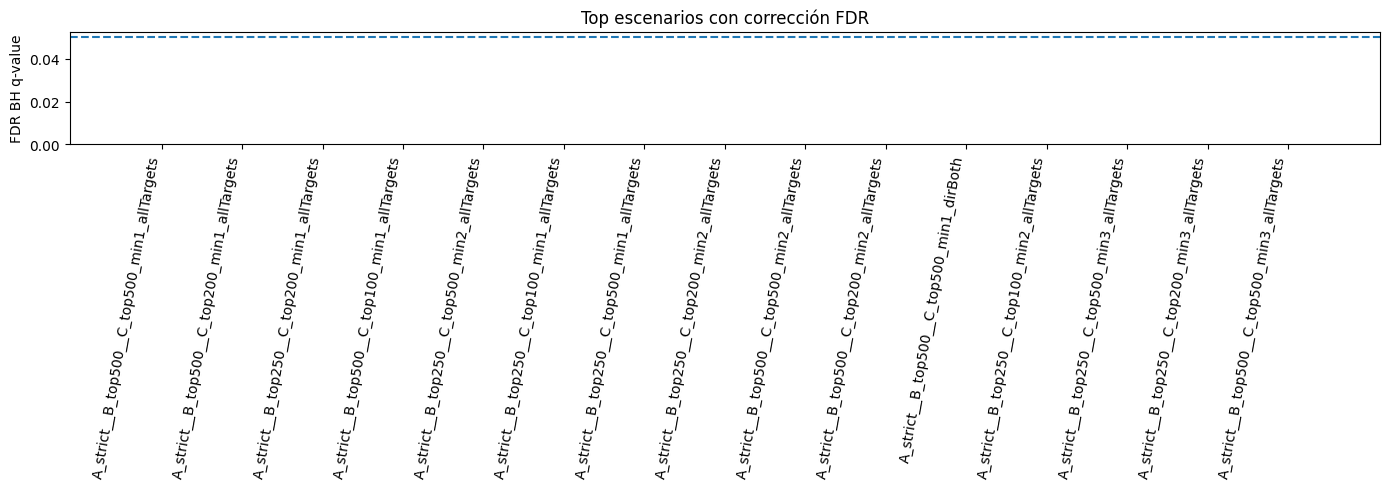

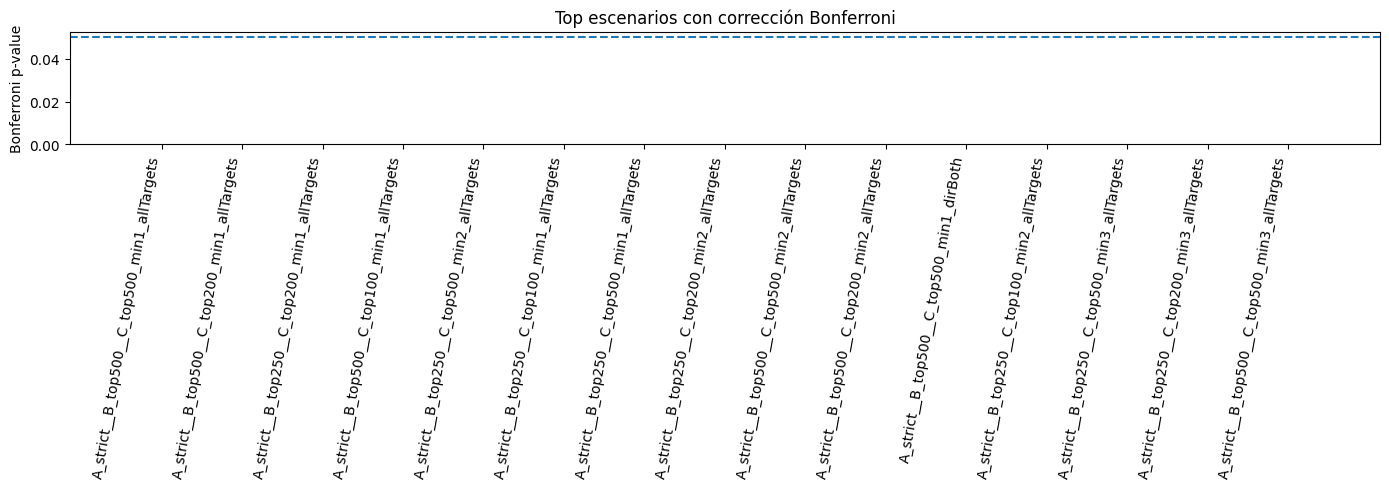

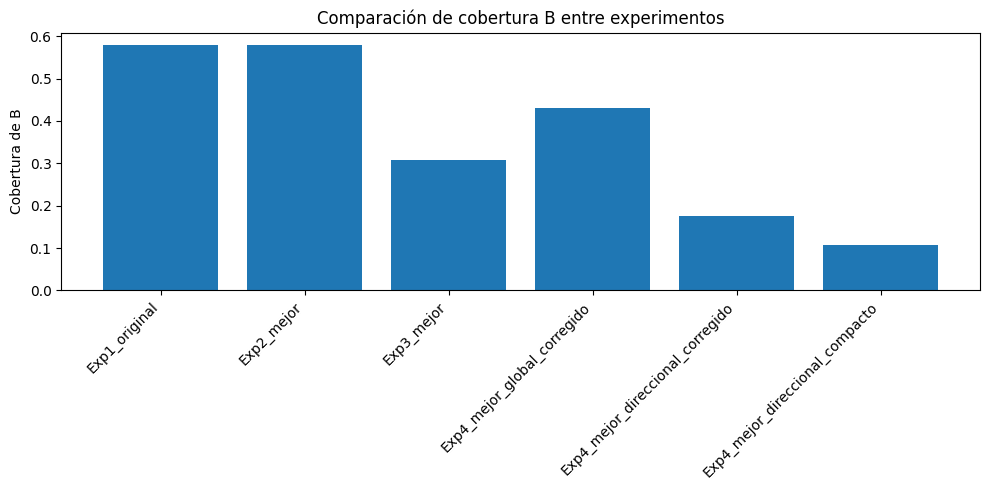

In [54]:
import matplotlib.pyplot as plt

top_corr = df_exp4.head(15).copy()

plt.figure(figsize=(14, 5))
plt.bar(top_corr["escenario"], top_corr["p_fdr_bh"])
plt.axhline(0.05, linestyle="--")
plt.xticks(rotation=80, ha="right")
plt.ylabel("FDR BH q-value")
plt.title("Top escenarios con corrección FDR")
plt.tight_layout()
plt.savefig(os.path.join(EXP4_DIR, "plot_top_escenarios_fdr_bh.png"), dpi=200)
plt.show()

plt.figure(figsize=(14, 5))
plt.bar(top_corr["escenario"], top_corr["p_bonferroni"])
plt.axhline(0.05, linestyle="--")
plt.xticks(rotation=80, ha="right")
plt.ylabel("Bonferroni p-value")
plt.title("Top escenarios con corrección Bonferroni")
plt.tight_layout()
plt.savefig(os.path.join(EXP4_DIR, "plot_top_escenarios_bonferroni.png"), dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(df_comparacion_exp4["experimento"], df_comparacion_exp4["cobertura_B"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cobertura de B")
plt.title("Comparación de cobertura B entre experimentos")
plt.tight_layout()
plt.savefig(os.path.join(EXP4_DIR, "plot_comparacion_cobertura_B_exp1_4.png"), dpi=200)
plt.show()

## 52. Resumen final del Experimento 4

In [55]:
n_bonf = int(df_exp4["significativo_bonferroni_005"].sum())
n_fdr = int(df_exp4["significativo_fdr_005"].sum())

if bool(mejor_global_corr["significativo_bonferroni_005"]):
    conclusion_global = "El mejor escenario global sigue siendo significativo incluso con Bonferroni."
elif bool(mejor_global_corr["significativo_fdr_005"]):
    conclusion_global = "El mejor escenario global es significativo con FDR, pero no con Bonferroni."
else:
    conclusion_global = "El mejor escenario global no es significativo tras corrección múltiple."

if mejor_direccional_corr is not None:
    if bool(mejor_direccional_corr["significativo_bonferroni_005"]):
        conclusion_direccional = "El mejor escenario direccional también es significativo con Bonferroni."
    elif bool(mejor_direccional_corr["significativo_fdr_005"]):
        conclusion_direccional = "El mejor escenario direccional es significativo con FDR, pero no con Bonferroni."
    else:
        conclusion_direccional = "El mejor escenario direccional no es significativo tras corrección múltiple."
else:
    conclusion_direccional = "No se encontró escenario direccional evaluable."

resumen_exp4 = f"""
RESUMEN EXPERIMENTO 4: CORRECCIÓN MÚLTIPLE Y VALIDACIÓN ROBUSTA
===============================================================

Objetivo:
Corregir el Experimento 3 por múltiples pruebas y separar la mejor señal
estadística global de la mejor señal biológicamente conservadora.

Escenarios evaluados:
{len(df_exp4)}

Escenarios significativos con Bonferroni p<0.05:
{n_bonf}

Escenarios significativos con FDR BH q<0.05:
{n_fdr}

Mejor escenario global corregido:
{mejor_global_nombre}

Métricas del mejor global:
- n_A: {int(mejor_global_corr['n_A'])}
- n_B: {int(mejor_global_corr['n_B'])}
- n_C: {int(mejor_global_corr['n_C'])}
- n_interseccion_ABC: {int(mejor_global_corr['n_interseccion_ABC'])}
- IoU: {float(mejor_global_corr['iou_ABC'])}
- Cobertura B: {float(mejor_global_corr['cobertura_B'])}
- Fisher raw p-value: {float(mejor_global_corr['fisher_AB_en_C_p_value'])}
- Bonferroni p-value: {float(mejor_global_corr['p_bonferroni'])}
- FDR BH q-value: {float(mejor_global_corr['p_fdr_bh'])}
- Odds ratio: {float(mejor_global_corr['fisher_AB_en_C_odds_ratio'])}

Conclusión global:
{conclusion_global}

Mejor escenario direccional:
{mejor_dir_nombre if mejor_direccional_corr is not None else 'No disponible'}

Conclusión direccional:
{conclusion_direccional}

Genes candidatos robustos totales:
{len(df_candidatos_robustos)}

Archivos principales:
- escenarios_exp3_con_correccion_multiple.csv
- selecciones_principales_exp4.csv
- interseccion_mejor_global_corregido.csv
- interseccion_mejor_direccional_corregido.csv
- frecuencia_genes_escenarios_significativos_fdr.csv
- frecuencia_genes_escenarios_significativos_bonferroni.csv
- genes_candidatos_robustos_exp4.csv
- comparacion_experimentos_1_2_3_4.csv

Interpretación:
El Experimento 4 corrige el riesgo de haber probado muchos escenarios en el
Experimento 3. Si el mejor escenario conserva significancia tras Bonferroni/FDR,
la señal de enriquecimiento es más defendible. El IoU puede seguir siendo bajo,
pero la métrica principal aquí es el enriquecimiento corregido y la estabilidad
de genes candidatos.
"""

print(resumen_exp4)

with open(os.path.join(EXP4_DIR, "resumen_experimento4_correccion_multiple.txt"), "w", encoding="utf-8") as f:
    f.write(resumen_exp4)

print("Resumen guardado en:", os.path.join(EXP4_DIR, "resumen_experimento4_correccion_multiple.txt"))


RESUMEN EXPERIMENTO 4: CORRECCIÓN MÚLTIPLE Y VALIDACIÓN ROBUSTA

Objetivo:
Corregir el Experimento 3 por múltiples pruebas y separar la mejor señal
estadística global de la mejor señal biológicamente conservadora.

Escenarios evaluados:
1460

Escenarios significativos con Bonferroni p<0.05:
75

Escenarios significativos con FDR BH q<0.05:
130

Mejor escenario global corregido:
A_strict__B_top500__C_top500_min1_allTargets

Métricas del mejor global:
- n_A: 2501
- n_B: 500
- n_C: 10184
- n_interseccion_ABC: 215
- IoU: 0.018931055736550146
- Cobertura B: 0.43
- Fisher raw p-value: 2.987628071903606e-32
- Bonferroni p-value: 4.361936984979265e-29
- FDR BH q-value: 4.361936984979265e-29
- Odds ratio: 4.8453539305179385

Conclusión global:
El mejor escenario global sigue siendo significativo incluso con Bonferroni.

Mejor escenario direccional:
A_strict__B_top500__C_top500_min1_dirBoth

Conclusión direccional:
El mejor escenario direccional también es significativo con Bonferroni.

Genes ca

# EXPERIMENTO 5: Enriquecimiento funcional de genes candidatos robustos

Esta etapa utiliza como entrada los genes candidatos robustos obtenidos en el Experimento 4.

No modifica la construcción de los conjuntos A, B o C y no realiza una nueva búsqueda de escenarios.

Su objetivo es evaluar si los genes priorizados por convergencia mRNA–miRNA se concentran
en procesos biológicos conocidos mediante análisis de enriquecimiento funcional.


## 53. Configuración del Experimento 5

Esta sección reutiliza variables generadas por el Experimento 4:

- `df_candidatos_robustos`
- `genes_candidatos_robustos`
- `U_mrna_union`

Si la sección se ejecuta de forma aislada, puede cargar la lista de candidatos desde los
archivos generados previamente.


In [56]:
# ============================================================
# CONFIGURACIÓN DEL EXPERIMENTO 5
# ============================================================

import os
import re
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

EXTRA_DIR = "outputs_enriquecimiento"
os.makedirs(EXTRA_DIR, exist_ok=True)

CONFIG_EXTRA = {
    # Archivo con genes candidatos finales.
    # Según tu carpeta, este parece ser el mejor candidato.
    "candidate_genes_path": "resultados_experimento4_correccion_multiple/genes_candidatos_robustos_exp4.csv",

    # Fondo operativo. Si no estás seguro, déjalo en None.
    # Para Enrichr no es obligatorio.
    "background_genes_path": None,



}

def normalizar_gen_extra(x):
    if pd.isna(x):
        return None
    x = str(x).strip().upper()
    if x == "" or x in {"NAN", "NONE", "NULL"}:
        return None
    x = re.split(r"\s*///\s*|\s*;\s*|\s*,\s*", x)[0].strip()
    x = re.sub(r"[^A-Z0-9\-_\.]", "", x)
    return x if x else None

print("Directorio extra:", EXTRA_DIR)
CONFIG_EXTRA


Directorio extra: outputs_enriquecimiento


{'candidate_genes_path': 'resultados_experimento4_correccion_multiple/genes_candidatos_robustos_exp4.csv',
 'background_genes_path': None}

# EXPERIMENTO 5: Enriquecimiento funcional de genes candidatos robustos

Este experimento toma los genes candidatos robustos del Experimento 4 y evalúa si están sobrerrepresentados en términos funcionales.

Bases recomendadas:

- GO Biological Process
- Reactome
- KEGG
- MSigDB Hallmark

La salida principal es una tabla compacta con términos, genes solapados y valores ajustados.


In [57]:
# ============================================================
# 54. Obtener genes candidatos robustos y universo de fondo
# ============================================================

def obtener_genes_candidatos_extra():
    if "genes_candidatos_robustos" in globals():
        genes = sorted({normalizar_gen_extra(g) for g in genes_candidatos_robustos})
        genes = [g for g in genes if g is not None]
        print("Genes candidatos desde variable genes_candidatos_robustos:", len(genes))
        return genes

    if "df_candidatos_robustos" in globals():
        df = df_candidatos_robustos.copy()
    else:
        path = CONFIG_EXTRA["candidate_genes_path"]
        if not os.path.exists(path):
            raise FileNotFoundError(
                "No encontré genes candidatos robustos. Ejecuta el Experimento 4 completo "
                f"o ajusta CONFIG_EXTRA['candidate_genes_path']. Ruta buscada: {path}"
            )
        df = pd.read_csv(path)

    posibles_cols = ["gene_symbol", "gene", "Gene", "symbol", "genes", "target_gene"]
    col = next((c for c in posibles_cols if c in df.columns), None)
    if col is None:
        raise ValueError(f"No pude detectar columna de genes. Columnas disponibles: {df.columns.tolist()}")

    genes = sorted({normalizar_gen_extra(g) for g in df[col].dropna().tolist()})
    genes = [g for g in genes if g is not None]
    print(f"Genes candidatos desde columna {col}:", len(genes))
    return genes


def obtener_background_extra():
    if "U_mrna_union" in globals():
        bg = sorted({normalizar_gen_extra(g) for g in U_mrna_union})
        bg = [g for g in bg if g is not None]
        print("Background desde U_mrna_union:", len(bg))
        return bg

    path = CONFIG_EXTRA.get("background_genes_path")
    if path and os.path.exists(path):
        df_bg = pd.read_csv(path)
        col = next((c for c in ["gene_symbol", "gene", "Gene", "symbol"] if c in df_bg.columns), df_bg.columns[0])
        bg = sorted({normalizar_gen_extra(g) for g in df_bg[col].dropna().tolist()})
        bg = [g for g in bg if g is not None]
        print("Background desde archivo:", len(bg))
        return bg

    print("No se encontró background operativo. Enrichr usará su fondo interno.")
    return None


candidate_genes_extra = obtener_genes_candidatos_extra()
background_genes_extra = obtener_background_extra()

pd.DataFrame({"gene_symbol": candidate_genes_extra}).to_csv(
    os.path.join(EXTRA_DIR, "genes_candidatos_para_enriquecimiento.csv"),
    index=False
)

print("Primeros genes candidatos:", candidate_genes_extra[:20])


Genes candidatos desde variable genes_candidatos_robustos: 220
Background desde U_mrna_union: 23047
Primeros genes candidatos: ['ABCA8', 'ADAMTS5', 'ADAR', 'ADD3', 'AMOTL2', 'ANKRD29', 'ANLN', 'ASPM', 'ATAD2', 'AURKA', 'BIRC5', 'BUB1B', 'CACHD1', 'CAV1', 'CAV2', 'CBX2', 'CBX3', 'CCNB1', 'CCNE2', 'CDC20']


In [58]:
# ============================================================
# 55. Enriquecimiento funcional con Enrichr/gseapy
# ============================================================
# En Colab normalmente hay internet. Si la instalación o consulta falla,
# revisa la conexión y vuelve a ejecutar esta celda.

import sys
import subprocess
import importlib.util

if importlib.util.find_spec("gseapy") is None:
    print("Instalando gseapy...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gseapy"])

import gseapy as gp

gene_sets_extra = [
    "GO_Biological_Process_2023",
    "Reactome_2022",
    "KEGG_2021_Human",
    "MSigDB_Hallmark_2020",
]

def ejecutar_enrichr_extra(gene_list, gene_sets, outdir, background=None):
    try:
        enr = gp.enrichr(
            gene_list=gene_list,
            gene_sets=gene_sets,
            organism="human",
            background=background,
            outdir=outdir,
            cutoff=1.0,
            no_plot=True,
        )
    except TypeError:
        print("Esta versión de gseapy no acepta background personalizado; se usará fondo interno de Enrichr.")
        enr = gp.enrichr(
            gene_list=gene_list,
            gene_sets=gene_sets,
            organism="human",
            outdir=outdir,
            cutoff=1.0,
            no_plot=True,
        )
    return enr

enrichr_dir = os.path.join(EXTRA_DIR, "enrichr")
os.makedirs(enrichr_dir, exist_ok=True)

enr_extra = ejecutar_enrichr_extra(
    candidate_genes_extra,
    gene_sets_extra,
    enrichr_dir,
    background=background_genes_extra
)

df_enrich_extra = enr_extra.results.copy()

rename_map = {
    "Gene_set": "fuente",
    "Gene Set": "fuente",
    "Term": "termino",
    "Adjusted P-value": "p_ajustado",
    "P-value": "p_value",
    "Overlap": "overlap",
    "Genes": "genes_solapados",
    "Combined Score": "combined_score",
    "Odds Ratio": "odds_ratio",
}
df_enrich_extra = df_enrich_extra.rename(columns={c: rename_map.get(c, c) for c in df_enrich_extra.columns})

for col in ["fuente", "termino", "p_value", "p_ajustado", "overlap", "genes_solapados"]:
    if col not in df_enrich_extra.columns:
        df_enrich_extra[col] = np.nan

df_enrich_extra = df_enrich_extra.sort_values(["p_ajustado", "p_value"], ascending=True).reset_index(drop=True)
df_enrich_extra["significativo_FDR_005"] = df_enrich_extra["p_ajustado"].astype(float) < 0.05

df_enrich_extra.to_csv(
    os.path.join(EXTRA_DIR, "functional_enrichment_candidates_full.csv"),
    index=False
)

df_enrich_sig_extra = df_enrich_extra[df_enrich_extra["significativo_FDR_005"]].copy()
df_enrich_sig_extra.to_csv(
    os.path.join(EXTRA_DIR, "functional_enrichment_candidates_significant.csv"),
    index=False
)

print("Términos evaluados:", len(df_enrich_extra))
print("Términos significativos FDR<0.05:", len(df_enrich_sig_extra))

df_enrich_extra.head(20)


Términos evaluados: 2483
Términos significativos FDR<0.05: 293


,fuente,termino,p_value,p_ajustado,Old P-value,Old adjusted P-value,odds_ratio,combined_score,genes_solapados,overlap,significativo_FDR_005
0,MSigDB_Hallmark_2020,E2F Targets,7.385620e-42,3.175816e-40,0,0,32.504659,3078.485067,TOP2A;PCNA;RNASEH2A;CDCA3;CDCA8;BUB1B;HMGB3;HM...,NaN,True
1,MSigDB_Hallmark_2020,G2-M Checkpoint,3.488947e-36,7.501236e-35,0,0,28.433528,2321.411736,TOP2A;HMGB3;TTK;KIF11;HMMR;SMC4;KIF15;LMNB1;AU...,NaN,True
2,Reactome_2022,"Cell Cycle, Mitotic R-HSA-69278",8.278862e-25,5.853155e-22,0,0,10.812613,599.569360,CDKN1C;TOP2A;FEN1;PCNA;CDCA5;BUB1B;CDCA8;NCAPG...,NaN,True
3,Reactome_2022,Cell Cycle R-HSA-1640170,4.640230e-24,1.640321e-21,0,0,9.246696,496.799835,CDKN1C;TOP2A;FEN1;PCNA;CDCA5;HJURP;BUB1B;CDCA8...,NaN,True
4,MSigDB_Hallmark_2020,Mitotic Spindle,3.611898e-16,5.177054e-15,0,0,13.503960,480.162052,TOP2A;KIF23;TTK;KIF11;SMC4;KIF15;LMNB1;AURKA;A...,NaN,True
5,GO_Biological_Process_2023,Mitotic Sister Chromatid Segregation (GO:0000070),1.400071e-17,2.184111e-14,0,0,22.511881,873.628103,SPAG5;CDCA5;CDCA8;NCAPG;KIF23;KIF11;SMC4;ZWINT...,NaN,True
6,GO_Biological_Process_2023,Microtubule Cytoskeleton Organization Involved...,6.464302e-15,5.042156e-12,0,0,32.518555,1062.461885,STIL;CDCA8;TTK;KIF11;CCNB1;ESPL1;KIF4A;NUF2;NU...,NaN,True
7,Reactome_2022,M Phase R-HSA-68886,3.032805e-14,7.147310e-12,0,0,8.667308,269.784739,CENPU;NUP210;UBE2C;CDCA5;BUB1B;CDCA8;NCAPG;KIF...,NaN,True
8,GO_Biological_Process_2023,Positive Regulation Of Cell Cycle Process (GO:...,3.622780e-13,1.883846e-10,0,0,16.464139,471.637729,STIL;FEN1;SPAG5;CDCA8;NCAPG;CDC7;KIF23;SMC4;AU...,NaN,True
9,Reactome_2022,Signal Transduction R-HSA-162582,1.339904e-12,2.075783e-10,0,0,3.297297,90.142908,CXCL9;FAM13A;BUB1B;IRS2;FGF1;NR3C1;CHRDL1;RND3...,NaN,True


In [59]:
!pip install jinja2


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
# ============================================================
# 56. Tabla compacta de enriquecimiento para el paper
# ============================================================

def acortar_genes_str(s, max_genes=8):
    if pd.isna(s):
        return ""
    genes = re.split(r"[;,]", str(s))
    genes = [g.strip() for g in genes if g.strip()]
    return "; ".join(genes[:max_genes])

df_enrich_paper = df_enrich_extra.copy()

if df_enrich_paper["significativo_FDR_005"].sum() > 0:
    df_enrich_paper = df_enrich_paper[df_enrich_paper["significativo_FDR_005"]].copy()

df_enrich_paper = df_enrich_paper.head(10).copy()
df_enrich_paper["genes_representativos"] = df_enrich_paper["genes_solapados"].map(lambda x: acortar_genes_str(x, max_genes=8))

cols_paper = ["fuente", "termino", "overlap", "p_ajustado", "genes_representativos"]
df_enrich_paper = df_enrich_paper[cols_paper].copy()

df_enrich_paper.to_csv(
    os.path.join(EXTRA_DIR, "tabla_enriquecimiento_para_paper.csv"),
    index=False
)

latex_enrich = df_enrich_paper.to_latex(
    index=False,
    escape=False,
    float_format=lambda x: f"{x:.2e}" if isinstance(x, float) else str(x)
)

with open(os.path.join(EXTRA_DIR, "tabla_enriquecimiento_latex.txt"), "w", encoding="utf-8") as f:
    f.write(latex_enrich)

print("Tabla compacta guardada en:", os.path.join(EXTRA_DIR, "tabla_enriquecimiento_para_paper.csv"))
df_enrich_paper


Tabla compacta guardada en: outputs_enriquecimiento\tabla_enriquecimiento_para_paper.csv


,fuente,termino,overlap,p_ajustado,genes_representativos
0,MSigDB_Hallmark_2020,E2F Targets,NaN,3.175816e-40,TOP2A; PCNA; RNASEH2A; CDCA3; CDCA8; BUB1B; HM...
1,MSigDB_Hallmark_2020,G2-M Checkpoint,NaN,7.501236e-35,TOP2A; HMGB3; TTK; KIF11; HMMR; SMC4; KIF15; L...
2,Reactome_2022,"Cell Cycle, Mitotic R-HSA-69278",NaN,5.853155e-22,CDKN1C; TOP2A; FEN1; PCNA; CDCA5; BUB1B; CDCA8...
3,Reactome_2022,Cell Cycle R-HSA-1640170,NaN,1.640321e-21,CDKN1C; TOP2A; FEN1; PCNA; CDCA5; HJURP; BUB1B...
4,MSigDB_Hallmark_2020,Mitotic Spindle,NaN,5.177054e-15,TOP2A; KIF23; TTK; KIF11; SMC4; KIF15; LMNB1; ...
5,GO_Biological_Process_2023,Mitotic Sister Chromatid Segregation (GO:0000070),NaN,2.184111e-14,SPAG5; CDCA5; CDCA8; NCAPG; KIF23; KIF11; SMC4...
6,GO_Biological_Process_2023,Microtubule Cytoskeleton Organization Involved...,NaN,5.042156e-12,STIL; CDCA8; TTK; KIF11; CCNB1; ESPL1; KIF4A; ...
7,Reactome_2022,M Phase R-HSA-68886,NaN,7.147310e-12,CENPU; NUP210; UBE2C; CDCA5; BUB1B; CDCA8; NCA...
8,GO_Biological_Process_2023,Positive Regulation Of Cell Cycle Process (GO:...,NaN,1.883846e-10,STIL; FEN1; SPAG5; CDCA8; NCAPG; CDC7; KIF23; ...
9,Reactome_2022,Signal Transduction R-HSA-162582,NaN,2.075783e-10,CXCL9; FAM13A; BUB1B; IRS2; FGF1; NR3C1; CHRDL...


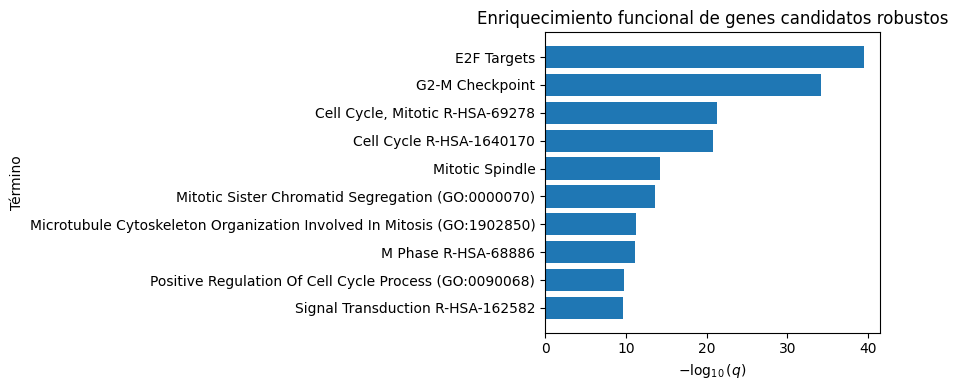

In [61]:
# ============================================================
# 57. Visualización opcional de enriquecimiento
# ============================================================

import matplotlib.pyplot as plt

df_plot_enrich = df_enrich_paper.copy()

if len(df_plot_enrich) > 0:
    df_plot_enrich["minus_log10_q"] = -np.log10(df_plot_enrich["p_ajustado"].astype(float).clip(lower=1e-300))
    df_plot_enrich = df_plot_enrich.sort_values("minus_log10_q", ascending=True)

    plt.figure(figsize=(9, max(4, 0.35 * len(df_plot_enrich))))
    plt.barh(df_plot_enrich["termino"], df_plot_enrich["minus_log10_q"])
    plt.xlabel(r"$-\log_{10}(q)$")
    plt.ylabel("Término")
    plt.title("Enriquecimiento funcional de genes candidatos robustos")
    plt.tight_layout()
    plt.savefig(os.path.join(EXTRA_DIR, "plot_enriquecimiento_funcional.png"), dpi=200)
    plt.show()
else:
    print("No hay términos para graficar.")
